<a href="https://colab.research.google.com/github/miosync-masa/Beyond_Arbitrariness/blob/main/Beyond_Arbitrariness_BetaBinomial_Diagnostics_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond Arbitrariness — Paper 1 statistical pipeline

**Colab Pro+ / H100 / Python + JAX + NumPyro**

This notebook upgrades the repository's descriptive latitude-gradient analyses into a modern inferential pipeline.

## Paper 1 center

- ASJP: discovery / primary estimate
- Lexibank: independent IPA replication
- Primary outcome: word-final vowel count per language
- Main predictor: continuous absolute latitude
- Controls: language family, position specificity, within-family vs between-family decomposition
- Outputs: posterior draws, diagnostics, PPC, sensitivity tables, PDF figures

RBS remains a secondary convergent analysis, not the paper's central theory.

In [1]:
!pip -q install "numpyro>=0.16,<0.20" "arviz>=0.20,<0.23" "pandas>=2.2,<3" "pyarrow>=17,<22" "matplotlib>=3.9,<4" "scipy>=1.13,<2" "netCDF4>=1.7"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 158.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.5 MB/s eta 0:00:00


In [2]:
import os, sys, json, hashlib, platform, subprocess
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
import arviz as az

jax.config.update("jax_enable_x64", True)
SEED = 20260711
print("JAX", jax.__version__, "NumPyro", numpyro.__version__)
print("Devices", jax.devices())

JAX 0.7.2 NumPyro 0.19.0
Devices [CudaDevice(id=0)]


In [3]:
ROOT = Path("/content/beyond_arbitrariness_paper1")
REPO = ROOT / "Beyond_Arbitrariness"
ASJP = ROOT / "asjp"
LEXIBANK = ROOT / "lexibank-analysed"
DERIVED = ROOT / "data" / "derived"
RESULTS = ROOT / "results" / "paper1"
FIGURES = ROOT / "figures" / "paper1"
MODELS = ROOT / "models" / "paper1"
for p in [DERIVED, RESULTS, FIGURES, MODELS]: p.mkdir(parents=True, exist_ok=True)

def clone_or_pull(url, path):
    if not path.exists():
        subprocess.run(["git","clone","--depth","1",url,str(path)], check=True)
    else:
        subprocess.run(["git","-C",str(path),"pull","--ff-only"], check=True)

clone_or_pull("https://github.com/miosync-masa/Beyond_Arbitrariness.git", REPO)
clone_or_pull("https://github.com/lexibank/asjp.git", ASJP)
clone_or_pull("https://github.com/lexibank/lexibank-analysed.git", LEXIBANK)

def git_sha(path):
    return subprocess.check_output(["git","-C",str(path),"rev-parse","HEAD"], text=True).strip()

meta = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "seed": SEED,
    "backend": jax.default_backend(),
    "device": str(jax.devices()[0]),
    "repo_sha": git_sha(REPO),
    "asjp_sha": git_sha(ASJP),
    "lexibank_sha": git_sha(LEXIBANK),
}
(RESULTS/"reproducibility_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
meta

{'created_utc': '2026-07-13T01:19:46.910643+00:00',
 'seed': 20260711,
 'backend': 'gpu',
 'device': 'cuda:0',
 'repo_sha': 'd3ef7a8246f2329114cfa0440c5b380caeca5fee',
 'asjp_sha': '012795349540ba0dabfdcf2be16f2e77622f62d6',
 'lexibank_sha': 'edf5f028de7eabdabe0998a4a831e5e7dca79117'}

## Shared phoneme classification

The definitions below follow the existing repository logic in:

- `scripts/06_word_final_gradient.py`
- `scripts/08_lexibank_word_final.py`

In [4]:
ASJP_VOWELS = set("ieE3auo")
ASJP_CONSONANTS = set("pbfvmw8tdszclnrSZCjT5ykgxNqXh7L4G!")
IPA_VOWELS = set("iyɨʉɯuɪʊeøɘɵɤoəɐɛœɜɞʌɔæaɶɑɒ")
IPA_STRIP = "ːˑ̃ʰʷʲˤˠ̥̤̰̹̜̩̯̊̆̈̽̚ʼ̻̝̞̟̠̀́̂̌̄̏̋̊ˈˌ¹²³⁴⁵˥˦˧˨˩↑↓+"

def asjp_segments(form):
    if not isinstance(form, str): return []
    return [c for c in form if c in ASJP_VOWELS or c in ASJP_CONSONANTS]

def clean_ipa(seg): return seg.strip(IPA_STRIP)
def is_ipa_vowel(seg):
    c = clean_ipa(seg)
    return bool(c) and c[0] in IPA_VOWELS

def ipa_segments(s):
    if not isinstance(s, str) or not s: return []
    return [x for x in s.replace("+"," ").split() if clean_ipa(x)]

def final_cluster(flags):
    n=0
    for is_v in reversed(flags):
        if is_v: break
        n += 1
    return n

In [5]:
def build_asjp():
    lang = pd.read_csv(ASJP/"cldf/languages.csv", low_memory=False)
    prm = pd.read_csv(ASJP/"cldf/parameters.csv", low_memory=False)
    frm = pd.read_csv(ASJP/"cldf/forms.csv", low_memory=False)
    if "Loan" in frm.columns:
        frm = frm[frm["Loan"].astype(str).str.lower() != "true"].copy()
    lg = lang[["ID","Family","Latitude","Longitude"]].rename(columns={"ID":"Language_ID"})
    pg = prm[["ID","Concepticon_Gloss"]].rename(columns={"ID":"Parameter_ID","Concepticon_Gloss":"Gloss"})
    d = frm[["Language_ID","Parameter_ID","Form"]].merge(lg,on="Language_ID",how="left").merge(pg,on="Parameter_ID",how="left")
    d["Latitude"] = pd.to_numeric(d["Latitude"], errors="coerce")
    d["Longitude"] = pd.to_numeric(d["Longitude"], errors="coerce")
    d = d.dropna(subset=["Latitude","Longitude","Form","Gloss"])
    d["Family"] = d["Family"].fillna("").replace("","ISOLATE_OR_UNKNOWN")
    d["abs_latitude"] = d["Latitude"].abs()
    seg = d["Form"].map(asjp_segments)
    d = d[seg.map(len) >= 1].copy(); seg = d["Form"].map(asjp_segments)
    d["initial_vowel"] = seg.map(lambda x: int(x[0] in ASJP_VOWELS))
    d["final_vowel"] = seg.map(lambda x: int(x[-1] in ASJP_VOWELS))
    d["final_cluster"] = seg.map(lambda x: final_cluster([z in ASJP_VOWELS for z in x]))
    return d

def build_lexibank():
    # The repository currently stores the large forms table as forms.csv.zip.
    # pandas can read a single-file ZIP archive directly.
    lang_path = LEXIBANK / "cldf" / "languages.csv"
    forms_csv = LEXIBANK / "cldf" / "forms.csv"
    forms_zip = LEXIBANK / "cldf" / "forms.csv.zip"

    if not lang_path.exists():
        raise FileNotFoundError(f"Lexibank languages file not found: {lang_path}")

    if forms_csv.exists():
        forms_path = forms_csv
    elif forms_zip.exists():
        forms_path = forms_zip
    else:
        raise FileNotFoundError(
            "Lexibank forms file not found. Expected either "
            f"{forms_csv} or {forms_zip}"
        )

    lang = pd.read_csv(lang_path, low_memory=False)
    frm = pd.read_csv(forms_path, compression="infer", low_memory=False)

    for c in ["Family", "Family_in_Data"]:
        if c not in lang.columns:
            lang[c] = ""

    lang["Family_resolved"] = (
        lang["Family"].fillna("").astype(str).str.strip()
    )
    m = lang["Family_resolved"].eq("")
    lang.loc[m, "Family_resolved"] = (
        lang.loc[m, "Family_in_Data"]
        .fillna("")
        .astype(str)
        .str.strip()
    )
    lang["Family_resolved"] = lang["Family_resolved"].replace(
        "", "ISOLATE_OR_UNKNOWN"
    )

    if "Loan" in frm.columns:
        frm = frm[
            ~frm["Loan"].astype(str).str.lower().isin(["true", "1"])
        ].copy()

    gloss_col = (
        "Concepticon_Gloss"
        if "Concepticon_Gloss" in frm.columns
        else "Parameter_ID"
    )

    required = ["Language_ID", gloss_col, "Segments"]
    missing = [c for c in required if c not in frm.columns]
    if missing:
        raise KeyError(f"Missing required Lexibank columns: {missing}")

    d = frm[required].rename(columns={gloss_col: "Gloss"})
    d = d.merge(
        lang[
            ["ID", "Family_resolved", "Latitude", "Longitude"]
        ].rename(
            columns={
                "ID": "Language_ID",
                "Family_resolved": "Family",
            }
        ),
        on="Language_ID",
        how="left",
    )

    d["Latitude"] = pd.to_numeric(d["Latitude"], errors="coerce")
    d["Longitude"] = pd.to_numeric(d["Longitude"], errors="coerce")
    d = d.dropna(
        subset=["Latitude", "Longitude", "Segments", "Gloss"]
    ).copy()
    d["abs_latitude"] = d["Latitude"].abs()

    seg = d["Segments"].map(ipa_segments)
    d = d[seg.map(len) >= 1].copy()
    seg = d["Segments"].map(ipa_segments)

    d["initial_vowel"] = seg.map(
        lambda x: int(is_ipa_vowel(x[0]))
    )
    d["final_vowel"] = seg.map(
        lambda x: int(is_ipa_vowel(x[-1]))
    )
    d["final_cluster"] = seg.map(
        lambda x: final_cluster(
            [is_ipa_vowel(z) for z in x]
        )
    )

    print(f"Loaded Lexibank forms from: {forms_path}")
    print(f"Retained forms: {len(d):,}")
    print(f"Languages: {d['Language_ID'].nunique():,}")

    return d


def aggregate_language(d, dataset):
    out = d.groupby(["Language_ID","Family","Latitude","Longitude","abs_latitude"], observed=True).agg(
        n_total=("final_vowel","size"),
        n_v_final=("final_vowel","sum"),
        n_v_initial=("initial_vowel","sum"),
        n_concepts=("Gloss","nunique"),
        mean_final_cluster=("final_cluster","mean"),
    ).reset_index()
    out["dataset"] = dataset
    return out

asjp_forms = build_asjp(); lex_forms = build_lexibank()
asjp_lang = aggregate_language(asjp_forms, "ASJP")
lex_lang = aggregate_language(lex_forms, "Lexibank")
asjp_lang.to_parquet(DERIVED/"paper1_asjp_language_summary.parquet", index=False)
lex_lang.to_parquet(DERIVED/"paper1_lexibank_language_summary.parquet", index=False)
print(asjp_lang.shape, lex_lang.shape)

Loaded Lexibank forms from: /content/beyond_arbitrariness_paper1/lexibank-analysed/cldf/forms.csv.zip
Retained forms: 1,740,092
Languages: 5,501
(11393, 11) (5501, 11)


## Descriptive reproduction

The four latitude bands are retained as a readable visualization, not as the final inferential model.

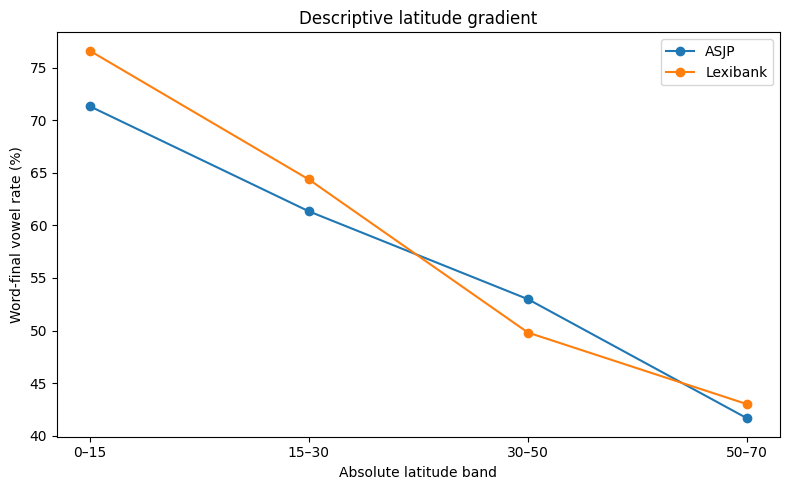

,lat_band,n_languages,n_families,n_words,n_v_final,n_v_initial,final_vowel_rate,initial_vowel_rate,dataset
0,0–15,6900,276,339789,242348,69216,0.713231,0.203703,ASJP
1,15–30,2838,75,136316,83608,16693,0.613340,0.122458,ASJP
2,30–50,1342,80,66192,35070,10340,0.529822,0.156212,ASJP
3,50–70,309,25,17852,7437,2892,0.416592,0.161999,ASJP
4,0–15,2875,199,741770,568209,160428,0.766018,0.216277,Lexibank
5,15–30,1625,58,527193,339318,55225,0.643631,0.104753,Lexibank
6,30–50,767,64,346918,172802,51118,0.498106,0.147349,Lexibank
7,50–70,228,18,121732,52350,19397,0.430043,0.159342,Lexibank


In [6]:
def band_summary(d, dataset):
    x=d.copy()
    x["lat_band"] = pd.cut(x["abs_latitude"], [0,15,30,50,70], labels=["0–15","15–30","30–50","50–70"], right=False, include_lowest=True)
    g=x.dropna(subset=["lat_band"]).groupby("lat_band", observed=True).agg(
        n_languages=("Language_ID","nunique"), n_families=("Family","nunique"),
        n_words=("n_total","sum"), n_v_final=("n_v_final","sum"), n_v_initial=("n_v_initial","sum")
    ).reset_index()
    g["final_vowel_rate"] = g["n_v_final"]/g["n_words"]
    g["initial_vowel_rate"] = g["n_v_initial"]/g["n_words"]
    g["dataset"] = dataset
    return g

bands=pd.concat([band_summary(asjp_lang,"ASJP"),band_summary(lex_lang,"Lexibank")], ignore_index=True)
bands.to_csv(RESULTS/"descriptive_latitude_bands.csv", index=False)
fig,ax=plt.subplots(figsize=(8,5))
for name,g in bands.groupby("dataset"):
    ax.plot(g["lat_band"].astype(str),100*g["final_vowel_rate"],marker="o",label=name)
ax.set(xlabel="Absolute latitude band",ylabel="Word-final vowel rate (%)",title="Descriptive latitude gradient")
ax.legend(); fig.tight_layout(); fig.savefig(FIGURES/"descriptive_latitude_gradient.pdf"); plt.show()
bands

## Primary hierarchical Bayesian model

Language-level binomial model:

\[
y_l \sim \mathrm{Binomial}(n_l,p_l)
\]

\[
\mathrm{logit}(p_l)=lpha+eta_{lat}z(|latitude_l|)+u_{family[l]}
\]

This is the lightweight primary estimate. The larger language × concept model belongs in the confirmatory extension after this model is stable.

In [7]:
def encode(d, min_concepts=20):
    x=d[d["n_concepts"]>=min_concepts].dropna(subset=["Family","abs_latitude"]).copy()
    x["family_idx"], levels = pd.factorize(x["Family"], sort=True)
    mu=x["abs_latitude"].mean(); sd=x["abs_latitude"].std(ddof=0)
    return {
        "frame":x.reset_index(drop=True), "y":x["n_v_final"].to_numpy(np.int64), "n":x["n_total"].to_numpy(np.int64),
        "lat_z":((x["abs_latitude"]-mu)/sd).to_numpy(float), "family_idx":x["family_idx"].to_numpy(np.int32),
        "n_family":len(levels), "lat_mean":float(mu), "lat_sd":float(sd)
    }

def model(y=None,n=None,lat_z=None,family_idx=None,n_family=None):
    alpha=numpyro.sample("alpha",dist.Normal(0,1.5))
    beta_lat=numpyro.sample("beta_lat",dist.Normal(0,1))
    sigma_family=numpyro.sample("sigma_family",dist.Exponential(1))
    z_family_raw=numpyro.sample("z_family_raw",dist.Normal(0,1).expand([n_family]))
    z_family=z_family_raw-jnp.mean(z_family_raw)
    eta=alpha+beta_lat*lat_z+sigma_family*z_family[family_idx]
    numpyro.deterministic("p",jax.nn.sigmoid(eta))
    with numpyro.plate("obs",len(n)):
        numpyro.sample("y",dist.Binomial(total_count=n.astype(jnp.int64),logits=eta),obs=y)

asjp_enc=encode(asjp_lang); lex_enc=encode(lex_lang)

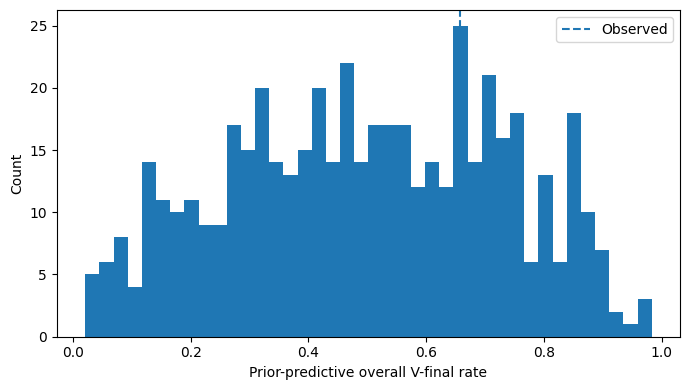

In [8]:
# Prior predictive check
prior=Predictive(model,num_samples=500)(jax.random.PRNGKey(SEED),y=None,n=jnp.asarray(asjp_enc["n"], dtype=jnp.int64),lat_z=jnp.asarray(asjp_enc["lat_z"]),family_idx=jnp.asarray(asjp_enc["family_idx"]),n_family=asjp_enc["n_family"])
prior_rate=np.asarray(prior["y"]).sum(axis=1)/asjp_enc["n"].sum()
fig,ax=plt.subplots(figsize=(7,4)); ax.hist(prior_rate,bins=40)
ax.axvline(asjp_enc["y"].sum()/asjp_enc["n"].sum(),linestyle="--",label="Observed")
ax.set(xlabel="Prior-predictive overall V-final rate",ylabel="Count"); ax.legend(); fig.tight_layout(); fig.savefig(FIGURES/"prior_predictive_primary.pdf"); plt.show()

In [9]:
FINAL_RUN=True
WARMUP,SAMPLES,CHAINS=(2000,2500,4) if FINAL_RUN else (300,300,1)

def fit_dataset(enc, seed):
    kernel=NUTS(model,target_accept_prob=0.99,max_tree_depth=12)
    m=MCMC(kernel,num_warmup=WARMUP,num_samples=SAMPLES,num_chains=CHAINS,chain_method="vectorized" if CHAINS>1 else "sequential")
    m.run(jax.random.PRNGKey(seed),y=jnp.asarray(enc["y"],dtype=jnp.int64),n=jnp.asarray(enc["n"],dtype=jnp.int64),lat_z=jnp.asarray(enc["lat_z"]),family_idx=jnp.asarray(enc["family_idx"]),n_family=enc["n_family"])
    return m

mcmc_asjp=fit_dataset(asjp_enc,SEED+1)
idata_asjp=az.from_numpyro(mcmc_asjp)
idata_asjp.to_netcdf(MODELS/"asjp_primary_posterior.nc")
az.summary(idata_asjp,var_names=["alpha","beta_lat","sigma_family"],hdi_prob=.95).to_csv(RESULTS/"asjp_primary_summary.csv")
mcmc_asjp.print_summary(exclude_deterministic=True)

sample: 100%|██████████| 4500/4500 [02:06<00:00, 35.58it/s]



                       mean       std    median      5.0%     95.0%     n_eff     r_hat
            alpha      1.09      0.02      1.09      1.06      1.13   1482.96      1.00
         beta_lat     -0.19      0.01     -0.19     -0.20     -0.18   5117.97      1.00
     sigma_family      1.71      0.07      1.71      1.59      1.82    302.60      1.01
  z_family_raw[0]     -1.09      0.18     -1.09     -1.38     -0.80    324.80      1.01
  z_family_raw[1]      0.25      0.09      0.25      0.11      0.40    165.65      1.01
  z_family_raw[2]     -0.69      0.13     -0.69     -0.91     -0.49    240.56      1.01
  z_family_raw[3]     -0.54      0.06     -0.54     -0.64     -0.43     63.17      1.04
  z_family_raw[4]      0.47      0.18      0.46      0.19      0.78    771.49      1.00
  z_family_raw[5]     -0.24      0.07     -0.24     -0.36     -0.12     87.52      1.03
  z_family_raw[6]     -0.72      0.07     -0.72     -0.84     -0.60     75.54      1.03
  z_family_raw[7]     -0.96    

In [10]:
# Diagnostics and posterior effect summary
s=az.summary(idata_asjp,hdi_prob=.95)
diag=pd.DataFrame([{
    "model":"ASJP primary", "max_rhat":float(s["r_hat"].max()) if "r_hat" in s else np.nan,
    "min_ess_bulk":float(s["ess_bulk"].min()) if "ess_bulk" in s else np.nan,
    "min_ess_tail":float(s["ess_tail"].min()) if "ess_tail" in s else np.nan,
    "divergences":int(idata_asjp.sample_stats["diverging"].sum())
}])
diag.to_csv(RESULTS/"model_diagnostics.csv",index=False)
beta=idata_asjp.posterior["beta_lat"].values.reshape(-1)
effect=pd.DataFrame([{
    "dataset":"ASJP","mean":beta.mean(),"median":np.median(beta),"ci_2.5":np.quantile(beta,.025),"ci_97.5":np.quantile(beta,.975),
    "p_beta_lt_0":np.mean(beta<0),"odds_ratio_per_1sd":np.exp(np.median(beta))
}])
effect.to_csv(RESULTS/"asjp_primary_effect.csv",index=False)
display(diag,effect)

,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP primary,1.04,66.0,95.0,0


,dataset,mean,median,ci_2.5,ci_97.5,p_beta_lt_0,odds_ratio_per_1sd
0,ASJP,-0.189911,-0.189926,-0.202721,-0.177021,1.0,0.827021


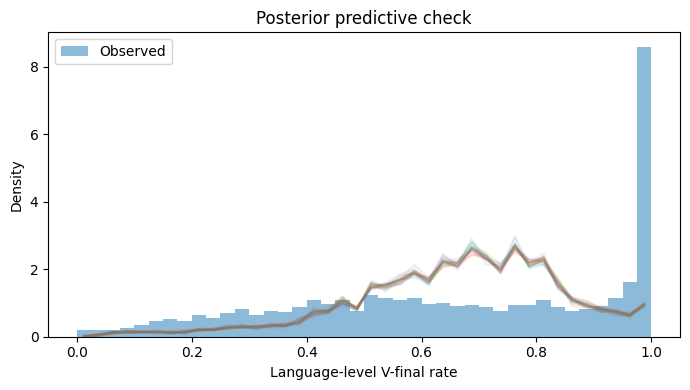

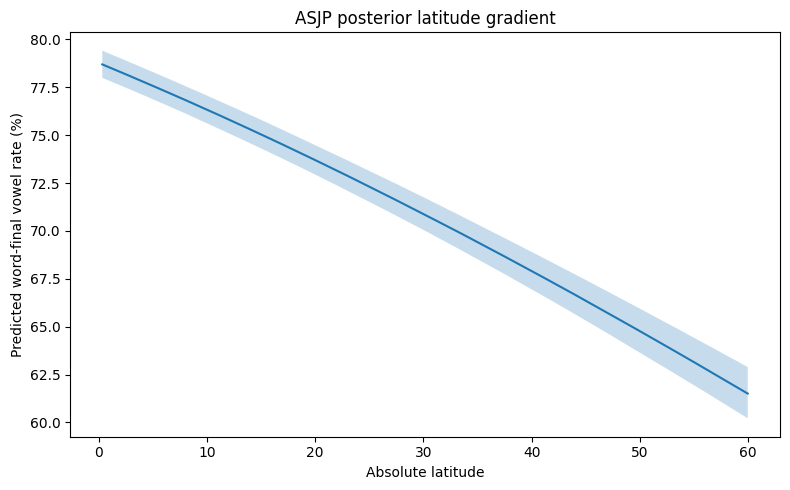

In [11]:
# Posterior predictive check and continuous curve
post=Predictive(model,posterior_samples=mcmc_asjp.get_samples(),return_sites=["y"])(jax.random.PRNGKey(SEED+2),y=None,n=jnp.asarray(asjp_enc["n"], dtype=jnp.int64),lat_z=jnp.asarray(asjp_enc["lat_z"]),family_idx=jnp.asarray(asjp_enc["family_idx"]),n_family=asjp_enc["n_family"])
yrep=np.asarray(post["y"]); obs=asjp_enc["y"]/asjp_enc["n"]; rep=yrep/asjp_enc["n"][None,:]
fig,ax=plt.subplots(figsize=(7,4)); ax.hist(obs,bins=40,density=True,alpha=.5,label="Observed")
for i in np.linspace(0,len(rep)-1,min(25,len(rep)),dtype=int):
    h,b=np.histogram(rep[i],bins=40,range=(0,1),density=True); ax.plot((b[:-1]+b[1:])/2,h,alpha=.12)
ax.set(xlabel="Language-level V-final rate",ylabel="Density",title="Posterior predictive check"); ax.legend(); fig.tight_layout(); fig.savefig(FIGURES/"posterior_predictive_primary.pdf"); plt.show()

draw=idata_asjp.posterior.stack(sample=("chain","draw")); a=draw["alpha"].values; b=draw["beta_lat"].values
lat=np.linspace(asjp_enc["frame"]["abs_latitude"].quantile(.01),asjp_enc["frame"]["abs_latitude"].quantile(.99),150)
z=(lat-asjp_enc["lat_mean"])/asjp_enc["lat_sd"]; p=expit(a[:,None]+b[:,None]*z[None,:])
curve=pd.DataFrame({"abs_latitude":lat,"median":np.median(p,axis=0),"lo":np.quantile(p,.025,axis=0),"hi":np.quantile(p,.975,axis=0)})
curve.to_csv(RESULTS/"asjp_posterior_curve.csv",index=False)
fig,ax=plt.subplots(figsize=(8,5)); ax.plot(lat,100*curve["median"]); ax.fill_between(lat,100*curve["lo"],100*curve["hi"],alpha=.25)
ax.set(xlabel="Absolute latitude",ylabel="Predicted word-final vowel rate (%)",title="ASJP posterior latitude gradient"); fig.tight_layout(); fig.savefig(FIGURES/"asjp_continuous_posterior_curve.pdf"); plt.show()

## Replication and robustness switches

After the ASJP primary model passes diagnostics, enable these analyses in order:

1. Lexibank independent replication with the same model and priors.
2. Initial-vs-final interaction model.
3. Within-family vs between-family latitude decomposition.
4. Minimum concept coverage 20 / 40 / 60.
5. Northern vs southern hemisphere.
6. Leave-one-family-out for influential families.
7. Leave-one-concept-out.
8. Shared-language and non-overlapping-language ASJP/Lexibank replication.
9. Macroarea and spatial-block controls.
10. Frozen climate augmentation: temperature, seasonality, humidity/aridity, elevation.

Absolute latitude remains a proxy, not a causal variable.

In [12]:
# Lexibank replication — same model, same priors
RUN_LEXIBANK=False
if RUN_LEXIBANK:
    mcmc_lex=fit_dataset(lex_enc,SEED+3)
    idata_lex=az.from_numpyro(mcmc_lex)
    idata_lex.to_netcdf(MODELS/"lexibank_replication_posterior.nc")
    az.summary(idata_lex,var_names=["alpha","beta_lat","sigma_family"],hdi_prob=.95).to_csv(RESULTS/"lexibank_replication_summary.csv")

In [13]:
# Lightweight descriptive sensitivity grid
def sensitivity(d):
    rows=[]
    for minimum in [20,40,60]:
        q=d[d["n_concepts"]>=minimum]
        for name,h in [("all",q),("north",q[q["Latitude"]>=0]),("south",q[q["Latitude"]<0])]:
            if len(h)<20: continue
            rows.append({"min_concepts":minimum,"hemisphere":name,"n_languages":len(h),"corr_abs_lat_vfinal":np.corrcoef(h["abs_latitude"],h["n_v_final"]/h["n_total"])[0,1]})
    return pd.DataFrame(rows)
sens=sensitivity(asjp_lang); sens.to_csv(RESULTS/"descriptive_sensitivity.csv",index=False); sens

,min_concepts,hemisphere,n_languages,corr_abs_lat_vfinal
0,20,all,10886,-0.273652
1,20,north,6748,-0.285578
2,20,south,4138,0.079198
3,40,all,3898,-0.312814
4,40,north,2588,-0.324306
5,40,south,1310,0.119377
6,60,all,2381,-0.301993
7,60,north,1451,-0.329213
8,60,south,930,0.200163


# Extended robustness sequence

This section executes the next six analyses in the agreed order:

1. Main-parameter convergence check
2. Hemisphere interaction
3. Within-family / between-family decomposition
4. Macroarea control
5. Initial-vs-final interaction
6. Lexibank replication

The models use the same weakly informative priors and non-centered hierarchical effects as the primary model.

## Revision notes for the production run

- Family effects are explicitly sum-to-zero centered.
- Language effects in the position model are sum-to-zero centered.
- Macroarea is modeled as a constrained fixed categorical effect rather than a random-effect variance.
- Production defaults are 4 chains, 2,000 warmup draws, 2,500 posterior draws, and target acceptance 0.99.
- The scientific interpretation remains observational: inheritance, contact, migration corridors, and ecological adaptation are competing or interacting explanations rather than assumptions baked into the likelihood.


## 1. Main-parameter R-hat / ESS check

In [14]:
MAIN_VARS = ["alpha", "beta_lat", "sigma_family"]

main_summary = az.summary(
    idata_asjp,
    var_names=MAIN_VARS,
    hdi_prob=0.95,
)

display(
    main_summary[
        ["mean", "sd", "hdi_2.5%", "hdi_97.5%", "ess_bulk", "ess_tail", "r_hat"]
    ]
)

main_diagnostics = pd.DataFrame([{
    "model": "ASJP primary — main parameters only",
    "max_rhat": float(main_summary["r_hat"].max()),
    "min_ess_bulk": float(main_summary["ess_bulk"].min()),
    "min_ess_tail": float(main_summary["ess_tail"].min()),
    "divergences": int(idata_asjp.sample_stats["diverging"].sum()),
}])

main_diagnostics.to_csv(
    RESULTS / "asjp_primary_main_parameter_diagnostics.csv",
    index=False,
)
main_diagnostics

,mean,sd,hdi_2.5%,hdi_97.5%,ess_bulk,ess_tail,r_hat
alpha,1.094,0.020,1.053,1.132,1487.0,3501.0,1.00
beta_lat,-0.190,0.007,-0.202,-0.177,5127.0,6520.0,1.00
sigma_family,1.708,0.073,1.563,1.852,308.0,623.0,1.01


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP primary — main parameters only,1.01,308.0,623.0,0


**Gate**

Proceed as an exploratory robustness run even if the primary fit is not yet perfect, but do not freeze manuscript estimates until:

- max R-hat < 1.01
- major-parameter bulk and tail ESS are adequate
- divergences = 0

## Shared fitting and summary helpers

In [15]:
# Robustness models use their own switches. Start with pilot settings,
# then switch ROBUSTNESS_FINAL_RUN=True for final estimates.
ROBUSTNESS_FINAL_RUN = True

if ROBUSTNESS_FINAL_RUN:
    ROBUST_WARMUP, ROBUST_SAMPLES, ROBUST_CHAINS = 2000, 2500, 4
else:
    ROBUST_WARMUP, ROBUST_SAMPLES, ROBUST_CHAINS = 400, 500, 2

def fit_numpyro_model(model_fn, data, seed, target_accept=0.99):
    kernel = NUTS(
        model_fn,
        target_accept_prob=target_accept,
        max_tree_depth=12,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=ROBUST_WARMUP,
        num_samples=ROBUST_SAMPLES,
        num_chains=ROBUST_CHAINS,
        chain_method="vectorized" if ROBUST_CHAINS > 1 else "sequential",
        progress_bar=True,
    )
    jax_data = {}
    for key, value in data.items():
        if key.startswith("n_") and np.isscalar(value):
            jax_data[key] = int(value)
        elif isinstance(value, np.ndarray):
            if key in {"y", "n"}:
                jax_data[key] = jnp.asarray(value, dtype=jnp.int64)
            elif key.endswith("_idx"):
                jax_data[key] = jnp.asarray(value, dtype=jnp.int32)
            else:
                jax_data[key] = jnp.asarray(value)
        else:
            jax_data[key] = value
    mcmc.run(jax.random.PRNGKey(seed), **jax_data)
    return mcmc

def compact_summary(idata, var_names, model_name, output_stem):
    summary = az.summary(
        idata,
        var_names=var_names,
        hdi_prob=0.95,
    )
    summary.to_csv(RESULTS / f"{output_stem}_summary.csv")
    diagnostics = pd.DataFrame([{
        "model": model_name,
        "max_rhat": float(summary["r_hat"].max()),
        "min_ess_bulk": float(summary["ess_bulk"].min()),
        "min_ess_tail": float(summary["ess_tail"].min()),
        "divergences": int(idata.sample_stats["diverging"].sum()),
    }])
    diagnostics.to_csv(
        RESULTS / f"{output_stem}_diagnostics.csv",
        index=False,
    )
    display(summary, diagnostics)
    return summary, diagnostics

def posterior_effect_row(idata, name, model_name):
    values = idata.posterior[name].values.reshape(-1)
    return {
        "model": model_name,
        "parameter": name,
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "ci_2.5": float(np.quantile(values, 0.025)),
        "ci_97.5": float(np.quantile(values, 0.975)),
        "p_lt_0": float(np.mean(values < 0)),
        "p_gt_0": float(np.mean(values > 0)),
    }

## 2. Hemisphere interaction model

In [16]:
def encode_hemisphere(d, min_concepts=20):
    x = d[
        d["n_concepts"] >= min_concepts
    ].dropna(
        subset=["Family", "Latitude", "abs_latitude"]
    ).copy()

    x["family_idx"], family_levels = pd.factorize(
        x["Family"], sort=True
    )
    x["south"] = (x["Latitude"] < 0).astype(float)

    lat_mean = x["abs_latitude"].mean()
    lat_sd = x["abs_latitude"].std(ddof=0)
    x["abs_lat_z"] = (
        x["abs_latitude"] - lat_mean
    ) / lat_sd

    return {
        "frame": x.reset_index(drop=True),
        "y": x["n_v_final"].to_numpy(np.int64),
        "n": x["n_total"].to_numpy(np.int64),
        "abs_lat_z": x["abs_lat_z"].to_numpy(float),
        "south": x["south"].to_numpy(float),
        "family_idx": x["family_idx"].to_numpy(np.int32),
        "n_family": len(family_levels),
        "lat_mean": float(lat_mean),
        "lat_sd": float(lat_sd),
    }

def hemisphere_model(
    y=None,
    n=None,
    abs_lat_z=None,
    south=None,
    family_idx=None,
    n_family=None,
):
    alpha = numpyro.sample("alpha", dist.Normal(0, 1.5))
    beta_lat_north = numpyro.sample(
        "beta_lat_north", dist.Normal(0, 1)
    )
    beta_south_level = numpyro.sample(
        "beta_south_level", dist.Normal(0, 1)
    )
    beta_lat_south_delta = numpyro.sample(
        "beta_lat_south_delta", dist.Normal(0, 1)
    )

    sigma_family = numpyro.sample(
        "sigma_family", dist.Exponential(1)
    )
    z_family_raw = numpyro.sample(
        "z_family_raw",
        dist.Normal(0, 1).expand([n_family]),
    )
    z_family = z_family_raw - jnp.mean(z_family_raw)
    family_effect = sigma_family * z_family

    eta = (
        alpha
        + beta_lat_north * abs_lat_z
        + beta_south_level * south
        + beta_lat_south_delta * abs_lat_z * south
        + family_effect[family_idx]
    )

    numpyro.deterministic(
        "beta_lat_south",
        beta_lat_north + beta_lat_south_delta,
    )

    with numpyro.plate("obs", len(n)):
        numpyro.sample(
            "y",
            dist.Binomial(
                total_count=n.astype(jnp.int64),
                logits=eta,
            ),
            obs=y,
        )

RUN_HEMISPHERE = True
hemi_enc = encode_hemisphere(asjp_lang)

if RUN_HEMISPHERE:
    hemi_data = {
        k: v for k, v in hemi_enc.items()
        if k not in {"frame", "lat_mean", "lat_sd"}
    }
    mcmc_hemi = fit_numpyro_model(
        hemisphere_model,
        hemi_data,
        SEED + 101,
    )
    idata_hemi = az.from_numpyro(mcmc_hemi)
    idata_hemi.to_netcdf(
        MODELS / "asjp_hemisphere_interaction.nc"
    )

    hemi_summary, hemi_diag = compact_summary(
        idata_hemi,
        [
            "beta_lat_north",
            "beta_lat_south",
            "beta_lat_south_delta",
            "beta_south_level",
            "sigma_family",
        ],
        "ASJP hemisphere interaction",
        "asjp_hemisphere_interaction",
    )

    hemi_effects = pd.DataFrame([
        posterior_effect_row(
            idata_hemi,
            "beta_lat_north",
            "North slope",
        ),
        posterior_effect_row(
            idata_hemi,
            "beta_lat_south",
            "South slope",
        ),
        posterior_effect_row(
            idata_hemi,
            "beta_lat_south_delta",
            "South-minus-north slope difference",
        ),
    ])
    hemi_effects.to_csv(
        RESULTS / "asjp_hemisphere_effects.csv",
        index=False,
    )
    display(hemi_effects)

sample: 100%|██████████| 4500/4500 [03:17<00:00, 22.74it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_lat_north,-0.258,0.007,-0.273,-0.244,0.000,0.000,5452.0,6761.0,1.00
beta_lat_south,0.578,0.018,0.542,0.613,0.000,0.000,5328.0,6321.0,1.00
beta_lat_south_delta,0.836,0.019,0.798,0.874,0.000,0.000,4660.0,5684.0,1.00
beta_south_level,1.765,0.017,1.732,1.800,0.000,0.000,4944.0,6345.0,1.00
sigma_family,1.806,0.077,1.654,1.952,0.005,0.003,252.0,407.0,1.02


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP hemisphere interaction,1.02,252.0,407.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,North slope,beta_lat_north,-0.258121,-0.258150,-0.272774,-0.243345,1.0,0.0
1,South slope,beta_lat_south,0.577559,0.577443,0.541801,0.612966,0.0,1.0
2,South-minus-north slope difference,beta_lat_south_delta,0.835680,0.835602,0.797239,0.873605,0.0,1.0


Interpretation:

- `beta_lat_north`: absolute-latitude slope in the Northern Hemisphere
- `beta_lat_south`: absolute-latitude slope in the Southern Hemisphere
- `beta_lat_south_delta`: South minus North

A positive South-minus-North difference means the global negative slope is not symmetric across hemispheres.

## 3. Within-family / between-family latitude decomposition

In [17]:
def encode_within_between(d, min_concepts=20):
    x = d[
        d["n_concepts"] >= min_concepts
    ].dropna(
        subset=["Family", "abs_latitude"]
    ).copy()

    x["family_mean_abs_lat"] = (
        x.groupby("Family")["abs_latitude"]
        .transform("mean")
    )
    x["within_family_abs_lat"] = (
        x["abs_latitude"] - x["family_mean_abs_lat"]
    )

    between_mean = x["family_mean_abs_lat"].mean()
    between_sd = x["family_mean_abs_lat"].std(ddof=0)
    within_sd = x["within_family_abs_lat"].std(ddof=0)

    x["between_lat_z"] = (
        x["family_mean_abs_lat"] - between_mean
    ) / between_sd
    x["within_lat_z"] = (
        x["within_family_abs_lat"] / within_sd
    )

    x["family_idx"], family_levels = pd.factorize(
        x["Family"], sort=True
    )

    return {
        "frame": x.reset_index(drop=True),
        "y": x["n_v_final"].to_numpy(np.int64),
        "n": x["n_total"].to_numpy(np.int64),
        "between_lat_z": x["between_lat_z"].to_numpy(float),
        "within_lat_z": x["within_lat_z"].to_numpy(float),
        "family_idx": x["family_idx"].to_numpy(np.int32),
        "n_family": len(family_levels),
    }

def within_between_model(
    y=None,
    n=None,
    between_lat_z=None,
    within_lat_z=None,
    family_idx=None,
    n_family=None,
):
    alpha = numpyro.sample("alpha", dist.Normal(0, 1.5))
    beta_between = numpyro.sample(
        "beta_between", dist.Normal(0, 1)
    )
    beta_within = numpyro.sample(
        "beta_within", dist.Normal(0, 1)
    )

    sigma_family = numpyro.sample(
        "sigma_family", dist.Exponential(1)
    )
    z_family_raw = numpyro.sample(
        "z_family_raw",
        dist.Normal(0, 1).expand([n_family]),
    )
    z_family = z_family_raw - jnp.mean(z_family_raw)
    family_effect = sigma_family * z_family

    eta = (
        alpha
        + beta_between * between_lat_z
        + beta_within * within_lat_z
        + family_effect[family_idx]
    )

    with numpyro.plate("obs", len(n)):
        numpyro.sample(
            "y",
            dist.Binomial(
                total_count=n.astype(jnp.int64),
                logits=eta,
            ),
            obs=y,
        )

RUN_WITHIN_BETWEEN = True
wb_enc = encode_within_between(asjp_lang)

if RUN_WITHIN_BETWEEN:
    wb_data = {
        k: v for k, v in wb_enc.items()
        if k != "frame"
    }
    mcmc_wb = fit_numpyro_model(
        within_between_model,
        wb_data,
        SEED + 102,
    )
    idata_wb = az.from_numpyro(mcmc_wb)
    idata_wb.to_netcdf(
        MODELS / "asjp_within_between_family.nc"
    )

    wb_summary, wb_diag = compact_summary(
        idata_wb,
        ["beta_between", "beta_within", "sigma_family"],
        "ASJP within/between family",
        "asjp_within_between_family",
    )

    wb_effects = pd.DataFrame([
        posterior_effect_row(
            idata_wb,
            "beta_between",
            "Between-family latitude",
        ),
        posterior_effect_row(
            idata_wb,
            "beta_within",
            "Within-family latitude",
        ),
    ])
    wb_effects.to_csv(
        RESULTS / "asjp_within_between_effects.csv",
        index=False,
    )
    display(wb_effects)

sample: 100%|██████████| 4500/4500 [03:50<00:00, 19.56it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_between,-0.513,0.071,-0.647,-0.376,0.005,0.003,218.0,524.0,1.01
beta_within,-0.083,0.003,-0.089,-0.078,0.000,0.000,26712.0,6273.0,1.00
sigma_family,1.654,0.066,1.519,1.780,0.003,0.001,668.0,1490.0,1.01


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP within/between family,1.01,218.0,524.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,Between-family latitude,beta_between,-0.512665,-0.511531,-0.648457,-0.376884,1.0,0.0
1,Within-family latitude,beta_within,-0.083375,-0.083359,-0.089067,-0.077729,1.0,0.0


Interpretation:

- `beta_between`: differences among families occupying different latitude ranges
- `beta_within`: differences among languages inside the same family

A negative `beta_within` is evidence against the entire pattern being only a family-composition artifact. It is still observational and not a causal estimate.

## 4. Macroarea control

In [18]:
# Macroarea source policy:
# 1. Prefer a source column already present in ASJP languages.csv.
# 2. Otherwise allow a user-supplied CSV with Language_ID, Macroarea.
# 3. Never silently rename a coordinate grid as a linguistic macroarea.

ASJP_LANG_PATH = ASJP / "cldf" / "languages.csv"
MACROAREA_OVERRIDE = (
    ROOT / "data" / "language_macroarea.csv"
)

def discover_macroarea_map():
    lang = pd.read_csv(ASJP_LANG_PATH, low_memory=False)
    candidates = [
        "Macroarea",
        "Macroarea_Name",
        "Glottolog_Macroarea",
        "macroarea",
    ]

    source_col = next(
        (c for c in candidates if c in lang.columns),
        None,
    )

    if source_col is not None:
        out = lang[["ID", source_col]].rename(
            columns={
                "ID": "Language_ID",
                source_col: "Macroarea",
            }
        )
        out["Macroarea"] = (
            out["Macroarea"]
            .fillna("")
            .astype(str)
            .str.strip()
        )
        out = out[out["Macroarea"] != ""].copy()
        print(
            f"Using ASJP source macroarea column: {source_col}"
        )
        return out

    if MACROAREA_OVERRIDE.exists():
        out = pd.read_csv(MACROAREA_OVERRIDE)
        required = {"Language_ID", "Macroarea"}
        if not required.issubset(out.columns):
            raise KeyError(
                f"{MACROAREA_OVERRIDE} must contain "
                "Language_ID and Macroarea."
            )
        print(
            f"Using user-supplied macroarea file: "
            f"{MACROAREA_OVERRIDE}"
        )
        return out[["Language_ID", "Macroarea"]].copy()

    print(
        "No linguistic macroarea source found. "
        "Macroarea model will be skipped rather than "
        "constructing an undocumented proxy."
    )
    return None

def encode_macroarea(d, macro_map, min_concepts=20):
    x = d[
        d["n_concepts"] >= min_concepts
    ].merge(
        macro_map,
        on="Language_ID",
        how="inner",
    ).dropna(
        subset=["Family", "Macroarea", "abs_latitude"]
    ).copy()

    x["family_idx"], family_levels = pd.factorize(
        x["Family"], sort=True
    )
    x["macroarea_idx"], macro_levels = pd.factorize(
        x["Macroarea"], sort=True
    )

    lat_mean = x["abs_latitude"].mean()
    lat_sd = x["abs_latitude"].std(ddof=0)
    x["lat_z"] = (
        x["abs_latitude"] - lat_mean
    ) / lat_sd

    print("Macroareas:", dict(enumerate(macro_levels)))

    return {
        "frame": x.reset_index(drop=True),
        "y": x["n_v_final"].to_numpy(np.int64),
        "n": x["n_total"].to_numpy(np.int64),
        "lat_z": x["lat_z"].to_numpy(float),
        "family_idx": x["family_idx"].to_numpy(np.int32),
        "macroarea_idx": x["macroarea_idx"].to_numpy(np.int32),
        "n_family": len(family_levels),
        "n_macroarea": len(macro_levels),
    }

def macroarea_model(
    y=None,
    n=None,
    lat_z=None,
    family_idx=None,
    macroarea_idx=None,
    n_family=None,
    n_macroarea=None,
):
    alpha = numpyro.sample("alpha", dist.Normal(0, 1.5))
    beta_lat = numpyro.sample("beta_lat", dist.Normal(0, 1))

    sigma_family = numpyro.sample(
        "sigma_family", dist.Exponential(1)
    )

    z_family_raw = numpyro.sample(
        "z_family_raw",
        dist.Normal(0, 1).expand([n_family]),
    )
    z_family = z_family_raw - jnp.mean(z_family_raw)
    family_effect = sigma_family * z_family

    # Six observed macroareas are treated as constrained categorical effects,
    # not as a sample from a larger random-effects population.
    macro_raw = numpyro.sample(
        "macro_raw",
        dist.Normal(0, 0.75).expand([n_macroarea]),
    )
    macro_effect = macro_raw - jnp.mean(macro_raw)

    eta = (
        alpha
        + beta_lat * lat_z
        + family_effect[family_idx]
        + macro_effect[macroarea_idx]
    )

    with numpyro.plate("obs", len(n)):
        numpyro.sample(
            "y",
            dist.Binomial(
                total_count=n.astype(jnp.int64),
                logits=eta,
            ),
            obs=y,
        )

RUN_MACROAREA = True
macro_map = discover_macroarea_map()

if RUN_MACROAREA and macro_map is not None:
    macro_enc = encode_macroarea(asjp_lang, macro_map)
    macro_data = {
        k: v for k, v in macro_enc.items()
        if k != "frame"
    }
    mcmc_macro = fit_numpyro_model(
        macroarea_model,
        macro_data,
        SEED + 103,
    )
    idata_macro = az.from_numpyro(mcmc_macro)
    idata_macro.to_netcdf(
        MODELS / "asjp_macroarea_control.nc"
    )

    macro_summary, macro_diag = compact_summary(
        idata_macro,
        ["beta_lat", "sigma_family", "macro_raw"],
        "ASJP macroarea control",
        "asjp_macroarea_control",
    )

    macro_effect = pd.DataFrame([
        posterior_effect_row(
            idata_macro,
            "beta_lat",
            "Latitude after family + macroarea",
        )
    ])
    macro_effect.to_csv(
        RESULTS / "asjp_macroarea_effect.csv",
        index=False,
    )
    display(macro_effect)

Using ASJP source macroarea column: Macroarea
Macroareas: {0: 'Africa', 1: 'Australia', 2: 'Eurasia', 3: 'North America', 4: 'Papunesia', 5: 'South America'}


sample: 100%|██████████| 4500/4500 [08:10<00:00,  9.18it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_lat,-0.167,0.007,-0.182,-0.153,0.000,0.000,6319.0,7345.0,1.00
sigma_family,1.700,0.071,1.561,1.840,0.004,0.002,261.0,672.0,1.01
macro_raw[0],0.590,0.307,0.008,1.191,0.008,0.004,1627.0,2720.0,1.00
macro_raw[1],-0.785,0.344,-1.480,-0.117,0.010,0.005,1238.0,2120.0,1.01
macro_raw[2],0.069,0.306,-0.518,0.661,0.008,0.004,1625.0,2716.0,1.00
macro_raw[3],-0.296,0.308,-0.886,0.302,0.008,0.004,1658.0,2843.0,1.00
macro_raw[4],-0.183,0.308,-0.769,0.413,0.008,0.004,1600.0,2711.0,1.00
macro_raw[5],0.618,0.312,0.018,1.240,0.008,0.004,1603.0,2557.0,1.00


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP macroarea control,1.01,261.0,672.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,Latitude after family + macroarea,beta_lat,-0.167391,-0.167414,-0.181847,-0.152815,1.0,0.0


If the ASJP table does not contain a macroarea field, place a documented mapping at:

`/content/beyond_arbitrariness_paper1/data/language_macroarea.csv`

Required columns:

- `Language_ID`
- `Macroarea`

The notebook intentionally skips the model rather than inventing a macroarea from arbitrary longitude bins.

## 5. Initial-vs-final interaction

In [19]:
def encode_position_interaction(d, min_concepts=20):
    base = d[
        d["n_concepts"] >= min_concepts
    ].dropna(
        subset=["Family", "abs_latitude"]
    ).copy()

    initial = base[
        [
            "Language_ID",
            "Family",
            "abs_latitude",
            "n_total",
            "n_v_initial",
        ]
    ].rename(columns={"n_v_initial": "y"})
    initial["position_final"] = 0.0

    final = base[
        [
            "Language_ID",
            "Family",
            "abs_latitude",
            "n_total",
            "n_v_final",
        ]
    ].rename(columns={"n_v_final": "y"})
    final["position_final"] = 1.0

    x = pd.concat([initial, final], ignore_index=True)

    x["family_idx"], family_levels = pd.factorize(
        x["Family"], sort=True
    )
    x["language_idx"], language_levels = pd.factorize(
        x["Language_ID"], sort=True
    )

    lat_mean = x["abs_latitude"].mean()
    lat_sd = x["abs_latitude"].std(ddof=0)
    x["lat_z"] = (
        x["abs_latitude"] - lat_mean
    ) / lat_sd

    return {
        "frame": x,
        "y": x["y"].to_numpy(np.int64),
        "n": x["n_total"].to_numpy(np.int64),
        "lat_z": x["lat_z"].to_numpy(float),
        "position_final": x["position_final"].to_numpy(float),
        "family_idx": x["family_idx"].to_numpy(np.int32),
        "language_idx": x["language_idx"].to_numpy(np.int32),
        "n_family": len(family_levels),
        "n_language": len(language_levels),
    }

def position_interaction_model(
    y=None,
    n=None,
    lat_z=None,
    position_final=None,
    family_idx=None,
    language_idx=None,
    n_family=None,
    n_language=None,
):
    alpha = numpyro.sample("alpha", dist.Normal(0, 1.5))
    beta_lat_initial = numpyro.sample(
        "beta_lat_initial", dist.Normal(0, 1)
    )
    beta_final_level = numpyro.sample(
        "beta_final_level", dist.Normal(0, 1)
    )
    beta_lat_final_delta = numpyro.sample(
        "beta_lat_final_delta", dist.Normal(0, 1)
    )

    sigma_family = numpyro.sample(
        "sigma_family", dist.Exponential(1)
    )
    sigma_language = numpyro.sample(
        "sigma_language", dist.Exponential(1)
    )

    z_family_raw = numpyro.sample(
        "z_family_raw",
        dist.Normal(0, 1).expand([n_family]),
    )
    z_language_raw = numpyro.sample(
        "z_language_raw",
        dist.Normal(0, 1).expand([n_language]),
    )

    z_family = z_family_raw - jnp.mean(z_family_raw)
    z_language = z_language_raw - jnp.mean(z_language_raw)

    family_effect = sigma_family * z_family
    language_effect = sigma_language * z_language

    eta = (
        alpha
        + beta_lat_initial * lat_z
        + beta_final_level * position_final
        + beta_lat_final_delta * lat_z * position_final
        + family_effect[family_idx]
        + language_effect[language_idx]
    )

    numpyro.deterministic(
        "beta_lat_final",
        beta_lat_initial + beta_lat_final_delta,
    )

    with numpyro.plate("obs", len(n)):
        numpyro.sample(
            "y",
            dist.Binomial(
                total_count=n.astype(jnp.int64),
                logits=eta,
            ),
            obs=y,
        )

RUN_POSITION_INTERACTION = True
position_enc = encode_position_interaction(asjp_lang)

if RUN_POSITION_INTERACTION:
    position_data = {
        k: v for k, v in position_enc.items()
        if k != "frame"
    }
    mcmc_position = fit_numpyro_model(
        position_interaction_model,
        position_data,
        SEED + 104,
    )
    idata_position = az.from_numpyro(mcmc_position)
    idata_position.to_netcdf(
        MODELS / "asjp_initial_final_interaction.nc"
    )

    position_summary, position_diag = compact_summary(
        idata_position,
        [
            "beta_lat_initial",
            "beta_lat_final",
            "beta_lat_final_delta",
            "beta_final_level",
            "sigma_family",
            "sigma_language",
        ],
        "ASJP initial-vs-final interaction",
        "asjp_initial_final_interaction",
    )

    position_effects = pd.DataFrame([
        posterior_effect_row(
            idata_position,
            "beta_lat_initial",
            "Initial-position slope",
        ),
        posterior_effect_row(
            idata_position,
            "beta_lat_final",
            "Final-position slope",
        ),
        posterior_effect_row(
            idata_position,
            "beta_lat_final_delta",
            "Final-minus-initial slope difference",
        ),
    ])
    position_effects.to_csv(
        RESULTS / "asjp_initial_final_effects.csv",
        index=False,
    )
    display(position_effects)

sample: 100%|██████████| 4500/4500 [06:50<00:00, 10.97it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_lat_initial,0.009,0.018,-0.025,0.045,0.000,0.0,1666.0,3289.0,1.0
beta_lat_final,-0.257,0.017,-0.291,-0.222,0.000,0.0,1677.0,3272.0,1.0
beta_lat_final_delta,-0.266,0.005,-0.275,-0.256,0.000,0.0,23279.0,7476.0,1.0
beta_final_level,2.639,0.005,2.629,2.650,0.000,0.0,29685.0,7115.0,1.0
sigma_family,0.751,0.038,0.680,0.828,0.001,0.0,2041.0,3706.0,1.0
sigma_language,0.831,0.007,0.818,0.844,0.000,0.0,2522.0,4383.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP initial-vs-final interaction,1.0,1666.0,3272.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,Initial-position slope,beta_lat_initial,0.008807,0.008742,-0.025926,0.043914,0.3085,0.6915
1,Final-position slope,beta_lat_final,-0.256850,-0.256799,-0.291407,-0.222334,1.0000,0.0000
2,Final-minus-initial slope difference,beta_lat_final_delta,-0.265658,-0.265629,-0.275483,-0.256087,1.0000,0.0000


A negative `beta_lat_final_delta` means the latitude gradient is more negative at the word-final boundary than at the word-initial boundary.

## 6. Lexibank replication

In [20]:
# Same primary model, same priors, independent IPA transcription source.
RUN_LEXIBANK_REPLICATION = True

if RUN_LEXIBANK_REPLICATION:
    lex_data = {
        "y": lex_enc["y"].astype(np.int64),
        "n": lex_enc["n"].astype(np.int64),
        "lat_z": lex_enc["lat_z"],
        "family_idx": lex_enc["family_idx"],
        "n_family": lex_enc["n_family"],
    }

    mcmc_lex = fit_numpyro_model(
        model,
        lex_data,
        SEED + 105,
    )
    idata_lex = az.from_numpyro(mcmc_lex)
    idata_lex.to_netcdf(
        MODELS / "lexibank_replication_posterior.nc"
    )

    lex_summary, lex_diag = compact_summary(
        idata_lex,
        ["alpha", "beta_lat", "sigma_family"],
        "Lexibank replication",
        "lexibank_replication",
    )

    lex_effect = pd.DataFrame([
        posterior_effect_row(
            idata_lex,
            "beta_lat",
            "Lexibank latitude slope",
        )
    ])
    lex_effect["odds_ratio_per_1sd"] = np.exp(
        lex_effect["median"]
    )
    lex_effect.to_csv(
        RESULTS / "lexibank_replication_effect.csv",
        index=False,
    )
    display(lex_effect)

sample: 100%|██████████| 4500/4500 [03:22<00:00, 22.21it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.448,0.020,1.410,1.488,0.001,0.000,1170.0,3833.0,1.01
beta_lat,-0.068,0.004,-0.077,-0.060,0.000,0.000,6600.0,7093.0,1.00
sigma_family,2.093,0.098,1.904,2.277,0.016,0.004,37.0,343.0,1.09


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,Lexibank replication,1.09,37.0,343.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,odds_ratio_per_1sd
0,Lexibank latitude slope,beta_lat,-0.068439,-0.068456,-0.076772,-0.06006,1.0,0.0,0.933835


## Combined decision table

In [21]:
decision_rows = []

def add_effect_from_idata(idata, parameter, analysis):
    vals = idata.posterior[parameter].values.reshape(-1)
    decision_rows.append({
        "analysis": analysis,
        "parameter": parameter,
        "median": float(np.median(vals)),
        "ci_2.5": float(np.quantile(vals, 0.025)),
        "ci_97.5": float(np.quantile(vals, 0.975)),
        "p_lt_0": float(np.mean(vals < 0)),
        "p_gt_0": float(np.mean(vals > 0)),
    })

add_effect_from_idata(
    idata_asjp,
    "beta_lat",
    "ASJP primary",
)

if "idata_hemi" in globals():
    add_effect_from_idata(
        idata_hemi,
        "beta_lat_north",
        "ASJP Northern Hemisphere",
    )
    add_effect_from_idata(
        idata_hemi,
        "beta_lat_south",
        "ASJP Southern Hemisphere",
    )
    add_effect_from_idata(
        idata_hemi,
        "beta_lat_south_delta",
        "ASJP South-minus-North",
    )

if "idata_wb" in globals():
    add_effect_from_idata(
        idata_wb,
        "beta_between",
        "ASJP between-family",
    )
    add_effect_from_idata(
        idata_wb,
        "beta_within",
        "ASJP within-family",
    )

if "idata_macro" in globals():
    add_effect_from_idata(
        idata_macro,
        "beta_lat",
        "ASJP family + macroarea",
    )

if "idata_position" in globals():
    add_effect_from_idata(
        idata_position,
        "beta_lat_initial",
        "ASJP initial slope",
    )
    add_effect_from_idata(
        idata_position,
        "beta_lat_final",
        "ASJP final slope",
    )
    add_effect_from_idata(
        idata_position,
        "beta_lat_final_delta",
        "ASJP final-minus-initial",
    )

if "idata_lex" in globals():
    add_effect_from_idata(
        idata_lex,
        "beta_lat",
        "Lexibank replication",
    )

decision_table = pd.DataFrame(decision_rows)
decision_table.to_csv(
    RESULTS / "paper1_robustness_decision_table.csv",
    index=False,
)
decision_table

,analysis,parameter,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,ASJP primary,beta_lat,-0.189926,-0.202721,-0.177021,1.0000,0.0000
1,ASJP Northern Hemisphere,beta_lat_north,-0.258150,-0.272774,-0.243345,1.0000,0.0000
2,ASJP Southern Hemisphere,beta_lat_south,0.577443,0.541801,0.612966,0.0000,1.0000
3,ASJP South-minus-North,beta_lat_south_delta,0.835602,0.797239,0.873605,0.0000,1.0000
4,ASJP between-family,beta_between,-0.511531,-0.648457,-0.376884,1.0000,0.0000
5,ASJP within-family,beta_within,-0.083359,-0.089067,-0.077729,1.0000,0.0000
6,ASJP family + macroarea,beta_lat,-0.167414,-0.181847,-0.152815,1.0000,0.0000
7,ASJP initial slope,beta_lat_initial,0.008742,-0.025926,0.043914,0.3085,0.6915
8,ASJP final slope,beta_lat_final,-0.256799,-0.291407,-0.222334,1.0000,0.0000
9,ASJP final-minus-initial,beta_lat_final_delta,-0.265629,-0.275483,-0.256087,1.0000,0.0000


# Interpretation map

- **North negative / South null or positive**  
  The global slope is geographically asymmetric. Do not call it a universal absolute-latitude law.

- **Between-family negative / within-family null**  
  The pattern is largely carried by family and historical-geographic composition.

- **Within-family also negative**  
  The pattern cannot be reduced to family composition alone, though contact and areal history remain viable explanations.

- **Latitude survives macroarea control**  
  The association is not exhausted by broad areal grouping.

- **Final-minus-initial negative**  
  The geographic pattern is concentrated at the word-final boundary rather than reflecting only general vowel frequency.

- **Lexibank matches ASJP**  
  The direction replicates across transcription systems and databases.

These alternatives connect naturally to a network or corridor model of linguistic transmission: genealogical inheritance remains one axis, while contact, migration, and horizontal diffusion can structure the residual geography.

# Final-stage validation

This section closes the remaining statistical questions without adding speculative interpretation.

1. Final ASJP primary diagnostics
2. Independent Northern and Southern Hemisphere fits
3. Southern Hemisphere macroarea-specific slopes
4. Family-structure audit
5. Rebuilt Lexibank family coding for isolates and unknowns
6. Final Lexibank replication
7. Posterior predictive summaries
8. Consolidated manuscript tables

## 1. Final ASJP primary diagnostics

In [22]:
primary_main = az.summary(idata_asjp, var_names=["alpha","beta_lat","sigma_family"], hdi_prob=0.95)
primary_final_diag = pd.DataFrame([{
    "model":"ASJP primary final",
    "max_rhat":float(primary_main["r_hat"].max()),
    "min_ess_bulk":float(primary_main["ess_bulk"].min()),
    "min_ess_tail":float(primary_main["ess_tail"].min()),
    "divergences":int(idata_asjp.sample_stats["diverging"].sum()),
}])
primary_main.to_csv(RESULTS/"asjp_primary_final_summary.csv")
primary_final_diag.to_csv(RESULTS/"asjp_primary_final_diagnostics.csv",index=False)
display(primary_main,primary_final_diag)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.094,0.020,1.053,1.132,0.001,0.000,1487.0,3501.0,1.00
beta_lat,-0.190,0.007,-0.202,-0.177,0.000,0.000,5127.0,6520.0,1.00
sigma_family,1.708,0.073,1.563,1.852,0.004,0.002,308.0,623.0,1.01


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP primary final,1.01,308.0,623.0,0


## 2. Independent Northern and Southern Hemisphere fits

In [23]:
def run_subset_primary(name, frame, seed):
    enc = encode(frame, min_concepts=20)
    data = {
        "y":enc["y"].astype(np.int64), "n":enc["n"].astype(np.int64),
        "lat_z":enc["lat_z"], "family_idx":enc["family_idx"], "n_family":enc["n_family"],
    }
    mcmc = fit_numpyro_model(model, data, seed, target_accept=0.99)
    idata = az.from_numpyro(mcmc)
    idata.to_netcdf(MODELS/f"asjp_{name.lower()}_only.nc")
    summary,diag = compact_summary(idata,["alpha","beta_lat","sigma_family"],f"ASJP {name} only",f"asjp_{name.lower()}_only")
    effect = pd.DataFrame([posterior_effect_row(idata,"beta_lat",f"ASJP {name} only")])
    effect.to_csv(RESULTS/f"asjp_{name.lower()}_only_effect.csv",index=False)
    return enc,mcmc,idata,summary,diag,effect

asjp_north=asjp_lang[asjp_lang["Latitude"]>=0].copy()
asjp_south=asjp_lang[asjp_lang["Latitude"]<0].copy()
north_enc,mcmc_north,idata_north,north_summary,north_diag,north_effect=run_subset_primary("North",asjp_north,SEED+201)
south_enc,mcmc_south,idata_south,south_summary,south_diag,south_effect=run_subset_primary("South",asjp_south,SEED+202)
display(pd.concat([north_effect,south_effect],ignore_index=True))

sample: 100%|██████████| 4500/4500 [02:00<00:00, 37.29it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.690,0.023,0.646,0.734,0.000,0.000,2148.0,4400.0,1.00
beta_lat,-0.356,0.008,-0.373,-0.340,0.000,0.000,5100.0,6878.0,1.00
sigma_family,1.414,0.089,1.242,1.590,0.005,0.002,386.0,900.0,1.01


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP North only,1.01,386.0,900.0,0


sample: 100%|██████████| 4500/4500 [01:41<00:00, 44.17it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.497,0.033,1.432,1.563,0.001,0.000,1935.0,4882.0,1.00
beta_lat,0.382,0.010,0.362,0.401,0.000,0.000,9533.0,8129.0,1.00
sigma_family,2.042,0.112,1.822,2.255,0.006,0.003,391.0,1064.0,1.01


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP South only,1.01,391.0,1064.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,ASJP North only,beta_lat,-0.356414,-0.356449,-0.372901,-0.339477,1.0,0.0
1,ASJP South only,beta_lat,0.381847,0.381929,0.362325,0.401244,0.0,1.0


Separate fits use hemisphere-specific latitude standardization. Compare direction and interval exclusion first; do not mechanically compare coefficient magnitudes with the global interaction model.

## 3. Southern Hemisphere macroarea-specific slopes

In [24]:
macro_map_final=discover_macroarea_map()
south_with_macro=(asjp_south.merge(macro_map_final,on="Language_ID",how="left") if macro_map_final is not None else None)

def descriptive_macroarea_slope_table(d,min_concepts=20):
    rows=[]
    q=d[d["n_concepts"]>=min_concepts].dropna(subset=["Macroarea","abs_latitude"])
    for macroarea,g in q.groupby("Macroarea"):
        if len(g)<50 or g["abs_latitude"].std(ddof=0)==0: continue
        rate=g["n_v_final"]/g["n_total"]
        rows.append({"macroarea":macroarea,"n_languages":len(g),"n_families":g["Family"].nunique(),
                     "mean_abs_latitude":g["abs_latitude"].mean(),"sd_abs_latitude":g["abs_latitude"].std(ddof=0),
                     "corr_abs_lat_vfinal":np.corrcoef(g["abs_latitude"],rate)[0,1]})
    return pd.DataFrame(rows)
if south_with_macro is not None:
    south_macro_desc=descriptive_macroarea_slope_table(south_with_macro)
    south_macro_desc.to_csv(RESULTS/"south_macroarea_descriptive_slopes.csv",index=False)
    display(south_macro_desc)

Using ASJP source macroarea column: Macroarea


,macroarea,n_languages,n_families,mean_abs_latitude,sd_abs_latitude,corr_abs_lat_vfinal
0,Africa,952,12,7.896250,7.360444,0.074168
1,Australia,306,29,20.411961,7.094139,0.214785
2,Papunesia,2462,124,6.698546,4.537498,0.230090
3,South America,354,68,11.309294,8.791921,-0.377540


In [25]:
def encode_macroarea_varying_slope(d,min_concepts=20):
    x=d[d["n_concepts"]>=min_concepts].dropna(subset=["Family","Macroarea","abs_latitude"]).copy()
    x["family_idx"],family_levels=pd.factorize(x["Family"],sort=True)
    x["macroarea_idx"],macro_levels=pd.factorize(x["Macroarea"],sort=True)
    mu=x["abs_latitude"].mean(); sd=x["abs_latitude"].std(ddof=0)
    x["lat_z"]=(x["abs_latitude"]-mu)/sd
    return {"frame":x.reset_index(drop=True),"y":x["n_v_final"].to_numpy(np.int64),"n":x["n_total"].to_numpy(np.int64),
            "lat_z":x["lat_z"].to_numpy(float),"family_idx":x["family_idx"].to_numpy(np.int32),
            "macroarea_idx":x["macroarea_idx"].to_numpy(np.int32),"n_family":len(family_levels),
            "n_macroarea":len(macro_levels),"macro_levels":list(macro_levels)}

def macroarea_varying_slope_model(y=None,n=None,lat_z=None,family_idx=None,macroarea_idx=None,n_family=None,n_macroarea=None):
    alpha=numpyro.sample("alpha",dist.Normal(0,1.5))
    sigma_family=numpyro.sample("sigma_family",dist.Exponential(1))
    zf_raw=numpyro.sample("z_family_raw",dist.Normal(0,1).expand([n_family])); zf=zf_raw-jnp.mean(zf_raw)
    mi_raw=numpyro.sample("macro_intercept_raw",dist.Normal(0,0.75).expand([n_macroarea])); mi=mi_raw-jnp.mean(mi_raw)
    ms=numpyro.sample("macro_slope",dist.Normal(0,0.75).expand([n_macroarea]))
    eta=alpha+sigma_family*zf[family_idx]+mi[macroarea_idx]+ms[macroarea_idx]*lat_z
    with numpyro.plate("obs",len(n)):
        numpyro.sample("y",dist.Binomial(total_count=n.astype(jnp.int64),logits=eta),obs=y)

if south_with_macro is not None:
    south_macro_enc=encode_macroarea_varying_slope(south_with_macro)
    south_macro_data={k:v for k,v in south_macro_enc.items() if k not in {"frame","macro_levels"}}
    mcmc_south_macro=fit_numpyro_model(macroarea_varying_slope_model,south_macro_data,SEED+203,target_accept=0.99)
    idata_south_macro=az.from_numpyro(mcmc_south_macro)
    idata_south_macro.to_netcdf(MODELS/"asjp_south_macroarea_slopes.nc")
    draws=idata_south_macro.posterior["macro_slope"].stack(sample=("chain","draw")).transpose("macro_slope_dim_0","sample").values
    rows=[]
    for i,name in enumerate(south_macro_enc["macro_levels"]):
        v=draws[i]; rows.append({"macroarea":name,"median":float(np.median(v)),"ci_2.5":float(np.quantile(v,.025)),
                                 "ci_97.5":float(np.quantile(v,.975)),"p_lt_0":float(np.mean(v<0)),"p_gt_0":float(np.mean(v>0))})
    south_macro_effects=pd.DataFrame(rows)
    south_macro_effects.to_csv(RESULTS/"asjp_south_macroarea_slope_effects.csv",index=False)
    smsum=az.summary(idata_south_macro,var_names=["macro_slope","sigma_family"],hdi_prob=.95)
    south_macro_diag=pd.DataFrame([{"model":"ASJP South macroarea-specific slopes","max_rhat":float(smsum["r_hat"].max()),
                                   "min_ess_bulk":float(smsum["ess_bulk"].min()),"min_ess_tail":float(smsum["ess_tail"].min()),
                                   "divergences":int(idata_south_macro.sample_stats["diverging"].sum())}])
    south_macro_diag.to_csv(RESULTS/"asjp_south_macroarea_slope_diagnostics.csv",index=False)
    display(south_macro_effects,south_macro_diag)

sample: 100%|██████████| 4500/4500 [06:34<00:00, 11.41it/s]


,macroarea,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,Africa,0.362620,0.314781,0.410487,0.0000,1.0000
1,Australia,0.073561,0.027771,0.120631,0.0007,0.9993
2,Eurasia,0.260555,-1.114031,1.659235,0.3568,0.6432
3,Papunesia,0.602700,0.572671,0.633353,0.0000,1.0000
4,South America,-0.022857,-0.085510,0.037481,0.7738,0.2262


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP South macroarea-specific slopes,1.01,751.0,1659.0,0


## 4. Family-structure audit

In [26]:
def family_audit(d,dataset_name):
    counts=(d.groupby("Family").agg(n_languages=("Language_ID","nunique"),n_words=("n_total","sum"),
            mean_abs_latitude=("abs_latitude","mean")).reset_index().sort_values("n_languages",ascending=False))
    summary=pd.DataFrame([{"dataset":dataset_name,"n_languages":d["Language_ID"].nunique(),"n_families":d["Family"].nunique(),
        "n_singleton_families":int((counts["n_languages"]==1).sum()),"largest_family_languages":int(counts["n_languages"].max()),
        "unknown_family_languages":int(d.loc[d["Family"].astype(str).str.startswith("ISOLATE_OR_UNKNOWN"),"Language_ID"].nunique())}])
    counts.to_csv(RESULTS/f"{dataset_name.lower()}_family_counts.csv",index=False)
    summary.to_csv(RESULTS/f"{dataset_name.lower()}_family_audit.csv",index=False)
    display(summary,counts.head(20)); return summary,counts
asjp_family_audit,asjp_family_counts=family_audit(asjp_lang,"ASJP")
lex_family_audit,lex_family_counts=family_audit(lex_lang,"Lexibank")

,dataset,n_languages,n_families,n_singleton_families,largest_family_languages,unknown_family_languages
0,ASJP,11393,390,116,2489,278


,Family,n_languages,n_words,mean_abs_latitude
22,Atlantic-Congo,2489,123449,7.115171
24,Austronesian,1556,63482,9.191060
297,Sino-Tibetan,1019,53353,27.818342
126,Indo-European,648,31684,35.584630
3,Afro-Asiatic,533,21710,14.854334
247,Nuclear Trans New Guinea,421,22634,5.779691
124,ISOLATE_OR_UNKNOWN,278,11434,20.999676
314,Tai-Kadai,226,11305,23.014779
257,Pama-Nyungan,216,11495,23.014861
254,Otomanguean,213,6952,17.627512


,dataset,n_languages,n_families,n_singleton_families,largest_family_languages,unknown_family_languages
0,Lexibank,5501,298,109,978,1


,Family,n_languages,n_words,mean_abs_latitude
19,Austronesian,978,218840,13.281611
17,Atlantic-Congo,642,157076,6.105536
225,Sino-Tibetan,494,199692,26.815806
184,Nuclear Trans New Guinea,380,94306,5.597345
98,Indo-European,304,128289,42.972287
193,Pama-Nyungan,191,45855,23.456643
18,Austroasiatic,184,49866,15.251376
2,Afro-Asiatic,146,62239,13.764526
259,Tupian,137,41269,11.223921
13,Arawakan,129,25521,5.241687


## 5. Rebuild Lexibank with unique isolate/unknown family IDs

In [27]:
def build_lexibank_final():
    lang_path=LEXIBANK/"cldf/languages.csv"; forms_csv=LEXIBANK/"cldf/forms.csv"; forms_zip=LEXIBANK/"cldf/forms.csv.zip"
    forms_path=forms_csv if forms_csv.exists() else forms_zip
    if not forms_path.exists(): raise FileNotFoundError("Lexibank forms.csv or forms.csv.zip not found")
    lang=pd.read_csv(lang_path,low_memory=False); frm=pd.read_csv(forms_path,compression="infer",low_memory=False)
    for c in ["Family","Family_in_Data"]:
        if c not in lang.columns: lang[c]=""
    lang["Family_resolved"]=lang["Family"].fillna("").astype(str).str.strip()
    m=lang["Family_resolved"].eq("")
    lang.loc[m,"Family_resolved"]=lang.loc[m,"Family_in_Data"].fillna("").astype(str).str.strip()
    unresolved=lang["Family_resolved"].eq("")
    lang.loc[unresolved,"Family_resolved"]="ISOLATE_OR_UNKNOWN__"+lang.loc[unresolved,"ID"].astype(str)
    if "Loan" in frm.columns: frm=frm[~frm["Loan"].astype(str).str.lower().isin(["true","1"])].copy()
    gloss_col="Concepticon_Gloss" if "Concepticon_Gloss" in frm.columns else "Parameter_ID"
    d=frm[["Language_ID",gloss_col,"Segments"]].rename(columns={gloss_col:"Gloss"})
    d=d.merge(lang[["ID","Family_resolved","Latitude","Longitude"]].rename(columns={"ID":"Language_ID","Family_resolved":"Family"}),on="Language_ID",how="left")
    d["Latitude"]=pd.to_numeric(d["Latitude"],errors="coerce"); d["Longitude"]=pd.to_numeric(d["Longitude"],errors="coerce")
    d=d.dropna(subset=["Latitude","Longitude","Segments","Gloss"]).copy(); d["abs_latitude"]=d["Latitude"].abs()
    seg=d["Segments"].map(ipa_segments); d=d[seg.map(len)>=1].copy(); seg=d["Segments"].map(ipa_segments)
    d["initial_vowel"]=seg.map(lambda x:int(is_ipa_vowel(x[0]))); d["final_vowel"]=seg.map(lambda x:int(is_ipa_vowel(x[-1])))
    d["final_cluster"]=seg.map(lambda x:final_cluster([is_ipa_vowel(z) for z in x]))
    return d.reset_index(drop=True)
lex_forms_final=build_lexibank_final(); lex_lang_final=aggregate_language(lex_forms_final,"Lexibank")
lex_lang_final.to_parquet(DERIVED/"paper1_lexibank_language_summary_final.parquet",index=False)
family_audit(lex_lang_final,"LexibankFinal")

,dataset,n_languages,n_families,n_singleton_families,largest_family_languages,unknown_family_languages
0,LexibankFinal,5501,298,109,978,1


,Family,n_languages,n_words,mean_abs_latitude
19,Austronesian,978,218840,13.281611
17,Atlantic-Congo,642,157076,6.105536
225,Sino-Tibetan,494,199692,26.815806
184,Nuclear Trans New Guinea,380,94306,5.597345
98,Indo-European,304,128289,42.972287
193,Pama-Nyungan,191,45855,23.456643
18,Austroasiatic,184,49866,15.251376
2,Afro-Asiatic,146,62239,13.764526
259,Tupian,137,41269,11.223921
13,Arawakan,129,25521,5.241687


(         dataset  n_languages  n_families  n_singleton_families  \
 0  LexibankFinal         5501         298                   109   
 
    largest_family_languages  unknown_family_languages  
 0                       978                         1  ,
                        Family  n_languages  n_words  mean_abs_latitude
 19               Austronesian          978   218840          13.281611
 17             Atlantic-Congo          642   157076           6.105536
 225              Sino-Tibetan          494   199692          26.815806
 184  Nuclear Trans New Guinea          380    94306           5.597345
 98              Indo-European          304   128289          42.972287
 ..                        ...          ...      ...                ...
 249                   Timucua            1      216          30.302700
 258                    Tunica            1      255          30.988800
 250                      Tiwi            1      265          11.630800
 262                       

## 6. Final Lexibank replication

In [28]:
lex_enc_final=encode(lex_lang_final)
lex_final_data={"y":lex_enc_final["y"].astype(np.int64),"n":lex_enc_final["n"].astype(np.int64),
                "lat_z":lex_enc_final["lat_z"],"family_idx":lex_enc_final["family_idx"],"n_family":lex_enc_final["n_family"]}
mcmc_lex_final=fit_numpyro_model(model,lex_final_data,SEED+204,target_accept=0.99)
idata_lex_final=az.from_numpyro(mcmc_lex_final); idata_lex_final.to_netcdf(MODELS/"lexibank_final_replication.nc")
lex_final_summary,lex_final_diag=compact_summary(idata_lex_final,["alpha","beta_lat","sigma_family"],"Lexibank final replication","lexibank_final_replication")
lex_final_effect=pd.DataFrame([posterior_effect_row(idata_lex_final,"beta_lat","Lexibank final replication")])
lex_final_effect["odds_ratio_per_1sd"]=np.exp(lex_final_effect["median"])
lex_final_effect.to_csv(RESULTS/"lexibank_final_replication_effect.csv",index=False); display(lex_final_effect)

sample: 100%|██████████| 4500/4500 [03:58<00:00, 18.90it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.448,0.020,1.411,1.488,0.000,0.000,1557.0,3059.0,1.00
beta_lat,-0.069,0.004,-0.077,-0.060,0.000,0.000,6807.0,7230.0,1.00
sigma_family,2.101,0.095,1.914,2.305,0.007,0.004,215.0,396.0,1.01


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,Lexibank final replication,1.01,215.0,396.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,odds_ratio_per_1sd
0,Lexibank final replication,beta_lat,-0.068572,-0.068612,-0.076853,-0.060114,1.0,0.0,0.933688


## 7. Posterior predictive summaries

In [29]:
def ppc_summary(model_fn,mcmc,data,observed_y,output_stem,seed):
    pred=Predictive(model_fn,posterior_samples=mcmc.get_samples(),return_sites=["y"])(jax.random.PRNGKey(seed),**{**data,"y":None})
    yrep=np.asarray(pred["y"]); n=np.asarray(data["n"]); rep_rate=yrep/n[None,:]; obs_rate=np.asarray(observed_y)/n
    stats=pd.DataFrame({"overall_rate":yrep.sum(axis=1)/n.sum(),"mean_language_rate":rep_rate.mean(axis=1),
                        "sd_language_rate":rep_rate.std(axis=1),"share_rate_zero":(rep_rate==0).mean(axis=1),
                        "share_rate_one":(rep_rate==1).mean(axis=1)})
    obs={"overall_rate":float(np.asarray(observed_y).sum()/n.sum()),"mean_language_rate":float(obs_rate.mean()),
         "sd_language_rate":float(obs_rate.std()),"share_rate_zero":float((obs_rate==0).mean()),"share_rate_one":float((obs_rate==1).mean())}
    rows=[]
    for col in stats.columns:
        v=stats[col].to_numpy(); o=obs[col]
        rows.append({"statistic":col,"observed":o,"ppc_median":float(np.median(v)),"ppc_2.5":float(np.quantile(v,.025)),
                     "ppc_97.5":float(np.quantile(v,.975)),"bayesian_p_ge_observed":float(np.mean(v>=o))})
    out=pd.DataFrame(rows); out.to_csv(RESULTS/f"{output_stem}_ppc_summary.csv",index=False); return out
asjp_primary_data={"n":jnp.asarray(asjp_enc["n"],dtype=jnp.int64),"lat_z":jnp.asarray(asjp_enc["lat_z"]),
                   "family_idx":jnp.asarray(asjp_enc["family_idx"],dtype=jnp.int32),"n_family":asjp_enc["n_family"]}
lex_primary_data={"n":jnp.asarray(lex_enc_final["n"],dtype=jnp.int64),"lat_z":jnp.asarray(lex_enc_final["lat_z"]),
                  "family_idx":jnp.asarray(lex_enc_final["family_idx"],dtype=jnp.int32),"n_family":lex_enc_final["n_family"]}
asjp_ppc_summary=ppc_summary(model,mcmc_asjp,asjp_primary_data,asjp_enc["y"],"asjp_primary_final",SEED+205)
lex_ppc_summary=ppc_summary(model,mcmc_lex_final,lex_primary_data,lex_enc_final["y"],"lexibank_final",SEED+206)
display(asjp_ppc_summary,lex_ppc_summary)

,statistic,observed,ppc_median,ppc_2.5,ppc_97.5,bayesian_p_ge_observed
0,overall_rate,0.657509,0.657581,0.655911,0.659204,0.5349
1,mean_language_rate,0.662096,0.660631,0.658849,0.662346,0.0504
2,sd_language_rate,0.283019,0.182900,0.181464,0.184273,0.0000
3,share_rate_zero,0.003766,0.000184,0.000000,0.000459,0.0000
4,share_rate_one,0.192449,0.016902,0.015065,0.018740,0.0000


,statistic,observed,ppc_median,ppc_2.5,ppc_97.5,bayesian_p_ge_observed
0,overall_rate,0.651798,0.651797,0.650890,0.652702,0.4994
1,mean_language_rate,0.671401,0.686867,0.685828,0.687919,1.0000
2,sd_language_rate,0.294563,0.197652,0.196723,0.198576,0.0000
3,share_rate_zero,0.003817,0.000000,0.000000,0.000000,0.0000
4,share_rate_one,0.173241,0.014361,0.011816,0.016906,0.0000


A coefficient may be well estimated even when a simple Binomial model under-reproduces language-level extremes. Any material PPC failure must be reported and motivates a beta-binomial or language-by-concept extension.

## 8. Consolidated final tables

In [30]:
final_rows=[]
def append_final_effect(idata,parameter,analysis):
    v=idata.posterior[parameter].values.reshape(-1)
    final_rows.append({"analysis":analysis,"parameter":parameter,"median":float(np.median(v)),"ci_2.5":float(np.quantile(v,.025)),
                       "ci_97.5":float(np.quantile(v,.975)),"p_lt_0":float(np.mean(v<0)),"p_gt_0":float(np.mean(v>0))})
append_final_effect(idata_asjp,"beta_lat","ASJP primary")
append_final_effect(idata_hemi,"beta_lat_north","ASJP hemisphere interaction: North")
append_final_effect(idata_hemi,"beta_lat_south","ASJP hemisphere interaction: South")
append_final_effect(idata_wb,"beta_between","ASJP between-family")
append_final_effect(idata_wb,"beta_within","ASJP within-family")
append_final_effect(idata_macro,"beta_lat","ASJP family + macroarea")
append_final_effect(idata_position,"beta_lat_initial","ASJP initial position")
append_final_effect(idata_position,"beta_lat_final","ASJP final position")
append_final_effect(idata_position,"beta_lat_final_delta","ASJP final-minus-initial")
append_final_effect(idata_north,"beta_lat","ASJP North-only")
append_final_effect(idata_south,"beta_lat","ASJP South-only")
append_final_effect(idata_lex_final,"beta_lat","Lexibank final replication")
final_statistical_table=pd.DataFrame(final_rows); final_statistical_table.to_csv(RESULTS/"paper1_final_statistical_table.csv",index=False)
final_diagnostics=pd.concat([primary_final_diag,hemi_diag,wb_diag,macro_diag,position_diag,north_diag,south_diag,lex_final_diag],ignore_index=True)
if 'south_macro_diag' in globals(): final_diagnostics=pd.concat([final_diagnostics,south_macro_diag],ignore_index=True)
final_diagnostics.to_csv(RESULTS/"paper1_final_diagnostics.csv",index=False)
display(final_statistical_table,final_diagnostics)

,analysis,parameter,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,ASJP primary,beta_lat,-0.189926,-0.202721,-0.177021,1.0000,0.0000
1,ASJP hemisphere interaction: North,beta_lat_north,-0.258150,-0.272774,-0.243345,1.0000,0.0000
2,ASJP hemisphere interaction: South,beta_lat_south,0.577443,0.541801,0.612966,0.0000,1.0000
3,ASJP between-family,beta_between,-0.511531,-0.648457,-0.376884,1.0000,0.0000
4,ASJP within-family,beta_within,-0.083359,-0.089067,-0.077729,1.0000,0.0000
5,ASJP family + macroarea,beta_lat,-0.167414,-0.181847,-0.152815,1.0000,0.0000
6,ASJP initial position,beta_lat_initial,0.008742,-0.025926,0.043914,0.3085,0.6915
7,ASJP final position,beta_lat_final,-0.256799,-0.291407,-0.222334,1.0000,0.0000
8,ASJP final-minus-initial,beta_lat_final_delta,-0.265629,-0.275483,-0.256087,1.0000,0.0000
9,ASJP North-only,beta_lat,-0.356449,-0.372901,-0.339477,1.0000,0.0000


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP primary final,1.01,308.0,623.0,0
1,ASJP hemisphere interaction,1.02,252.0,407.0,0
2,ASJP within/between family,1.01,218.0,524.0,0
3,ASJP macroarea control,1.01,261.0,672.0,0
4,ASJP initial-vs-final interaction,1.00,1666.0,3272.0,0
5,ASJP North only,1.01,386.0,900.0,0
6,ASJP South only,1.01,391.0,1064.0,0
7,Lexibank final replication,1.01,215.0,396.0,0
8,ASJP South macroarea-specific slopes,1.01,751.0,1659.0,0


# Final reporting boundary

Report only what the models directly support:

- direction and magnitude of geographic associations
- hemispheric differences
- persistence within families
- attenuation after macroarea adjustment
- position specificity
- replication in Lexibank
- remaining posterior-predictive mismatch

Do not infer migration mechanisms, adaptation mechanisms, transmission corridors, biological causation, or historical pathways from these analyses alone.

# Claim boundary

Allowed if supported:

- Word-final vowel realization shows a replicated geographic gradient.
- The association remains under specified genealogical and spatial controls.
- The gradient is stronger at word-final than word-initial position if the interaction supports it.
- The result is consistent with ecological and embodied constraints on the distribution of linguistic forms.

Not licensed by this notebook alone:

- Cold climate directly causes mouth closure.
- Latitude is the causal environmental variable.
- Modern coordinates fully represent historical exposure.
- Embodiment is the unique explanation.
- The morphology/syntax cascade is established.
- Saussurean arbitrariness is refuted.

The intended relation is extension and scope refinement, not negation.

# Final delta only: Beta-Binomial + ASJP unknown-family correction

This section changes only two things relative to the final validation notebook:

1. Every ASJP `ISOLATE_OR_UNKNOWN` language receives its own family ID.
2. The publication-facing count model is Beta-Binomial rather than Binomial.

No new substantive hypothesis is introduced. The purpose is to test whether the previously observed effects survive language-level overdispersion and the ASJP unknown-family coding artifact.

## 1. Correct ASJP unknown-family coding

In [31]:
def split_unknown_families(df, family_col="Family", language_col="Language_ID"):
    out = df.copy()
    family = out[family_col].fillna("").astype(str).str.strip()
    unknown_mask = (
        family.eq("")
        | family.eq("ISOLATE_OR_UNKNOWN")
        | family.str.upper().isin({"UNKNOWN", "UNCLASSIFIED", "ISOLATE", "OTHER", "NA", "N/A"})
    )
    out.loc[unknown_mask, family_col] = (
        "ISOLATE_OR_UNKNOWN__" + out.loc[unknown_mask, language_col].astype(str)
    )
    audit = pd.DataFrame([{
        "n_languages": out[language_col].nunique(),
        "n_families_before": df[family_col].nunique(dropna=True),
        "n_families_after": out[family_col].nunique(dropna=True),
        "n_unknown_languages_split": int(unknown_mask.sum()),
    }])
    return out, audit

asjp_lang_bb, asjp_unknown_audit = split_unknown_families(asjp_lang)
asjp_lang_bb.to_parquet(DERIVED / "paper1_asjp_language_summary_unknown_split.parquet", index=False)
asjp_unknown_audit.to_csv(RESULTS / "asjp_unknown_family_split_audit.csv", index=False)
display(asjp_unknown_audit)

,n_languages,n_families_before,n_families_after,n_unknown_languages_split
0,11393,390,667,278


The split avoids assigning unresolved languages to one artificial shared family. It does not claim that every unresolved language is historically unrelated.

## 2. Shared Beta-Binomial helpers

In [32]:
def beta_binomial_observation(eta, n, y=None, concentration_name="phi"):
    mu = jax.nn.sigmoid(eta)
    phi = numpyro.sample(concentration_name, dist.LogNormal(jnp.log(20.0), 1.0))
    alpha = jnp.clip(mu * phi, 1e-6, None)
    beta = jnp.clip((1.0 - mu) * phi, 1e-6, None)
    with numpyro.plate("obs", len(n)):
        numpyro.sample(
            "y",
            dist.BetaBinomial(
                concentration1=alpha,
                concentration0=beta,
                total_count=n.astype(jnp.int64),
            ),
            obs=y,
        )

def primary_beta_binomial_model(y=None, n=None, lat_z=None, family_idx=None, n_family=None):
    alpha = numpyro.sample("alpha", dist.Normal(0, 1.5))
    beta_lat = numpyro.sample("beta_lat", dist.Normal(0, 1))
    sigma_family = numpyro.sample("sigma_family", dist.Exponential(1))
    z_family_raw = numpyro.sample("z_family_raw", dist.Normal(0, 1).expand([n_family]))
    z_family = z_family_raw - jnp.mean(z_family_raw)
    eta = alpha + beta_lat * lat_z + sigma_family * z_family[family_idx]
    beta_binomial_observation(eta, n, y=y)

## 3. ASJP Beta-Binomial primary

In [33]:
asjp_bb_enc = encode(asjp_lang_bb)
asjp_bb_data = {
    "y": asjp_bb_enc["y"].astype(np.int64),
    "n": asjp_bb_enc["n"].astype(np.int64),
    "lat_z": asjp_bb_enc["lat_z"],
    "family_idx": asjp_bb_enc["family_idx"],
    "n_family": asjp_bb_enc["n_family"],
}
mcmc_asjp_bb = fit_numpyro_model(primary_beta_binomial_model, asjp_bb_data, SEED + 301, target_accept=0.99)
idata_asjp_bb = az.from_numpyro(mcmc_asjp_bb)
idata_asjp_bb.to_netcdf(MODELS / "asjp_beta_binomial_primary.nc")
asjp_bb_summary, asjp_bb_diag = compact_summary(
    idata_asjp_bb,
    ["alpha", "beta_lat", "sigma_family", "phi"],
    "ASJP Beta-Binomial primary",
    "asjp_beta_binomial_primary",
)
asjp_bb_effect = pd.DataFrame([posterior_effect_row(idata_asjp_bb, "beta_lat", "ASJP Beta-Binomial primary")])
asjp_bb_effect["odds_ratio_per_1sd"] = np.exp(asjp_bb_effect["median"])
asjp_bb_effect.to_csv(RESULTS / "asjp_beta_binomial_primary_effect.csv", index=False)
display(asjp_bb_effect, asjp_bb_diag)

sample: 100%|██████████| 4500/4500 [02:06<00:00, 35.45it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.696,0.035,0.628,0.765,0.001,0.0,2232.0,4487.0,1.0
beta_lat,-0.151,0.023,-0.195,-0.105,0.000,0.0,3832.0,6107.0,1.0
sigma_family,0.981,0.045,0.893,1.070,0.001,0.0,2062.0,4128.0,1.0
phi,2.506,0.038,2.431,2.581,0.000,0.0,17340.0,6470.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial primary,1.0,2062.0,4128.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,odds_ratio_per_1sd
0,ASJP Beta-Binomial primary,beta_lat,-0.150609,-0.150881,-0.19542,-0.105011,1.0,0.0,0.85995


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial primary,1.0,2062.0,4128.0,0


## 4. ASJP Beta-Binomial within/between-family decomposition

In [34]:
def within_between_beta_binomial_model(y=None, n=None, between_lat_z=None, within_lat_z=None, family_idx=None, n_family=None):
    alpha = numpyro.sample("alpha", dist.Normal(0, 1.5))
    beta_between = numpyro.sample("beta_between", dist.Normal(0, 1))
    beta_within = numpyro.sample("beta_within", dist.Normal(0, 1))
    sigma_family = numpyro.sample("sigma_family", dist.Exponential(1))
    z_family_raw = numpyro.sample("z_family_raw", dist.Normal(0, 1).expand([n_family]))
    z_family = z_family_raw - jnp.mean(z_family_raw)
    eta = alpha + beta_between * between_lat_z + beta_within * within_lat_z + sigma_family * z_family[family_idx]
    beta_binomial_observation(eta, n, y=y)

asjp_wb_bb_enc = encode_within_between(asjp_lang_bb)
asjp_wb_bb_data = {k: v for k, v in asjp_wb_bb_enc.items() if k != "frame"}
mcmc_wb_bb = fit_numpyro_model(within_between_beta_binomial_model, asjp_wb_bb_data, SEED + 302, target_accept=0.99)
idata_wb_bb = az.from_numpyro(mcmc_wb_bb)
idata_wb_bb.to_netcdf(MODELS / "asjp_beta_binomial_within_between.nc")
wb_bb_summary, wb_bb_diag = compact_summary(
    idata_wb_bb,
    ["beta_between", "beta_within", "sigma_family", "phi"],
    "ASJP Beta-Binomial within/between",
    "asjp_beta_binomial_within_between",
)
wb_bb_effects = pd.DataFrame([
    posterior_effect_row(idata_wb_bb, "beta_between", "ASJP Beta-Binomial between-family"),
    posterior_effect_row(idata_wb_bb, "beta_within", "ASJP Beta-Binomial within-family"),
])
wb_bb_effects.to_csv(RESULTS / "asjp_beta_binomial_within_between_effects.csv", index=False)
display(wb_bb_effects, wb_bb_diag)

sample: 100%|██████████| 4500/4500 [02:10<00:00, 34.42it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_between,-0.348,0.042,-0.431,-0.266,0.001,0.001,1357.0,2504.0,1.0
beta_within,-0.033,0.011,-0.055,-0.011,0.000,0.000,18394.0,7483.0,1.0
sigma_family,0.948,0.046,0.860,1.039,0.001,0.001,2153.0,4127.0,1.0
phi,2.509,0.039,2.430,2.581,0.000,0.000,14866.0,7594.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial within/between,1.0,1357.0,2504.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,ASJP Beta-Binomial between-family,beta_between,-0.348062,-0.348012,-0.431023,-0.265784,1.0000,0.0000
1,ASJP Beta-Binomial within-family,beta_within,-0.032794,-0.032783,-0.054572,-0.011406,0.9987,0.0013


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial within/between,1.0,1357.0,2504.0,0


## 5. ASJP Beta-Binomial initial-vs-final interaction

In [35]:
def position_beta_binomial_model(y=None, n=None, lat_z=None, position_final=None, family_idx=None, language_idx=None, n_family=None, n_language=None):
    alpha = numpyro.sample("alpha", dist.Normal(0, 1.5))
    beta_lat_initial = numpyro.sample("beta_lat_initial", dist.Normal(0, 1))
    beta_final_level = numpyro.sample("beta_final_level", dist.Normal(0, 1))
    beta_lat_final_delta = numpyro.sample("beta_lat_final_delta", dist.Normal(0, 1))
    sigma_family = numpyro.sample("sigma_family", dist.Exponential(1))
    sigma_language = numpyro.sample("sigma_language", dist.Exponential(1))
    z_family_raw = numpyro.sample("z_family_raw", dist.Normal(0, 1).expand([n_family]))
    z_language_raw = numpyro.sample("z_language_raw", dist.Normal(0, 1).expand([n_language]))
    z_family = z_family_raw - jnp.mean(z_family_raw)
    z_language = z_language_raw - jnp.mean(z_language_raw)
    eta = (
        alpha
        + beta_lat_initial * lat_z
        + beta_final_level * position_final
        + beta_lat_final_delta * lat_z * position_final
        + sigma_family * z_family[family_idx]
        + sigma_language * z_language[language_idx]
    )
    beta_binomial_observation(eta, n, y=y)
    numpyro.deterministic("beta_lat_final", beta_lat_initial + beta_lat_final_delta)

asjp_position_bb_enc = encode_position_interaction(asjp_lang_bb)
asjp_position_bb_data = {k: v for k, v in asjp_position_bb_enc.items() if k != "frame"}
mcmc_position_bb = fit_numpyro_model(position_beta_binomial_model, asjp_position_bb_data, SEED + 303, target_accept=0.99)
idata_position_bb = az.from_numpyro(mcmc_position_bb)
idata_position_bb.to_netcdf(MODELS / "asjp_beta_binomial_position_interaction.nc")
position_bb_summary, position_bb_diag = compact_summary(
    idata_position_bb,
    ["beta_lat_initial", "beta_lat_final", "beta_lat_final_delta", "beta_final_level", "sigma_family", "sigma_language", "phi"],
    "ASJP Beta-Binomial initial-vs-final",
    "asjp_beta_binomial_position_interaction",
)
position_bb_effects = pd.DataFrame([
    posterior_effect_row(idata_position_bb, "beta_lat_initial", "ASJP Beta-Binomial initial slope"),
    posterior_effect_row(idata_position_bb, "beta_lat_final", "ASJP Beta-Binomial final slope"),
    posterior_effect_row(idata_position_bb, "beta_lat_final_delta", "ASJP Beta-Binomial final-minus-initial"),
])
position_bb_effects.to_csv(RESULTS / "asjp_beta_binomial_position_effects.csv", index=False)
display(position_bb_effects, position_bb_diag)

sample: 100%|██████████| 4500/4500 [06:08<00:00, 12.23it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_lat_initial,0.028,0.017,-0.006,0.062,0.000,0.000,5808.0,7100.0,1.0
beta_lat_final,-0.285,0.017,-0.316,-0.252,0.000,0.000,6221.0,7973.0,1.0
beta_lat_final_delta,-0.313,0.015,-0.342,-0.284,0.000,0.000,16333.0,7456.0,1.0
beta_final_level,2.285,0.016,2.255,2.317,0.000,0.000,9440.0,7889.0,1.0
sigma_family,0.604,0.029,0.549,0.662,0.001,0.000,2565.0,4532.0,1.0
sigma_language,0.051,0.035,0.000,0.116,0.002,0.001,562.0,990.0,1.0
phi,3.319,0.040,3.237,3.394,0.001,0.000,3557.0,5624.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial initial-vs-final,1.0,562.0,990.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,ASJP Beta-Binomial initial slope,beta_lat_initial,0.028499,0.028522,-0.005331,0.062801,0.0482,0.9518
1,ASJP Beta-Binomial final slope,beta_lat_final,-0.284710,-0.284989,-0.316276,-0.252061,1.0000,0.0000
2,ASJP Beta-Binomial final-minus-initial,beta_lat_final_delta,-0.313209,-0.313191,-0.342305,-0.284080,1.0000,0.0000


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial initial-vs-final,1.0,562.0,990.0,0


## 6. ASJP Beta-Binomial hemisphere interaction

In [36]:
def hemisphere_beta_binomial_model(y=None, n=None, abs_lat_z=None, south=None, family_idx=None, n_family=None):
    alpha = numpyro.sample("alpha", dist.Normal(0, 1.5))
    beta_lat_north = numpyro.sample("beta_lat_north", dist.Normal(0, 1))
    beta_south_level = numpyro.sample("beta_south_level", dist.Normal(0, 1))
    beta_lat_south_delta = numpyro.sample("beta_lat_south_delta", dist.Normal(0, 1))
    sigma_family = numpyro.sample("sigma_family", dist.Exponential(1))
    z_family_raw = numpyro.sample("z_family_raw", dist.Normal(0, 1).expand([n_family]))
    z_family = z_family_raw - jnp.mean(z_family_raw)
    eta = (
        alpha
        + beta_lat_north * abs_lat_z
        + beta_south_level * south
        + beta_lat_south_delta * abs_lat_z * south
        + sigma_family * z_family[family_idx]
    )
    beta_binomial_observation(eta, n, y=y)
    numpyro.deterministic("beta_lat_south", beta_lat_north + beta_lat_south_delta)

asjp_hemi_bb_enc = encode_hemisphere(asjp_lang_bb)
asjp_hemi_bb_data = {k: v for k, v in asjp_hemi_bb_enc.items() if k not in {"frame", "lat_mean", "lat_sd"}}
mcmc_hemi_bb = fit_numpyro_model(hemisphere_beta_binomial_model, asjp_hemi_bb_data, SEED + 304, target_accept=0.99)
idata_hemi_bb = az.from_numpyro(mcmc_hemi_bb)
idata_hemi_bb.to_netcdf(MODELS / "asjp_beta_binomial_hemisphere.nc")
hemi_bb_summary, hemi_bb_diag = compact_summary(
    idata_hemi_bb,
    ["beta_lat_north", "beta_lat_south", "beta_lat_south_delta", "beta_south_level", "sigma_family", "phi"],
    "ASJP Beta-Binomial hemisphere",
    "asjp_beta_binomial_hemisphere",
)
hemi_bb_effects = pd.DataFrame([
    posterior_effect_row(idata_hemi_bb, "beta_lat_north", "ASJP BB North slope"),
    posterior_effect_row(idata_hemi_bb, "beta_lat_south", "ASJP BB South slope"),
    posterior_effect_row(idata_hemi_bb, "beta_lat_south_delta", "ASJP BB South-minus-North"),
])
hemi_bb_effects.to_csv(RESULTS / "asjp_beta_binomial_hemisphere_effects.csv", index=False)
display(hemi_bb_effects, hemi_bb_diag)

sample: 100%|██████████| 4500/4500 [02:17<00:00, 32.68it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_lat_north,-0.230,0.026,-0.281,-0.180,0.000,0.000,3259.0,5907.0,1.00
beta_lat_south,0.527,0.057,0.420,0.645,0.001,0.000,6219.0,7037.0,1.00
beta_lat_south_delta,0.757,0.062,0.638,0.880,0.001,0.001,4678.0,6599.0,1.00
beta_south_level,1.784,0.056,1.676,1.892,0.001,0.001,4206.0,6536.0,1.00
sigma_family,1.180,0.051,1.085,1.286,0.001,0.001,1428.0,3375.0,1.01
phi,2.868,0.046,2.780,2.958,0.000,0.000,12826.0,7403.0,1.00


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial hemisphere,1.01,1428.0,3375.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,ASJP BB North slope,beta_lat_north,-0.230336,-0.230113,-0.280975,-0.179806,1.0,0.0
1,ASJP BB South slope,beta_lat_south,0.526547,0.525923,0.415387,0.641509,0.0,1.0
2,ASJP BB South-minus-North,beta_lat_south_delta,0.756883,0.756423,0.636913,0.879132,0.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial hemisphere,1.01,1428.0,3375.0,0


## 7. Lexibank Beta-Binomial replication

In [37]:
lex_bb_enc = encode(lex_lang_final)
lex_bb_data = {
    "y": lex_bb_enc["y"].astype(np.int64),
    "n": lex_bb_enc["n"].astype(np.int64),
    "lat_z": lex_bb_enc["lat_z"],
    "family_idx": lex_bb_enc["family_idx"],
    "n_family": lex_bb_enc["n_family"],
}
mcmc_lex_bb = fit_numpyro_model(primary_beta_binomial_model, lex_bb_data, SEED + 305, target_accept=0.99)
idata_lex_bb = az.from_numpyro(mcmc_lex_bb)
idata_lex_bb.to_netcdf(MODELS / "lexibank_beta_binomial_replication.nc")
lex_bb_summary, lex_bb_diag = compact_summary(
    idata_lex_bb,
    ["alpha", "beta_lat", "sigma_family", "phi"],
    "Lexibank Beta-Binomial replication",
    "lexibank_beta_binomial_replication",
)
lex_bb_effect = pd.DataFrame([posterior_effect_row(idata_lex_bb, "beta_lat", "Lexibank Beta-Binomial replication")])
lex_bb_effect["odds_ratio_per_1sd"] = np.exp(lex_bb_effect["median"])
lex_bb_effect.to_csv(RESULTS / "lexibank_beta_binomial_replication_effect.csv", index=False)
display(lex_bb_effect, lex_bb_diag)

sample: 100%|██████████| 4500/4500 [01:49<00:00, 41.13it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.912,0.045,0.825,1.002,0.001,0.000,4777.0,6399.0,1.0
beta_lat,-0.138,0.038,-0.213,-0.066,0.001,0.000,5129.0,6661.0,1.0
sigma_family,1.005,0.063,0.883,1.128,0.001,0.001,2593.0,4694.0,1.0
phi,2.074,0.043,1.989,2.155,0.000,0.001,18174.0,6588.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,Lexibank Beta-Binomial replication,1.0,2593.0,4694.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,odds_ratio_per_1sd
0,Lexibank Beta-Binomial replication,beta_lat,-0.13825,-0.138695,-0.210541,-0.06254,0.9998,0.0002,0.870494


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,Lexibank Beta-Binomial replication,1.0,2593.0,4694.0,0


## 8. Beta-Binomial posterior predictive checks

In [38]:
def beta_binomial_ppc_summary(model_fn, mcmc, data, observed_y, output_stem, seed):
    pred = Predictive(model_fn, posterior_samples=mcmc.get_samples(), return_sites=["y"])(
        jax.random.PRNGKey(seed), **{**data, "y": None}
    )
    yrep = np.asarray(pred["y"])
    n = np.asarray(data["n"])
    observed_y = np.asarray(observed_y)
    rep_rate = yrep / n[None, :]
    obs_rate = observed_y / n
    rep_stats = pd.DataFrame({
        "overall_rate": yrep.sum(axis=1) / n.sum(),
        "mean_language_rate": rep_rate.mean(axis=1),
        "sd_language_rate": rep_rate.std(axis=1),
        "share_rate_zero": (rep_rate == 0).mean(axis=1),
        "share_rate_one": (rep_rate == 1).mean(axis=1),
    })
    observed_stats = {
        "overall_rate": observed_y.sum() / n.sum(),
        "mean_language_rate": obs_rate.mean(),
        "sd_language_rate": obs_rate.std(),
        "share_rate_zero": (obs_rate == 0).mean(),
        "share_rate_one": (obs_rate == 1).mean(),
    }
    rows=[]
    for stat, obs in observed_stats.items():
        vals=rep_stats[stat].to_numpy()
        rows.append({
            "statistic": stat,
            "observed": float(obs),
            "ppc_median": float(np.median(vals)),
            "ppc_2.5": float(np.quantile(vals, 0.025)),
            "ppc_97.5": float(np.quantile(vals, 0.975)),
            "bayesian_p_ge_observed": float(np.mean(vals >= obs)),
        })
    out=pd.DataFrame(rows)
    out.to_csv(RESULTS / f"{output_stem}_ppc_summary.csv", index=False)
    return out

asjp_bb_ppc = beta_binomial_ppc_summary(
    primary_beta_binomial_model,
    mcmc_asjp_bb,
    {
        "n": jnp.asarray(asjp_bb_enc["n"], dtype=jnp.int64),
        "lat_z": jnp.asarray(asjp_bb_enc["lat_z"]),
        "family_idx": jnp.asarray(asjp_bb_enc["family_idx"], dtype=jnp.int32),
        "n_family": asjp_bb_enc["n_family"],
    },
    asjp_bb_enc["y"],
    "asjp_beta_binomial",
    SEED + 306,
)
lex_bb_ppc = beta_binomial_ppc_summary(
    primary_beta_binomial_model,
    mcmc_lex_bb,
    {
        "n": jnp.asarray(lex_bb_enc["n"], dtype=jnp.int64),
        "lat_z": jnp.asarray(lex_bb_enc["lat_z"]),
        "family_idx": jnp.asarray(lex_bb_enc["family_idx"], dtype=jnp.int32),
        "n_family": lex_bb_enc["n_family"],
    },
    lex_bb_enc["y"],
    "lexibank_beta_binomial",
    SEED + 307,
)
display(asjp_bb_ppc, lex_bb_ppc)

,statistic,observed,ppc_median,ppc_2.5,ppc_97.5,bayesian_p_ge_observed
0,overall_rate,0.657509,0.682406,0.675829,0.689268,1.0000
1,mean_language_rate,0.662096,0.686168,0.680001,0.692441,1.0000
2,sd_language_rate,0.283019,0.290587,0.286694,0.294437,0.9998
3,share_rate_zero,0.003766,0.009554,0.007624,0.011666,1.0000
4,share_rate_one,0.192449,0.148815,0.140823,0.157174,0.0000


,statistic,observed,ppc_median,ppc_2.5,ppc_97.5,bayesian_p_ge_observed
0,overall_rate,0.651798,0.665650,0.653350,0.677843,0.9872
1,mean_language_rate,0.671401,0.703744,0.694972,0.712307,1.0000
2,sd_language_rate,0.294563,0.300276,0.294617,0.305947,0.9764
3,share_rate_zero,0.003817,0.004908,0.003090,0.007271,0.8872
4,share_rate_one,0.173241,0.145610,0.135248,0.155790,0.0000


## 9. Final delta decision table

In [39]:
delta_effects = pd.concat([asjp_bb_effect, wb_bb_effects, position_bb_effects, hemi_bb_effects, lex_bb_effect], ignore_index=True)
delta_diagnostics = pd.concat([asjp_bb_diag, wb_bb_diag, position_bb_diag, hemi_bb_diag, lex_bb_diag], ignore_index=True)
delta_effects.to_csv(RESULTS / "paper1_beta_binomial_final_effects.csv", index=False)
delta_diagnostics.to_csv(RESULTS / "paper1_beta_binomial_final_diagnostics.csv", index=False)
display(delta_effects, delta_diagnostics)

,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,odds_ratio_per_1sd
0,ASJP Beta-Binomial primary,beta_lat,-0.150609,-0.150881,-0.195420,-0.105011,1.0000,0.0000,0.859950
1,ASJP Beta-Binomial between-family,beta_between,-0.348062,-0.348012,-0.431023,-0.265784,1.0000,0.0000,NaN
2,ASJP Beta-Binomial within-family,beta_within,-0.032794,-0.032783,-0.054572,-0.011406,0.9987,0.0013,NaN
3,ASJP Beta-Binomial initial slope,beta_lat_initial,0.028499,0.028522,-0.005331,0.062801,0.0482,0.9518,NaN
4,ASJP Beta-Binomial final slope,beta_lat_final,-0.284710,-0.284989,-0.316276,-0.252061,1.0000,0.0000,NaN
5,ASJP Beta-Binomial final-minus-initial,beta_lat_final_delta,-0.313209,-0.313191,-0.342305,-0.284080,1.0000,0.0000,NaN
6,ASJP BB North slope,beta_lat_north,-0.230336,-0.230113,-0.280975,-0.179806,1.0000,0.0000,NaN
7,ASJP BB South slope,beta_lat_south,0.526547,0.525923,0.415387,0.641509,0.0000,1.0000,NaN
8,ASJP BB South-minus-North,beta_lat_south_delta,0.756883,0.756423,0.636913,0.879132,0.0000,1.0000,NaN
9,Lexibank Beta-Binomial replication,beta_lat,-0.138250,-0.138695,-0.210541,-0.062540,0.9998,0.0002,0.870494


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial primary,1.00,2062.0,4128.0,0
1,ASJP Beta-Binomial within/between,1.00,1357.0,2504.0,0
2,ASJP Beta-Binomial initial-vs-final,1.00,562.0,990.0,0
3,ASJP Beta-Binomial hemisphere,1.01,1428.0,3375.0,0
4,Lexibank Beta-Binomial replication,1.00,2593.0,4694.0,0


In [40]:
# ============================================================
# ASJP Beta-Binomial: latitude + family + macroarea control
# Uses the corrected ASJP family coding in asjp_lang_bb.
# ============================================================

def macroarea_beta_binomial_model(
    y=None,
    n=None,
    lat_z=None,
    family_idx=None,
    macroarea_idx=None,
    n_family=None,
    n_macroarea=None,
):
    alpha = numpyro.sample(
        "alpha",
        dist.Normal(0, 1.5),
    )
    beta_lat = numpyro.sample(
        "beta_lat",
        dist.Normal(0, 1),
    )

    sigma_family = numpyro.sample(
        "sigma_family",
        dist.Exponential(1),
    )
    z_family_raw = numpyro.sample(
        "z_family_raw",
        dist.Normal(0, 1).expand([n_family]),
    )
    z_family = z_family_raw - jnp.mean(z_family_raw)

    # Constrained categorical macroarea effects.
    macro_raw = numpyro.sample(
        "macro_raw",
        dist.Normal(0, 0.75).expand([n_macroarea]),
    )
    macro_effect = macro_raw - jnp.mean(macro_raw)

    eta = (
        alpha
        + beta_lat * lat_z
        + sigma_family * z_family[family_idx]
        + macro_effect[macroarea_idx]
    )

    beta_binomial_observation(
        eta,
        n,
        y=y,
    )


macro_map_bb = discover_macroarea_map()

if macro_map_bb is None:
    raise RuntimeError(
        "No documented macroarea mapping was found."
    )

macro_map_bb = (
    macro_map_bb[["Language_ID", "Macroarea"]]
    .dropna()
    .drop_duplicates("Language_ID")
    .copy()
)

# Avoid merge suffixes if Macroarea already exists.
asjp_macro_bb_source = asjp_lang_bb.drop(
    columns=["Macroarea"],
    errors="ignore",
)

macro_bb_enc = encode_macroarea(
    asjp_macro_bb_source,
    macro_map_bb,
)

macro_bb_data = {
    k: v
    for k, v in macro_bb_enc.items()
    if k != "frame"
}

mcmc_macro_bb = fit_numpyro_model(
    macroarea_beta_binomial_model,
    macro_bb_data,
    SEED + 306,
    target_accept=0.99,
)

idata_macro_bb = az.from_numpyro(mcmc_macro_bb)
idata_macro_bb.to_netcdf(
    MODELS / "asjp_beta_binomial_macroarea_control.nc"
)

macro_bb_summary, macro_bb_diag = compact_summary(
    idata_macro_bb,
    [
        "alpha",
        "beta_lat",
        "sigma_family",
        "macro_raw",
        "phi",
    ],
    "ASJP Beta-Binomial family + macroarea",
    "asjp_beta_binomial_macroarea_control",
)

macro_bb_effect = pd.DataFrame([
    posterior_effect_row(
        idata_macro_bb,
        "beta_lat",
        "ASJP BB latitude after family + macroarea",
    )
])

macro_bb_effect["odds_ratio_per_1sd"] = np.exp(
    macro_bb_effect["median"]
)
macro_bb_effect["n_languages"] = len(
    macro_bb_enc["frame"]
)
macro_bb_effect["n_families"] = macro_bb_enc["n_family"]
macro_bb_effect["n_macroareas"] = macro_bb_enc["n_macroarea"]

macro_bb_effect.to_csv(
    RESULTS / "asjp_beta_binomial_macroarea_effect.csv",
    index=False,
)

display(
    macro_bb_effect,
    macro_bb_diag,
)

Using ASJP source macroarea column: Macroarea
Macroareas: {0: 'Africa', 1: 'Australia', 2: 'Eurasia', 3: 'North America', 4: 'Papunesia', 5: 'South America'}


sample: 100%|██████████| 4500/4500 [05:55<00:00, 12.65it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.780,0.046,0.690,0.868,0.001,0.000,6479.0,7685.0,1.0
beta_lat,-0.072,0.026,-0.122,-0.020,0.000,0.000,12580.0,8251.0,1.0
sigma_family,0.993,0.054,0.891,1.102,0.001,0.001,2992.0,4630.0,1.0
macro_raw[0],0.508,0.320,-0.111,1.147,0.005,0.003,4322.0,5391.0,1.0
macro_raw[1],-0.363,0.359,-1.050,0.346,0.005,0.004,4575.0,5563.0,1.0
macro_raw[2],-0.163,0.318,-0.784,0.467,0.005,0.003,4355.0,4714.0,1.0
macro_raw[3],-0.528,0.326,-1.140,0.139,0.005,0.003,4395.0,5597.0,1.0
macro_raw[4],0.063,0.319,-0.567,0.683,0.005,0.003,4247.0,5609.0,1.0
macro_raw[5],0.481,0.324,-0.158,1.111,0.005,0.003,4432.0,5013.0,1.0
phi,2.516,0.040,2.438,2.595,0.000,0.000,17156.0,6998.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial family + macroarea,1.0,2992.0,4630.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,odds_ratio_per_1sd,n_languages,n_families,n_macroareas
0,ASJP BB latitude after family + macroarea,beta_lat,-0.071817,-0.071663,-0.122949,-0.021302,0.9969,0.0031,0.930845,10626,386,6


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP Beta-Binomial family + macroarea,1.0,2992.0,4630.0,0


In [41]:
# ============================================================
# ASJP Southern Hemisphere:
# Beta-Binomial macroarea-specific latitude slopes
# Uses the corrected ASJP family coding in asjp_lang_bb.
# ============================================================

def south_macroarea_beta_binomial_model(
    y=None,
    n=None,
    lat_z=None,
    family_idx=None,
    macroarea_idx=None,
    n_family=None,
    n_macroarea=None,
):
    alpha = numpyro.sample(
        "alpha",
        dist.Normal(0, 1.5),
    )

    sigma_family = numpyro.sample(
        "sigma_family",
        dist.Exponential(1),
    )
    z_family_raw = numpyro.sample(
        "z_family_raw",
        dist.Normal(0, 1).expand([n_family]),
    )
    z_family = z_family_raw - jnp.mean(z_family_raw)

    macro_intercept_raw = numpyro.sample(
        "macro_intercept_raw",
        dist.Normal(0, 0.75).expand([n_macroarea]),
    )
    macro_intercept = (
        macro_intercept_raw
        - jnp.mean(macro_intercept_raw)
    )

    macro_slope = numpyro.sample(
        "macro_slope",
        dist.Normal(0, 0.75).expand([n_macroarea]),
    )

    eta = (
        alpha
        + sigma_family * z_family[family_idx]
        + macro_intercept[macroarea_idx]
        + macro_slope[macroarea_idx] * lat_z
    )

    beta_binomial_observation(
        eta,
        n,
        y=y,
    )


# Cell 1を単独で実行していない場合にも対応。
if "macro_map_bb" not in globals():
    macro_map_bb = discover_macroarea_map()

if macro_map_bb is None:
    raise RuntimeError(
        "No documented macroarea mapping was found."
    )

macro_map_bb = (
    macro_map_bb[["Language_ID", "Macroarea"]]
    .dropna()
    .drop_duplicates("Language_ID")
    .copy()
)

asjp_south_macro_bb = (
    asjp_lang_bb[
        asjp_lang_bb["Latitude"] < 0
    ]
    .drop(columns=["Macroarea"], errors="ignore")
    .merge(
        macro_map_bb,
        on="Language_ID",
        how="inner",
    )
)

south_macro_bb_enc = encode_macroarea_varying_slope(
    asjp_south_macro_bb,
)

south_macro_bb_data = {
    k: v
    for k, v in south_macro_bb_enc.items()
    if k not in {"frame", "macro_levels"}
}

mcmc_south_macro_bb = fit_numpyro_model(
    south_macroarea_beta_binomial_model,
    south_macro_bb_data,
    SEED + 307,
    target_accept=0.99,
)

idata_south_macro_bb = az.from_numpyro(
    mcmc_south_macro_bb
)
idata_south_macro_bb.to_netcdf(
    MODELS
    / "asjp_beta_binomial_south_macroarea_slopes.nc"
)

south_macro_bb_summary, south_macro_bb_diag = (
    compact_summary(
        idata_south_macro_bb,
        [
            "alpha",
            "macro_intercept_raw",
            "macro_slope",
            "sigma_family",
            "phi",
        ],
        "ASJP South Beta-Binomial macroarea slopes",
        "asjp_beta_binomial_south_macroarea_slopes",
    )
)

# Shape: chains × draws × macroareas
macro_slope_draws = np.asarray(
    idata_south_macro_bb.posterior["macro_slope"]
)
macro_slope_draws = (
    macro_slope_draws
    .reshape(-1, macro_slope_draws.shape[-1])
    .T
)

south_frame = south_macro_bb_enc["frame"]
south_macro_rows = []

for i, macroarea_name in enumerate(
    south_macro_bb_enc["macro_levels"]
):
    values = macro_slope_draws[i]
    group = south_frame[
        south_frame["Macroarea"] == macroarea_name
    ]

    south_macro_rows.append({
        "macroarea": macroarea_name,
        "n_languages": len(group),
        "n_families": group["Family"].nunique(),
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "ci_2.5": float(np.quantile(values, 0.025)),
        "ci_97.5": float(np.quantile(values, 0.975)),
        "p_lt_0": float(np.mean(values < 0)),
        "p_gt_0": float(np.mean(values > 0)),
    })

south_macro_bb_effects = pd.DataFrame(
    south_macro_rows
).sort_values(
    "macroarea"
).reset_index(drop=True)

south_macro_bb_effects.to_csv(
    RESULTS
    / "asjp_beta_binomial_south_macroarea_effects.csv",
    index=False,
)

display(
    south_macro_bb_effects,
    south_macro_bb_diag,
)

sample: 100%|██████████| 4500/4500 [03:39<00:00, 20.53it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.115,0.166,0.799,1.444,0.003,0.002,4292.0,5661.0,1.0
macro_intercept_raw[0],0.724,0.407,-0.066,1.525,0.008,0.005,2852.0,4507.0,1.0
macro_intercept_raw[1],-0.811,0.415,-1.617,-0.013,0.008,0.004,2844.0,4203.0,1.0
macro_intercept_raw[2],-0.334,0.692,-1.683,1.012,0.009,0.006,5917.0,6856.0,1.0
macro_intercept_raw[3],0.197,0.384,-0.565,0.945,0.007,0.004,2714.0,4467.0,1.0
macro_intercept_raw[4],0.174,0.400,-0.625,0.940,0.007,0.005,2854.0,4604.0,1.0
macro_slope[0],0.242,0.066,0.114,0.371,0.001,0.001,6914.0,7392.0,1.0
macro_slope[1],0.239,0.096,0.056,0.433,0.001,0.001,7165.0,6698.0,1.0
macro_slope[2],0.206,0.709,-1.160,1.577,0.007,0.007,9108.0,7207.0,1.0
macro_slope[3],0.545,0.052,0.443,0.647,0.001,0.000,8970.0,7332.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP South Beta-Binomial macroarea slopes,1.0,2218.0,4203.0,0


,macroarea,n_languages,n_families,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,Africa,952,12,0.242038,0.241379,0.114397,0.372660,0.0000,1.0000
1,Australia,306,29,0.239317,0.238812,0.051667,0.429490,0.0060,0.9940
2,Eurasia,1,1,0.206080,0.204384,-1.155810,1.579874,0.3899,0.6101
3,Papunesia,2462,124,0.544906,0.544666,0.444162,0.648721,0.0000,1.0000
4,South America,354,68,-0.119449,-0.119355,-0.261094,0.021433,0.9509,0.0491


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP South Beta-Binomial macroarea slopes,1.0,2218.0,4203.0,0


# Decision rule

The Beta-Binomial model becomes the publication-facing model if convergence is adequate, posterior predictive dispersion improves materially, and the central effects retain their direction under the wider uncertainty. The earlier Binomial fits remain sensitivity analyses.

# Boundary-mass and family-concentration diagnostics

These diagnostics test whether the excess mass at a language-level word-final vowel rate of exactly 1.0 is robust to lexical coverage, concentrated in particular families, and influential on the latitude association. They do **not** identify an open-syllable mechanism directly.


In [42]:
def boundary_mass_by_coverage(encoded, database_name, cutoffs=(20, 40, 60, 80, 100)):
    x = encoded["frame"].copy()
    x["rate_final"] = x["n_v_final"] / x["n_total"]
    rows = []
    for cutoff in cutoffs:
        d = x[x["n_total"] >= cutoff].copy()
        rows.append({
            "database": database_name,
            "min_n_total": cutoff,
            "n_languages": len(d),
            "share_exact_one": float((d["n_v_final"] == d["n_total"]).mean()) if len(d) else np.nan,
            "share_ge_0_99": float((d["rate_final"] >= 0.99).mean()) if len(d) else np.nan,
            "share_ge_0_95": float((d["rate_final"] >= 0.95).mean()) if len(d) else np.nan,
            "median_n_total": float(d["n_total"].median()) if len(d) else np.nan,
        })
    return pd.DataFrame(rows)

boundary_coverage = pd.concat([
    boundary_mass_by_coverage(asjp_bb_enc, "ASJP"),
    boundary_mass_by_coverage(lex_bb_enc, "Lexibank"),
], ignore_index=True)
boundary_coverage.to_csv(RESULTS / "boundary_mass_by_coverage.csv", index=False)
display(boundary_coverage)


,database,min_n_total,n_languages,share_exact_one,share_ge_0_99,share_ge_0_95,median_n_total
0,ASJP,20,10886,0.192449,0.194562,0.256752,40.0
1,ASJP,40,5655,0.179841,0.183908,0.253050,57.0
2,ASJP,60,2699,0.179326,0.187847,0.271953,88.0
3,ASJP,80,1850,0.194054,0.206486,0.291892,96.0
4,ASJP,100,743,0.106326,0.137281,0.189771,109.0
5,Lexibank,20,5501,0.173241,0.237411,0.323032,214.0
6,Lexibank,40,5501,0.173241,0.237411,0.323032,214.0
7,Lexibank,60,5501,0.173241,0.237411,0.323032,214.0
8,Lexibank,80,5501,0.173241,0.237411,0.323032,214.0
9,Lexibank,100,5009,0.159513,0.229986,0.310641,230.0


## Family concentration of the exact upper-boundary mass

Counts alone can be misleading for very large families, so the table reports both the number of boundary languages and the within-family boundary proportion. Small families are retained in the full CSV, while the displayed table requires at least 10 observed languages.


In [43]:
def family_boundary_table(encoded, database_name, min_family_n=10):
    x = encoded["frame"].copy()
    x["exact_one"] = x["n_v_final"].eq(x["n_total"])
    x["rate_final"] = x["n_v_final"] / x["n_total"]
    out = (
        x.groupby("Family", dropna=False)
         .agg(
             n_languages=("Language_ID", "nunique"),
             n_exact_one=("exact_one", "sum"),
             share_exact_one=("exact_one", "mean"),
             mean_rate=("rate_final", "mean"),
             median_n_total=("n_total", "median"),
             mean_abs_latitude=("abs_latitude", "mean"),
         )
         .reset_index()
    )
    out["database"] = database_name
    out["share_of_all_boundary_languages"] = out["n_exact_one"] / max(out["n_exact_one"].sum(), 1)
    out = out.sort_values(["n_exact_one", "share_exact_one"], ascending=False)
    shown = out[out["n_languages"] >= min_family_n].copy()
    return out, shown

asjp_family_boundary_all, asjp_family_boundary_shown = family_boundary_table(asjp_bb_enc, "ASJP")
lex_family_boundary_all, lex_family_boundary_shown = family_boundary_table(lex_bb_enc, "Lexibank")

asjp_family_boundary_all.to_csv(RESULTS / "asjp_family_boundary_concentration.csv", index=False)
lex_family_boundary_all.to_csv(RESULTS / "lexibank_family_boundary_concentration.csv", index=False)

display(asjp_family_boundary_shown.head(30), lex_family_boundary_shown.head(30))


,Family,n_languages,n_exact_one,share_exact_one,mean_rate,median_n_total,mean_abs_latitude,database,share_of_all_boundary_languages
22,Atlantic-Congo,2380,931,0.391176,0.792794,39.0,7.091723,ASJP,0.444391
24,Austronesian,1533,350,0.228311,0.652807,36.0,9.173601,ASJP,0.167064
506,Nuclear Trans New Guinea,408,65,0.159314,0.648892,40.0,5.720490,ASJP,0.031026
555,Sino-Tibetan,995,62,0.062312,0.675720,43.0,27.846442,ASJP,0.029594
55,Central Sudanic,125,56,0.448000,0.923465,49.0,5.346320,ASJP,0.026730
460,Mande,136,47,0.345588,0.919956,40.0,10.417426,ASJP,0.022434
516,Pama-Nyungan,212,47,0.221698,0.754963,42.5,22.923632,ASJP,0.022434
513,Otomanguean,131,42,0.320611,0.756888,41.0,17.827786,ASJP,0.020048
16,Arawakan,61,38,0.622951,0.917266,39.0,8.044918,ASJP,0.018138
384,Ijoid,38,31,0.815789,0.984547,40.0,4.849474,ASJP,0.014797


,Family,n_languages,n_exact_one,share_exact_one,mean_rate,median_n_total,mean_abs_latitude,database,share_of_all_boundary_languages
17,Atlantic-Congo,642,304,0.473520,0.890354,114.0,6.105536,Lexibank,0.318993
19,Austronesian,978,227,0.232106,0.628048,200.0,13.281611,Lexibank,0.238195
189,Otomanguean,88,73,0.829545,0.967569,117.0,17.302267,Lexibank,0.076600
256,Tucanoan,75,49,0.653333,0.993556,249.0,0.655437,Lexibank,0.051417
13,Arawakan,129,43,0.333333,0.938886,115.0,5.241687,Lexibank,0.045121
225,Sino-Tibetan,494,37,0.074899,0.709725,281.0,26.815806,Lexibank,0.038825
184,Nuclear Trans New Guinea,380,26,0.068421,0.605599,297.5,5.597345,Lexibank,0.027282
193,Pama-Nyungan,191,13,0.068063,0.755488,244.0,23.456643,Lexibank,0.013641
194,Pano-Tacanan,36,11,0.305556,0.932896,505.5,10.303517,Lexibank,0.011542
259,Tupian,137,11,0.080292,0.739040,239.0,11.223921,Lexibank,0.011542


## Conditional family-level PPC residuals

For each observed family, this compares the observed exact-one share with its posterior predictive distribution under the fitted Beta-Binomial model. Positive residuals identify families contributing more upper-boundary mass than the continuous model predicts.


In [44]:
def subset_posterior_samples(samples, max_draws=1200):
    n_draws = next(iter(samples.values())).shape[0]
    if n_draws <= max_draws:
        return samples
    keep = np.linspace(0, n_draws - 1, max_draws, dtype=int)
    return {k: v[keep] for k, v in samples.items()}

def family_boundary_ppc(model_fn, mcmc, encoded, output_stem, seed, max_draws=1200):
    frame = encoded["frame"].copy()
    samples = subset_posterior_samples(mcmc.get_samples(), max_draws=max_draws)
    data = {
        "n": jnp.asarray(encoded["n"], dtype=jnp.int64),
        "lat_z": jnp.asarray(encoded["lat_z"]),
        "family_idx": jnp.asarray(encoded["family_idx"], dtype=jnp.int32),
        "n_family": encoded["n_family"],
    }
    pred = Predictive(model_fn, posterior_samples=samples, return_sites=["y"])(
        jax.random.PRNGKey(seed), **{**data, "y": None}
    )
    yrep = np.asarray(pred["y"])
    n = np.asarray(encoded["n"])
    observed = np.asarray(encoded["y"])
    fam = frame["Family"].astype(str).to_numpy()
    rows = []
    for family in pd.unique(fam):
        idx = np.flatnonzero(fam == family)
        obs_share = float(np.mean(observed[idx] == n[idx]))
        rep_share = np.mean(yrep[:, idx] == n[idx][None, :], axis=1)
        rows.append({
            "Family": family,
            "n_languages": int(len(idx)),
            "observed_share_exact_one": obs_share,
            "ppc_median": float(np.median(rep_share)),
            "ppc_2.5": float(np.quantile(rep_share, 0.025)),
            "ppc_97.5": float(np.quantile(rep_share, 0.975)),
            "residual_observed_minus_ppc_median": float(obs_share - np.median(rep_share)),
            "bayesian_p_ge_observed": float(np.mean(rep_share >= obs_share)),
        })
    out = pd.DataFrame(rows).sort_values(
        ["residual_observed_minus_ppc_median", "n_languages"], ascending=[False, False]
    )
    out.to_csv(RESULTS / f"{output_stem}_family_boundary_ppc.csv", index=False)
    return out

asjp_family_ppc = family_boundary_ppc(
    primary_beta_binomial_model, mcmc_asjp_bb, asjp_bb_enc,
    "asjp_beta_binomial", SEED + 401
)
lex_family_ppc = family_boundary_ppc(
    primary_beta_binomial_model, mcmc_lex_bb, lex_bb_enc,
    "lexibank_beta_binomial", SEED + 402
)

display(
    asjp_family_ppc.query("n_languages >= 10").head(30),
    lex_family_ppc.query("n_languages >= 10").head(30),
)


,Family,n_languages,observed_share_exact_one,ppc_median,ppc_2.5,ppc_97.5,residual_observed_minus_ppc_median,bayesian_p_ge_observed
272,Huitotoan,10,0.800000,0.600000,0.200000,1.000000,0.200000,0.293333
217,Mirndi,10,0.500000,0.300000,0.000000,0.702500,0.200000,0.289167
129,Bookkeeping,17,0.176471,0.000000,0.000000,0.176471,0.176471,0.025833
37,Eleman,18,1.000000,0.833333,0.611111,1.000000,0.166667,0.096667
10,Anim,20,0.200000,0.050000,0.000000,0.200000,0.150000,0.060833
16,Austronesian,1533,0.228311,0.099804,0.082175,0.118738,0.128506,0.000000
58,Otomanguean,131,0.320611,0.206107,0.122137,0.305344,0.114504,0.015000
140,Eastern Trans-Fly,19,0.105263,0.000000,0.000000,0.105263,0.105263,0.026667
0,Atlantic-Congo,2380,0.391176,0.294958,0.269737,0.319758,0.096218,0.000000
85,Kiwaian,11,0.727273,0.636364,0.272727,0.909091,0.090909,0.375000


,Family,n_languages,observed_share_exact_one,ppc_median,ppc_2.5,ppc_97.5,residual_observed_minus_ppc_median,bayesian_p_ge_observed
88,Nuclear-Macro-Je,13,0.230769,0.076923,0.000000,0.384615,0.153846,0.203333
185,Eastern Trans-Fly,13,0.615385,0.461538,0.153846,0.846154,0.153846,0.290000
2,Austronesian,978,0.232106,0.087935,0.067485,0.111452,0.144172,0.000000
124,Angan,13,0.692308,0.615385,0.307692,0.923077,0.076923,0.431667
17,Mailuan,14,0.642857,0.571429,0.285714,0.857143,0.071429,0.484167
37,Chocoan,19,0.526316,0.473684,0.210526,0.789474,0.052632,0.481667
147,Nuclear Trans New Guinea,380,0.068421,0.018421,0.005263,0.036842,0.050000,0.000000
51,Uto-Aztecan,97,0.092784,0.051546,0.010309,0.113402,0.041237,0.091667
95,Otomanguean,88,0.829545,0.795455,0.670455,0.909091,0.034091,0.335833
1,Sino-Tibetan,494,0.074899,0.042510,0.024291,0.066802,0.032389,0.005000


## Influence diagnostics: exclude the largest boundary-contributing families

These are sensitivity analyses, not alternative primary models. They ask whether the global latitude slope and upper-boundary mass are driven entirely by the largest contributing families. Each reduced dataset is re-encoded, so latitude is standardized within that reduced sample.


In [45]:
def fit_exclusion_sensitivity(base_frame, families_to_exclude, label, seed):
    reduced = base_frame[~base_frame["Family"].isin(families_to_exclude)].copy()
    enc = encode(reduced)
    data = {
        "y": enc["y"].astype(np.int64),
        "n": enc["n"].astype(np.int64),
        "lat_z": enc["lat_z"],
        "family_idx": enc["family_idx"],
        "n_family": enc["n_family"],
    }
    fit = fit_numpyro_model(primary_beta_binomial_model, data, seed, target_accept=0.99)
    idata = az.from_numpyro(fit)
    effect = posterior_effect_row(idata, "beta_lat", label)
    rates = enc["y"] / enc["n"]
    effect.update({
        "excluded_families": "; ".join(families_to_exclude),
        "n_languages": int(len(enc["y"])),
        "n_families": int(enc["n_family"]),
        "observed_share_exact_one": float(np.mean(enc["y"] == enc["n"])),
        "observed_mean_language_rate": float(np.mean(rates)),
    })
    return effect, fit, enc

# Select contributors by number of exact-one languages, not by effect size.
asjp_top_boundary_families = (
    asjp_family_boundary_all
      .query("n_exact_one > 0")
      .sort_values("n_exact_one", ascending=False)["Family"]
      .head(2)
      .tolist()
)
print("ASJP top boundary-contributing families:", asjp_top_boundary_families)

exclusion_results = []
exclusion_fits = {}
for i, fam in enumerate(asjp_top_boundary_families):
    row, fit, enc = fit_exclusion_sensitivity(
        asjp_lang_bb, [fam], f"ASJP BB excluding {fam}", SEED + 410 + i
    )
    exclusion_results.append(row)
    exclusion_fits[f"exclude_{fam}"] = (fit, enc)

if len(asjp_top_boundary_families) >= 2:
    row, fit, enc = fit_exclusion_sensitivity(
        asjp_lang_bb,
        asjp_top_boundary_families,
        "ASJP BB excluding top two boundary families",
        SEED + 419,
    )
    exclusion_results.append(row)
    exclusion_fits["exclude_top_two"] = (fit, enc)

exclusion_effects = pd.DataFrame(exclusion_results)
exclusion_effects.to_csv(RESULTS / "asjp_boundary_family_exclusion_sensitivity.csv", index=False)
display(exclusion_effects)


ASJP top boundary-contributing families: ['Atlantic-Congo', 'Austronesian']


sample: 100%|██████████| 4500/4500 [02:10<00:00, 34.37it/s]


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,excluded_families,n_languages,n_families,observed_share_exact_one,observed_mean_language_rate
0,ASJP BB excluding Atlantic-Congo,beta_lat,-0.069583,-0.069314,-0.118999,-0.020751,0.9971,0.0029,Atlantic-Congo,8506,645,0.136845,0.625526
1,ASJP BB excluding Austronesian,beta_lat,-0.262820,-0.262895,-0.312251,-0.214340,1.0000,0.0000,Austronesian,9353,645,0.186571,0.663618
2,ASJP BB excluding top two boundary families,beta_lat,-0.187047,-0.186722,-0.240348,-0.134911,1.0000,0.0000,Atlantic-Congo; Austronesian,6973,644,0.116736,0.619528


## Optional exact-one influence check for the position contrast

The primary paper should keep the full-data initial-vs-final model. This optional refit checks whether the final-minus-initial contrast survives after removing the two largest boundary-contributing families. It is computationally heavier but directly tests whether the paper's central positional contrast is reducible to those families.


In [46]:
if len(asjp_top_boundary_families) >= 2:
    asjp_position_reduced = asjp_lang_bb[
        ~asjp_lang_bb["Family"].isin(asjp_top_boundary_families)
    ].copy()
    pos_red = encode_position_interaction(asjp_position_reduced)
    pos_red_data = {
        "y": pos_red["y"].astype(np.int64),
        "n": pos_red["n"].astype(np.int64),
        "lat_z": pos_red["lat_z"],
        "position_final": pos_red["position_final"],
        "family_idx": pos_red["family_idx"],
        "language_idx": pos_red["language_idx"],
        "n_family": pos_red["n_family"],
        "n_language": pos_red["n_language"],
    }
    mcmc_position_excl_top2 = fit_numpyro_model(
        position_beta_binomial_model,
        pos_red_data,
        SEED + 420,
        target_accept=0.99,
    )
    idata_position_excl_top2 = az.from_numpyro(mcmc_position_excl_top2)
    position_excl_top2_effects = pd.DataFrame([
        posterior_effect_row(idata_position_excl_top2, "beta_lat_initial", "ASJP BB initial slope excluding top two boundary families"),
        posterior_effect_row(idata_position_excl_top2, "beta_lat_final", "ASJP BB final slope excluding top two boundary families"),
        posterior_effect_row(idata_position_excl_top2, "beta_lat_final_delta", "ASJP BB final-minus-initial excluding top two boundary families"),
    ])
    position_excl_top2_effects["excluded_families"] = "; ".join(asjp_top_boundary_families)
    position_excl_top2_effects.to_csv(
        RESULTS / "asjp_position_excluding_top_two_boundary_families.csv", index=False
    )
    display(position_excl_top2_effects)


sample: 100%|██████████| 4500/4500 [05:20<00:00, 14.02it/s]


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,excluded_families
0,ASJP BB initial slope excluding top two bounda...,beta_lat_initial,0.026176,0.026168,-0.017075,0.067979,0.1154,0.8846,Atlantic-Congo; Austronesian
1,ASJP BB final slope excluding top two boundary...,beta_lat_final,-0.215867,-0.215757,-0.255017,-0.177110,1.0000,0.0000,Atlantic-Congo; Austronesian
2,ASJP BB final-minus-initial excluding top two ...,beta_lat_final_delta,-0.242043,-0.242169,-0.275719,-0.207948,1.0000,0.0000,Atlantic-Congo; Austronesian


# Interpretation guardrails

- Exact upper-boundary mass is an observed distributional feature, not by itself proof of a categorical open-syllable typology.
- Family concentration makes a genealogically organized latent structure plausible.
- Coverage stability weakens the finite-sample explanation but does not identify the mechanism.
- Exclusion robustness tests whether a few large families dominate the geographic association.
- Direct identification of syllable-structure mechanisms requires systematic typological annotations or a separately preregistered external-data integration study.


In [47]:
# ============================================================
# ASJP macroarea sample-flow audit
#
# Requires:
#   asjp_lang_bb
#   ASJP
#   RESULTS
#
# Reproduces the sample definition used by encode_macroarea():
#   n_concepts >= 20
#   non-missing Family and abs_latitude
#   successful Language_ID -> Macroarea merge
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

MIN_CONCEPTS = 20

ASJP_LANG_PATH = ASJP / "cldf" / "languages.csv"
MACROAREA_OVERRIDE = ROOT / "data" / "language_macroarea.csv"

MACROAREA_CANDIDATES = [
    "Macroarea",
    "Macroarea_Name",
    "Glottolog_Macroarea",
    "macroarea",
]


# ------------------------------------------------------------
# 1. Identify and document the macroarea source
# ------------------------------------------------------------

asjp_source_languages = pd.read_csv(
    ASJP_LANG_PATH,
    low_memory=False,
)

macroarea_source_col = next(
    (
        col
        for col in MACROAREA_CANDIDATES
        if col in asjp_source_languages.columns
    ),
    None,
)

if macroarea_source_col is not None:
    macroarea_source_type = "ASJP languages.csv column"
    macroarea_source_path = str(ASJP_LANG_PATH)

    macroarea_map_audit = (
        asjp_source_languages[
            ["ID", macroarea_source_col]
        ]
        .rename(
            columns={
                "ID": "Language_ID",
                macroarea_source_col: "Macroarea",
            }
        )
        .copy()
    )

elif MACROAREA_OVERRIDE.exists():
    macroarea_source_type = "user-supplied override"
    macroarea_source_path = str(MACROAREA_OVERRIDE)
    macroarea_source_col = "Macroarea"

    macroarea_map_audit = pd.read_csv(
        MACROAREA_OVERRIDE,
        low_memory=False,
    )

    required = {"Language_ID", "Macroarea"}
    missing = required - set(macroarea_map_audit.columns)

    if missing:
        raise KeyError(
            f"{MACROAREA_OVERRIDE} is missing columns: "
            f"{sorted(missing)}"
        )

    macroarea_map_audit = macroarea_map_audit[
        ["Language_ID", "Macroarea"]
    ].copy()

else:
    raise RuntimeError(
        "No documented macroarea source was found."
    )


# Standardize key and values.
macroarea_map_audit["Language_ID"] = (
    macroarea_map_audit["Language_ID"]
    .astype(str)
    .str.strip()
)

macroarea_map_audit["Macroarea"] = (
    macroarea_map_audit["Macroarea"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Audit duplicate IDs before reproducing the analysis map.
duplicate_macro_ids = (
    macroarea_map_audit[
        macroarea_map_audit.duplicated(
            "Language_ID",
            keep=False,
        )
    ]
    .sort_values("Language_ID")
    .copy()
)

# Reproduce discover_macroarea_map():
# blank macroareas are excluded and Language_ID must be unique.
macroarea_map_complete = (
    macroarea_map_audit[
        macroarea_map_audit["Macroarea"] != ""
    ]
    .drop_duplicates(
        "Language_ID",
        keep="first",
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Reconstruct the primary and macroarea analysis samples
# ------------------------------------------------------------

audit = asjp_lang_bb.copy()

audit["Language_ID"] = (
    audit["Language_ID"]
    .astype(str)
    .str.strip()
)

audit["is_unknown_or_isolate"] = (
    audit["Family"]
    .fillna("")
    .astype(str)
    .str.startswith("ISOLATE_OR_UNKNOWN__")
)

audit["passes_concept_threshold"] = (
    audit["n_concepts"] >= MIN_CONCEPTS
)

audit["has_family"] = (
    audit["Family"].notna()
    & audit["Family"].astype(str).str.strip().ne("")
)

audit["has_abs_latitude"] = (
    pd.to_numeric(
        audit["abs_latitude"],
        errors="coerce",
    ).notna()
)

# This is the complete-case sample used by the primary encode().
audit["in_primary_sample"] = (
    audit["passes_concept_threshold"]
    & audit["has_family"]
    & audit["has_abs_latitude"]
)

# Left merge preserves excluded records for auditing.
audit = audit.drop(
    columns=["Macroarea"],
    errors="ignore",
).merge(
    macroarea_map_complete,
    on="Language_ID",
    how="left",
    validate="one_to_one",
    indicator="_macroarea_merge",
)

audit["macroarea_id_matched"] = (
    audit["_macroarea_merge"] == "both"
)

audit["has_macroarea"] = (
    audit["Macroarea"].notna()
    & audit["Macroarea"].astype(str).str.strip().ne("")
)

# This reproduces the language sample used by encode_macroarea().
audit["in_macroarea_sample"] = (
    audit["in_primary_sample"]
    & audit["macroarea_id_matched"]
    & audit["has_macroarea"]
)


# ------------------------------------------------------------
# 3. Assign one mutually exclusive exclusion reason
# ------------------------------------------------------------

audit["macroarea_exclusion_reason"] = np.select(
    [
        ~audit["passes_concept_threshold"],
        ~audit["has_family"],
        ~audit["has_abs_latitude"],
        ~audit["macroarea_id_matched"],
        ~audit["has_macroarea"],
    ],
    [
        f"fewer_than_{MIN_CONCEPTS}_concepts",
        "missing_family",
        "missing_absolute_latitude",
        "no_macroarea_match_by_Language_ID",
        "blank_macroarea",
    ],
    default="included",
)


# ------------------------------------------------------------
# 4. Sample-flow summary
# ------------------------------------------------------------

def n_families(frame):
    return int(
        frame.loc[
            frame["has_family"],
            "Family",
        ].nunique()
    )


raw_frame = audit
primary_frame = audit[audit["in_primary_sample"]].copy()
macro_frame = audit[audit["in_macroarea_sample"]].copy()

sample_flow = pd.DataFrame([
    {
        "stage": "ASJP language summary before primary filter",
        "n_languages": int(
            raw_frame["Language_ID"].nunique()
        ),
        "n_families": n_families(raw_frame),
        "n_unknown_or_isolate_languages": int(
            raw_frame.loc[
                raw_frame["is_unknown_or_isolate"],
                "Language_ID",
            ].nunique()
        ),
    },
    {
        "stage": (
            f"Primary complete-case sample "
            f"(n_concepts >= {MIN_CONCEPTS})"
        ),
        "n_languages": int(
            primary_frame["Language_ID"].nunique()
        ),
        "n_families": n_families(primary_frame),
        "n_unknown_or_isolate_languages": int(
            primary_frame.loc[
                primary_frame[
                    "is_unknown_or_isolate"
                ],
                "Language_ID",
            ].nunique()
        ),
    },
    {
        "stage": "Macroarea complete-case sample",
        "n_languages": int(
            macro_frame["Language_ID"].nunique()
        ),
        "n_families": n_families(macro_frame),
        "n_unknown_or_isolate_languages": int(
            macro_frame.loc[
                macro_frame[
                    "is_unknown_or_isolate"
                ],
                "Language_ID",
            ].nunique()
        ),
    },
])

primary_n = int(
    primary_frame["Language_ID"].nunique()
)
macro_n = int(
    macro_frame["Language_ID"].nunique()
)

primary_families = n_families(primary_frame)
macro_families = n_families(macro_frame)

primary_unknown = int(
    primary_frame.loc[
        primary_frame["is_unknown_or_isolate"],
        "Language_ID",
    ].nunique()
)

macro_unknown = int(
    macro_frame.loc[
        macro_frame["is_unknown_or_isolate"],
        "Language_ID",
    ].nunique()
)

sample_difference = pd.DataFrame([{
    "comparison": "primary_complete_case_minus_macroarea",
    "primary_n_languages": primary_n,
    "macroarea_n_languages": macro_n,
    "languages_excluded": primary_n - macro_n,
    "language_retention_rate": (
        macro_n / primary_n
        if primary_n
        else np.nan
    ),
    "primary_n_families": primary_families,
    "macroarea_n_families": macro_families,
    "family_ids_not_represented": (
        primary_families - macro_families
    ),
    "primary_unknown_or_isolate_languages": (
        primary_unknown
    ),
    "macroarea_unknown_or_isolate_languages": (
        macro_unknown
    ),
    "unknown_or_isolate_languages_excluded": (
        primary_unknown - macro_unknown
    ),
}])


# ------------------------------------------------------------
# 5. Exclusion counts and dropped-language ledger
# ------------------------------------------------------------

exclusion_counts = (
    audit[
        audit["in_primary_sample"]
    ]
    .groupby(
        "macroarea_exclusion_reason",
        dropna=False,
    )
    .agg(
        n_languages=(
            "Language_ID",
            "nunique",
        ),
        n_families=(
            "Family",
            "nunique",
        ),
        n_unknown_or_isolate_languages=(
            "is_unknown_or_isolate",
            "sum",
        ),
    )
    .reset_index()
    .sort_values(
        "n_languages",
        ascending=False,
    )
)

dropped_languages = (
    audit[
        audit["in_primary_sample"]
        & ~audit["in_macroarea_sample"]
    ][
        [
            "Language_ID",
            "Family",
            "Latitude",
            "Longitude",
            "abs_latitude",
            "n_total",
            "n_concepts",
            "is_unknown_or_isolate",
            "macroarea_id_matched",
            "Macroarea",
            "macroarea_exclusion_reason",
        ]
    ]
    .sort_values(
        [
            "macroarea_exclusion_reason",
            "Family",
            "Language_ID",
        ]
    )
    .reset_index(drop=True)
)

macroarea_distribution = (
    macro_frame
    .groupby(
        "Macroarea",
        observed=True,
    )
    .agg(
        n_languages=(
            "Language_ID",
            "nunique",
        ),
        n_families=(
            "Family",
            "nunique",
        ),
        n_unknown_or_isolate_languages=(
            "is_unknown_or_isolate",
            "sum",
        ),
    )
    .reset_index()
    .sort_values(
        "n_languages",
        ascending=False,
    )
)


# ------------------------------------------------------------
# 6. Source metadata
# ------------------------------------------------------------

source_metadata = pd.DataFrame([{
    "macroarea_source_type": macroarea_source_type,
    "macroarea_source_path": macroarea_source_path,
    "macroarea_source_column": macroarea_source_col,
    "left_merge_table": "asjp_lang_bb",
    "left_merge_key": "Language_ID",
    "right_source_table": (
        "ASJP cldf/languages.csv"
        if macroarea_source_type
        == "ASJP languages.csv column"
        else str(MACROAREA_OVERRIDE)
    ),
    "right_original_key": (
        "ID"
        if macroarea_source_type
        == "ASJP languages.csv column"
        else "Language_ID"
    ),
    "right_key_after_rename": "Language_ID",
    "merge_type_for_model": "inner",
    "minimum_concepts": MIN_CONCEPTS,
    "source_rows": int(
        len(macroarea_map_audit)
    ),
    "source_unique_language_ids": int(
        macroarea_map_audit[
            "Language_ID"
        ].nunique()
    ),
    "complete_macroarea_language_ids": int(
        macroarea_map_complete[
            "Language_ID"
        ].nunique()
    ),
    "duplicate_language_id_rows": int(
        len(duplicate_macro_ids)
    ),
}])


# ------------------------------------------------------------
# 7. Save all audit outputs
# ------------------------------------------------------------

source_metadata.to_csv(
    RESULTS / "asjp_macroarea_source_metadata.csv",
    index=False,
)

sample_flow.to_csv(
    RESULTS / "asjp_macroarea_sample_flow.csv",
    index=False,
)

sample_difference.to_csv(
    RESULTS / "asjp_macroarea_sample_difference.csv",
    index=False,
)

exclusion_counts.to_csv(
    RESULTS / "asjp_macroarea_exclusion_counts.csv",
    index=False,
)

dropped_languages.to_csv(
    RESULTS / "asjp_macroarea_dropped_languages.csv",
    index=False,
)

macroarea_distribution.to_csv(
    RESULTS / "asjp_macroarea_distribution.csv",
    index=False,
)

duplicate_macro_ids.to_csv(
    RESULTS / "asjp_macroarea_duplicate_source_ids.csv",
    index=False,
)

audit.to_csv(
    RESULTS / "asjp_macroarea_language_audit_full.csv",
    index=False,
)


# ------------------------------------------------------------
# 8. Human-readable output
# ------------------------------------------------------------

print("=" * 72)
print("ASJP MACROAREA SAMPLE-FLOW AUDIT")
print("=" * 72)

print(
    f"Macroarea source: {macroarea_source_type}"
)
print(
    f"Source path: {macroarea_source_path}"
)
print(
    f"Source column: {macroarea_source_col}"
)
print(
    "Merge key: "
    "asjp_lang_bb.Language_ID "
    "<-> ASJP languages.csv ID "
    "(renamed to Language_ID)"
)

print()
print(
    f"Primary complete-case sample: "
    f"{primary_n:,} languages, "
    f"{primary_families:,} family IDs"
)
print(
    f"Macroarea sample: "
    f"{macro_n:,} languages, "
    f"{macro_families:,} family IDs"
)
print(
    f"Excluded from macroarea model: "
    f"{primary_n - macro_n:,} languages"
)

print()
print(
    f"Unknown/isolate languages in primary sample: "
    f"{primary_unknown:,}"
)
print(
    f"Unknown/isolate languages in macroarea sample: "
    f"{macro_unknown:,}"
)
print(
    f"Unknown/isolate languages excluded: "
    f"{primary_unknown - macro_unknown:,}"
)

print()
print("Manuscript-ready sample sentence:")
print(
    f'Macroarea was obtained from the '
    f'ASJP "{macroarea_source_col}" field and linked '
    f'by Language_ID (ASJP languages.csv ID). '
    f'Of the {primary_n:,} languages in the primary '
    f'complete-case sample, {macro_n:,} had usable '
    f'macroarea assignments and entered the areal model; '
    f'{primary_n - macro_n:,} were excluded. '
    f'The corresponding number of represented family IDs '
    f'was {primary_families:,} in the primary sample and '
    f'{macro_families:,} in the macroarea sample. '
    f'Among the {primary_unknown:,} languages assigned '
    f'unique isolate/unknown family IDs, '
    f'{macro_unknown:,} remained in the macroarea model '
    f'and {primary_unknown - macro_unknown:,} were excluded.'
)

display(
    source_metadata,
    sample_flow,
    sample_difference,
    exclusion_counts,
    macroarea_distribution,
    dropped_languages.head(30),
)

ASJP MACROAREA SAMPLE-FLOW AUDIT
Macroarea source: ASJP languages.csv column
Source path: /content/beyond_arbitrariness_paper1/asjp/cldf/languages.csv
Source column: Macroarea
Merge key: asjp_lang_bb.Language_ID <-> ASJP languages.csv ID (renamed to Language_ID)

Primary complete-case sample: 10,886 languages, 646 family IDs
Macroarea sample: 10,626 languages, 386 family IDs
Excluded from macroarea model: 260 languages

Unknown/isolate languages in primary sample: 260
Unknown/isolate languages in macroarea sample: 0
Unknown/isolate languages excluded: 260

Manuscript-ready sample sentence:
Macroarea was obtained from the ASJP "Macroarea" field and linked by Language_ID (ASJP languages.csv ID). Of the 10,886 languages in the primary complete-case sample, 10,626 had usable macroarea assignments and entered the areal model; 260 were excluded. The corresponding number of represented family IDs was 646 in the primary sample and 386 in the macroarea sample. Among the 260 languages assigned u

,macroarea_source_type,macroarea_source_path,macroarea_source_column,left_merge_table,left_merge_key,right_source_table,right_original_key,right_key_after_rename,merge_type_for_model,minimum_concepts,source_rows,source_unique_language_ids,complete_macroarea_language_ids,duplicate_language_id_rows
0,ASJP languages.csv column,/content/beyond_arbitrariness_paper1/asjp/cldf...,Macroarea,asjp_lang_bb,Language_ID,ASJP cldf/languages.csv,ID,Language_ID,inner,20,11540,11540,11115,0


,stage,n_languages,n_families,n_unknown_or_isolate_languages
0,ASJP language summary before primary filter,11393,667,278
1,Primary complete-case sample (n_concepts >= 20),10886,646,260
2,Macroarea complete-case sample,10626,386,0


,comparison,primary_n_languages,macroarea_n_languages,languages_excluded,language_retention_rate,primary_n_families,macroarea_n_families,family_ids_not_represented,primary_unknown_or_isolate_languages,macroarea_unknown_or_isolate_languages,unknown_or_isolate_languages_excluded
0,primary_complete_case_minus_macroarea,10886,10626,260,0.976116,646,386,260,260,0,260


,macroarea_exclusion_reason,n_languages,n_families,n_unknown_or_isolate_languages
0,included,10626,386,0
1,no_macroarea_match_by_Language_ID,260,260,260


,Macroarea,n_languages,n_families,n_unknown_or_isolate_languages
0,Africa,3570,53,0
4,Papunesia,2895,126,0
2,Eurasia,2655,38,0
3,North America,692,72,0
5,South America,508,86,0
1,Australia,306,29,0


,Language_ID,Family,Latitude,Longitude,abs_latitude,n_total,n_concepts,is_unknown_or_isolate,macroarea_id_matched,Macroarea,macroarea_exclusion_reason
0,ALLENTIAC,ISOLATE_OR_UNKNOWN__ALLENTIAC,-33.48,-68.10,33.48,42,32,True,False,NaN,no_macroarea_match_by_Language_ID
1,ANDOQUERO,ISOLATE_OR_UNKNOWN__ANDOQUERO,-0.67,-72.31,0.67,54,54,True,False,NaN,no_macroarea_match_by_Language_ID
2,ANDRO,ISOLATE_OR_UNKNOWN__ANDRO,24.75,94.03,24.75,33,33,True,False,NaN,no_macroarea_match_by_Language_ID
3,ARAMAIC_ANCIENT,ISOLATE_OR_UNKNOWN__ARAMAIC_ANCIENT,35.00,37.00,35.00,50,40,True,False,NaN,no_macroarea_match_by_Language_ID
4,AURAN_KULON_PAZEH,ISOLATE_OR_UNKNOWN__AURAN_KULON_PAZEH,24.15,120.63,24.15,38,34,True,False,NaN,no_macroarea_match_by_Language_ID
5,AYOMAN,ISOLATE_OR_UNKNOWN__AYOMAN,10.57,-69.70,10.57,31,28,True,False,NaN,no_macroarea_match_by_Language_ID
6,BALADE,ISOLATE_OR_UNKNOWN__BALADE,-20.25,164.20,20.25,42,40,True,False,NaN,no_macroarea_match_by_Language_ID
7,BANGRU,ISOLATE_OR_UNKNOWN__BANGRU,27.95,93.15,27.95,42,39,True,False,NaN,no_macroarea_match_by_Language_ID
8,BARRANBIYA,ISOLATE_OR_UNKNOWN__BARRANBIYA,-30.10,145.93,30.10,24,20,True,False,NaN,no_macroarea_match_by_Language_ID
9,BASUM,ISOLATE_OR_UNKNOWN__BASUM,29.99,93.88,29.99,20,20,True,False,NaN,no_macroarea_match_by_Language_ID


In [48]:
# ============================================================
# ASJP exact matched-sample baseline:
# Beta-Binomial latitude + family, WITHOUT macroarea
#
# Uses exactly the same 10,626 languages, y/n values,
# latitude standardization, and family indices as the
# family + macroarea model.
#
# This isolates the effect of adding macroarea from the
# effect of sample restriction.
# ============================================================

def matched_sample_beta_binomial_model(
    y=None,
    n=None,
    lat_z=None,
    family_idx=None,
    n_family=None,
):
    alpha = numpyro.sample(
        "alpha",
        dist.Normal(0, 1.5),
    )

    beta_lat = numpyro.sample(
        "beta_lat",
        dist.Normal(0, 1),
    )

    sigma_family = numpyro.sample(
        "sigma_family",
        dist.Exponential(1),
    )

    z_family_raw = numpyro.sample(
        "z_family_raw",
        dist.Normal(0, 1).expand([n_family]),
    )

    # Same centering convention as the other models.
    z_family = (
        z_family_raw
        - jnp.mean(z_family_raw)
    )

    eta = (
        alpha
        + beta_lat * lat_z
        + sigma_family
        * z_family[family_idx]
    )

    beta_binomial_observation(
        eta,
        n,
        y=y,
    )


# Reuse the exact encoded arrays from the macroarea model.
matched_nomacro_data = {
    "y": macro_bb_enc["y"],
    "n": macro_bb_enc["n"],
    "lat_z": macro_bb_enc["lat_z"],
    "family_idx": macro_bb_enc["family_idx"],
    "n_family": macro_bb_enc["n_family"],
}

assert len(macro_bb_enc["frame"]) == 10626

mcmc_matched_nomacro = fit_numpyro_model(
    matched_sample_beta_binomial_model,
    matched_nomacro_data,
    SEED + 308,
    target_accept=0.99,
)

idata_matched_nomacro = az.from_numpyro(
    mcmc_matched_nomacro
)

idata_matched_nomacro.to_netcdf(
    MODELS
    / "asjp_beta_binomial_macroarea_matched_no_macroarea.nc"
)

matched_nomacro_summary, matched_nomacro_diag = (
    compact_summary(
        idata_matched_nomacro,
        [
            "alpha",
            "beta_lat",
            "sigma_family",
            "phi",
        ],
        "ASJP BB matched sample without macroarea",
        "asjp_beta_binomial_macroarea_matched_no_macroarea",
    )
)

matched_nomacro_effect = pd.DataFrame([
    posterior_effect_row(
        idata_matched_nomacro,
        "beta_lat",
        "ASJP BB matched sample without macroarea",
    )
])

matched_nomacro_effect["n_languages"] = len(
    macro_bb_enc["frame"]
)
matched_nomacro_effect["n_families"] = (
    macro_bb_enc["n_family"]
)
matched_nomacro_effect["macroarea_adjusted"] = False


# Existing macroarea-adjusted result from the previous cell.
matched_macro_effect = pd.DataFrame([
    posterior_effect_row(
        idata_macro_bb,
        "beta_lat",
        "ASJP BB matched sample with macroarea",
    )
])

matched_macro_effect["n_languages"] = len(
    macro_bb_enc["frame"]
)
matched_macro_effect["n_families"] = (
    macro_bb_enc["n_family"]
)
matched_macro_effect["macroarea_adjusted"] = True


matched_sample_comparison = pd.concat(
    [
        matched_nomacro_effect,
        matched_macro_effect,
    ],
    ignore_index=True,
)

matched_sample_comparison[
    "odds_ratio_per_1sd"
] = np.exp(
    matched_sample_comparison["median"]
)

beta_no_macro = float(
    matched_nomacro_effect.loc[0, "median"]
)
beta_with_macro = float(
    matched_macro_effect.loc[0, "median"]
)

matched_sample_comparison[
    "attenuation_relative_to_no_macro"
] = np.nan

if beta_no_macro != 0:
    matched_sample_comparison.loc[
        matched_sample_comparison[
            "macroarea_adjusted"
        ],
        "attenuation_relative_to_no_macro",
    ] = (
        1
        - abs(beta_with_macro)
        / abs(beta_no_macro)
    )


matched_sample_comparison.to_csv(
    RESULTS
    / "asjp_beta_binomial_macroarea_matched_comparison.csv",
    index=False,
)

display(
    matched_sample_comparison,
    matched_nomacro_diag,
)

sample: 100%|██████████| 4500/4500 [01:59<00:00, 37.73it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.835,0.036,0.767,0.909,0.001,0.000,3926.0,6702.0,1.0
beta_lat,-0.137,0.024,-0.181,-0.090,0.000,0.000,5636.0,7153.0,1.0
sigma_family,1.025,0.054,0.918,1.130,0.001,0.001,2056.0,3699.0,1.0
phi,2.497,0.039,2.421,2.574,0.000,0.000,20077.0,6619.0,1.0


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP BB matched sample without macroarea,1.0,2056.0,3699.0,0


,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,n_languages,n_families,macroarea_adjusted,odds_ratio_per_1sd,attenuation_relative_to_no_macro
0,ASJP BB matched sample without macroarea,beta_lat,-0.137217,-0.137723,-0.182816,-0.091625,1.0000,0.0000,10626,386,False,0.871340,NaN
1,ASJP BB matched sample with macroarea,beta_lat,-0.071817,-0.071663,-0.122949,-0.021302,0.9969,0.0031,10626,386,True,0.930845,0.479662


,model,max_rhat,min_ess_bulk,min_ess_tail,divergences
0,ASJP BB matched sample without macroarea,1.0,2056.0,3699.0,0


In [49]:
# ============================================================
# Paper figure setup
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

FIGURES.mkdir(parents=True, exist_ok=True)

FIG_DPI = 240

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def save_paper_figure(fig, stem):
    fig.savefig(
        FIGURES / f"{stem}.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURES / f"{stem}.png",
        bbox_inches="tight",
        dpi=FIG_DPI,
    )
    print(f"Saved: {FIGURES / f'{stem}.pdf'}")
    print(f"Saved: {FIGURES / f'{stem}.png'}")

Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figure1_position_specific_gradients.pdf
Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figure1_position_specific_gradients.png


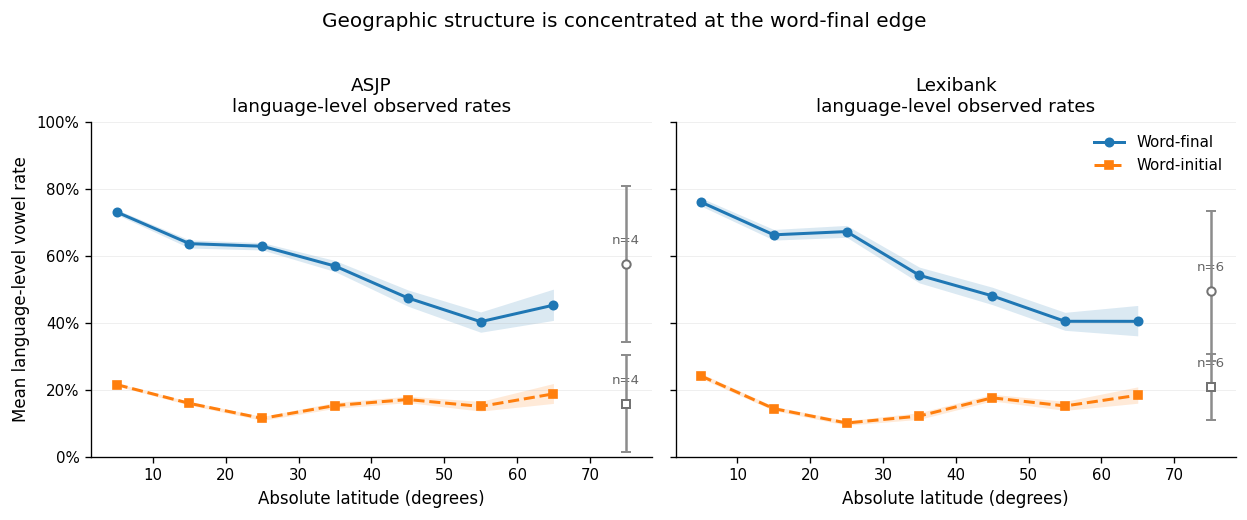

,database,position,latitude_lower,latitude_upper,latitude_midpoint,latitude_label,n_languages,mean_language_rate,ci_2.5,ci_97.5
0,ASJP,Word-initial,0.0,10.0,5.0,0–10,5173,0.215225,0.211064,0.219327
1,ASJP,Word-initial,10.0,20.0,15.0,10–20,2406,0.159180,0.153899,0.164448
2,ASJP,Word-initial,20.0,30.0,25.0,20–30,1734,0.114252,0.108345,0.120015
3,ASJP,Word-initial,30.0,40.0,35.0,30–40,824,0.152786,0.144284,0.161940
4,ASJP,Word-initial,40.0,50.0,45.0,40–50,446,0.170638,0.161466,0.180427
5,ASJP,Word-initial,50.0,60.0,55.0,50–60,198,0.150034,0.135985,0.164922
6,ASJP,Word-initial,60.0,70.0,65.0,60–70,101,0.187589,0.159070,0.218517
7,ASJP,Word-initial,70.0,80.0,75.0,70–80,4,0.158212,0.013393,0.303030
8,ASJP,Word-final,0.0,10.0,5.0,0–10,5173,0.730570,0.723099,0.737969
9,ASJP,Word-final,10.0,20.0,15.0,10–20,2406,0.636134,0.622988,0.647156


In [50]:
# ============================================================
# FIGURE 1 — REVISED
# Position-specific observed gradients across two databases
#
# - Language-level mean rates within 10-degree latitude bins
# - Bootstrap 95% intervals across languages
# - Bins with n < 20 are shown in grey and are not connected
# ============================================================

def binned_position_summary(
    encoded,
    database,
    bin_width=10,
    n_boot=1000,
    seed=20260712,
):
    frame = encoded["frame"].copy()

    frame["final_rate"] = (
        frame["n_v_final"] / frame["n_total"]
    )
    frame["initial_rate"] = (
        frame["n_v_initial"] / frame["n_total"]
    )

    upper = max(
        90,
        int(
            np.ceil(
                frame["abs_latitude"].max()
                / bin_width
            )
            * bin_width
        ),
    )

    edges = np.arange(
        0,
        upper + bin_width,
        bin_width,
    )

    frame["lat_bin"] = pd.cut(
        frame["abs_latitude"],
        bins=edges,
        right=False,
        include_lowest=True,
    )

    rng = np.random.default_rng(seed)
    rows = []

    for position, column in [
        ("Word-initial", "initial_rate"),
        ("Word-final", "final_rate"),
    ]:
        for interval, group in frame.groupby(
            "lat_bin",
            observed=True,
        ):
            values = (
                group[column]
                .dropna()
                .to_numpy()
            )

            if len(values) == 0:
                continue

            bootstrap_means = np.empty(n_boot)

            for b in range(n_boot):
                bootstrap_means[b] = rng.choice(
                    values,
                    size=len(values),
                    replace=True,
                ).mean()

            rows.append({
                "database": database,
                "position": position,
                "latitude_lower": float(
                    interval.left
                ),
                "latitude_upper": float(
                    interval.right
                ),
                "latitude_midpoint": float(
                    (
                        interval.left
                        + interval.right
                    )
                    / 2
                ),
                "latitude_label": (
                    f"{int(interval.left)}–"
                    f"{int(interval.right)}"
                ),
                "n_languages": int(len(values)),
                "mean_language_rate": float(
                    values.mean()
                ),
                "ci_2.5": float(
                    np.quantile(
                        bootstrap_means,
                        0.025,
                    )
                ),
                "ci_97.5": float(
                    np.quantile(
                        bootstrap_means,
                        0.975,
                    )
                ),
            })

    return pd.DataFrame(rows)


fig1_data = pd.concat([
    binned_position_summary(
        asjp_bb_enc,
        "ASJP",
        seed=SEED + 501,
    ),
    binned_position_summary(
        lex_bb_enc,
        "Lexibank",
        seed=SEED + 502,
    ),
], ignore_index=True)

fig1_data.to_csv(
    RESULTS
    / "figure1_position_specific_gradients.csv",
    index=False,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.2),
    sharex=True,
    sharey=True,
)

position_styles = {
    "Word-final": {
        "marker": "o",
        "linestyle": "-",
    },
    "Word-initial": {
        "marker": "s",
        "linestyle": "--",
    },
}

MIN_BIN_N_FOR_LINE = 20

for ax, database in zip(
    axes,
    ["ASJP", "Lexibank"],
):
    panel = fig1_data[
        fig1_data["database"] == database
    ]

    for position in [
        "Word-final",
        "Word-initial",
    ]:
        group = (
            panel[
                panel["position"] == position
            ]
            .sort_values("latitude_midpoint")
        )

        dense = group[
            group["n_languages"]
            >= MIN_BIN_N_FOR_LINE
        ]

        sparse = group[
            group["n_languages"]
            < MIN_BIN_N_FOR_LINE
        ]

        style = position_styles[position]

        # Main trajectory: populated bins only.
        line = ax.plot(
            dense["latitude_midpoint"],
            dense["mean_language_rate"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=1.8,
            markersize=5,
            label=position,
        )[0]

        ax.fill_between(
            dense[
                "latitude_midpoint"
            ].to_numpy(),
            dense["ci_2.5"].to_numpy(),
            dense["ci_97.5"].to_numpy(),
            alpha=0.16,
            color=line.get_color(),
            linewidth=0,
        )

        # Sparse bins: shown, but not joined.
        if not sparse.empty:
            yerr = np.vstack([
                sparse["mean_language_rate"]
                - sparse["ci_2.5"],
                sparse["ci_97.5"]
                - sparse["mean_language_rate"],
            ])

            ax.errorbar(
                sparse["latitude_midpoint"],
                sparse["mean_language_rate"],
                yerr=yerr,
                fmt=style["marker"],
                linestyle="none",
                color="0.55",
                markerfacecolor="white",
                markeredgecolor="0.45",
                markeredgewidth=1.2,
                capsize=3,
                markersize=5,
                zorder=5,
            )

            for _, row in sparse.iterrows():
                ax.annotate(
                    (
                        f'n='
                        f'{int(row["n_languages"])}'
                    ),
                    (
                        row["latitude_midpoint"],
                        row["mean_language_rate"],
                    ),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="0.4",
                )

    ax.set_title(
        f"{database}\n"
        f"language-level observed rates"
    )

    ax.set_xlabel(
        "Absolute latitude (degrees)"
    )

    ax.set_ylim(0, 1)

    ax.yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )

    ax.grid(
        axis="y",
        alpha=0.2,
        linewidth=0.6,
    )

axes[0].set_ylabel(
    "Mean language-level vowel rate"
)

axes[1].legend(
    frameon=False,
    loc="upper right",
)

fig.suptitle(
    "Geographic structure is concentrated "
    "at the word-final edge",
    y=1.02,
)

fig.tight_layout()

save_paper_figure(
    fig,
    "figure1_position_specific_gradients",
)

plt.show()

display(fig1_data)

Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figure2_core_posterior_effects.pdf
Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figure2_core_posterior_effects.png


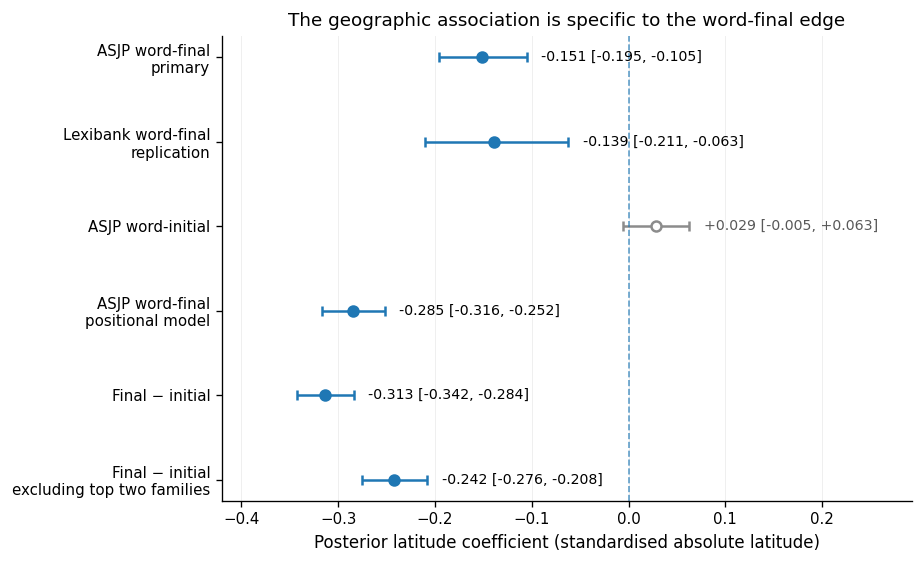

,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,display_label
0,"ASJP word-final, primary",beta_lat,-0.150609,-0.150881,-0.195420,-0.105011,1.0000,0.0000,ASJP word-final\nprimary
1,"Lexibank word-final, replication",beta_lat,-0.138250,-0.138695,-0.210541,-0.062540,0.9998,0.0002,Lexibank word-final\nreplication
2,ASJP word-initial,beta_lat_initial,0.028499,0.028522,-0.005331,0.062801,0.0482,0.9518,ASJP word-initial
3,"ASJP word-final, positional model",beta_lat_final,-0.284710,-0.284989,-0.316276,-0.252061,1.0000,0.0000,ASJP word-final\npositional model
4,ASJP final minus initial,beta_lat_final_delta,-0.313209,-0.313191,-0.342305,-0.284080,1.0000,0.0000,Final − initial
5,Final minus initial excluding top two families,beta_lat_final_delta,-0.242043,-0.242169,-0.275719,-0.207948,1.0000,0.0000,Final − initial\nexcluding top two families


In [51]:
# ============================================================
# FIGURE 2 — REVISED
# Core posterior effects
#
# Word-initial estimate is shown as an open grey marker.
# ============================================================

core_effect_rows = [
    {
        **posterior_effect_row(
            idata_asjp_bb,
            "beta_lat",
            "ASJP word-final, primary",
        ),
        "display_label": (
            "ASJP word-final\nprimary"
        ),
    },
    {
        **posterior_effect_row(
            idata_lex_bb,
            "beta_lat",
            "Lexibank word-final, replication",
        ),
        "display_label": (
            "Lexibank word-final\nreplication"
        ),
    },
    {
        **posterior_effect_row(
            idata_position_bb,
            "beta_lat_initial",
            "ASJP word-initial",
        ),
        "display_label": (
            "ASJP word-initial"
        ),
    },
    {
        **posterior_effect_row(
            idata_position_bb,
            "beta_lat_final",
            "ASJP word-final, positional model",
        ),
        "display_label": (
            "ASJP word-final\n"
            "positional model"
        ),
    },
    {
        **posterior_effect_row(
            idata_position_bb,
            "beta_lat_final_delta",
            "ASJP final minus initial",
        ),
        "display_label": (
            "Final − initial"
        ),
    },
]

if "idata_position_excl_top2" in globals():
    core_effect_rows.append({
        **posterior_effect_row(
            idata_position_excl_top2,
            "beta_lat_final_delta",
            (
                "Final minus initial "
                "excluding top two families"
            ),
        ),
        "display_label": (
            "Final − initial\n"
            "excluding top two families"
        ),
    })

fig2_data = pd.DataFrame(
    core_effect_rows
)

fig2_data.to_csv(
    RESULTS
    / "figure2_core_posterior_effects.csv",
    index=False,
)

fig2_plot = (
    fig2_data
    .iloc[::-1]
    .reset_index(drop=True)
)

y = np.arange(len(fig2_plot))

fig, ax = plt.subplots(
    figsize=(7.8, 4.8),
)

main_color = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"][0]

null_color = "0.55"

for yi, row in fig2_plot.iterrows():
    is_initial_null = (
        row["display_label"]
        == "ASJP word-initial"
    )

    color = (
        null_color
        if is_initial_null
        else main_color
    )

    left_error = (
        row["median"]
        - row["ci_2.5"]
    )

    right_error = (
        row["ci_97.5"]
        - row["median"]
    )

    ax.errorbar(
        row["median"],
        yi,
        xerr=np.array([
            [left_error],
            [right_error],
        ]),
        fmt="o",
        markersize=6,
        capsize=3,
        linewidth=1.5,
        color=color,
        markerfacecolor=(
            "white"
            if is_initial_null
            else color
        ),
        markeredgecolor=color,
        markeredgewidth=1.5,
    )

    ax.text(
        row["ci_97.5"] + 0.015,
        yi,
        (
            f'{row["median"]:+.3f} '
            f'[{row["ci_2.5"]:+.3f}, '
            f'{row["ci_97.5"]:+.3f}]'
        ),
        va="center",
        fontsize=8.5,
        color=(
            "0.35"
            if is_initial_null
            else "black"
        ),
    )

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_yticks(y)

ax.set_yticklabels(
    fig2_plot["display_label"]
)

ax.set_xlabel(
    "Posterior latitude coefficient "
    "(standardised absolute latitude)"
)

ax.set_title(
    "The geographic association is specific "
    "to the word-final edge"
)

ax.grid(
    axis="x",
    alpha=0.2,
    linewidth=0.6,
)

left_limit = min(
    -0.42,
    float(
        fig2_plot["ci_2.5"].min()
    )
    - 0.04,
)

right_limit = max(
    0.18,
    float(
        fig2_plot["ci_97.5"].max()
    )
    + 0.23,
)

ax.set_xlim(
    left_limit,
    right_limit,
)

fig.tight_layout()

save_paper_figure(
    fig,
    "figure2_core_posterior_effects",
)

plt.show()

display(fig2_data)

Median-based macroarea attenuation: 47.9662%
Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figure3_areal_attenuation_and_heterogeneity.pdf
Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figure3_areal_attenuation_and_heterogeneity.png


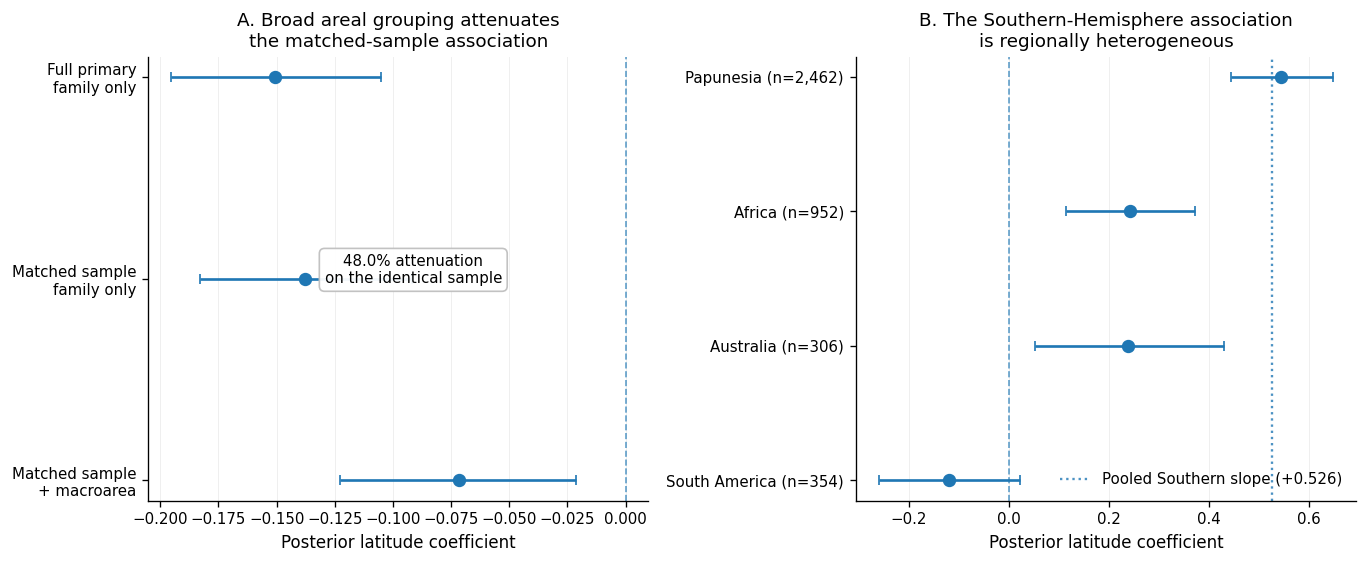

,model,parameter,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0,display_label,n_languages,n_families,macroarea_adjusted,odds_ratio_per_1sd,attenuation_relative_to_no_macro
0,Full primary,beta_lat,-0.150609,-0.150881,-0.195420,-0.105011,1.0000,0.0000,Full primary\nfamily only,10886,646,NaN,NaN,NaN
1,ASJP BB matched sample without macroarea,beta_lat,-0.137217,-0.137723,-0.182816,-0.091625,1.0000,0.0000,Matched sample\nfamily only,10626,386,False,0.871340,NaN
2,ASJP BB matched sample with macroarea,beta_lat,-0.071817,-0.071663,-0.122949,-0.021302,0.9969,0.0031,Matched sample\n+ macroarea,10626,386,True,0.930845,0.479662


,macroarea,n_languages,n_families,mean,median,ci_2.5,ci_97.5,p_lt_0,p_gt_0
0,South America,354,68,-0.119449,-0.119355,-0.261094,0.021433,0.9509,0.0491
1,Australia,306,29,0.239317,0.238812,0.051667,0.429490,0.0060,0.9940
2,Africa,952,12,0.242038,0.241379,0.114397,0.372660,0.0000,1.0000
3,Papunesia,2462,124,0.544906,0.544666,0.444162,0.648721,0.0000,1.0000


In [57]:
# ============================================================
# FIGURE 3 — REVISED
#
# A: matched-sample macroarea attenuation
# B: Southern-Hemisphere macroarea heterogeneity
#
# IMPORTANT:
# Attenuation is calculated from the posterior medians used for
# the plotted points:
#
#   1 - abs(beta_with_macroarea) / abs(beta_without_macroarea)
#
# This avoids mixing posterior means and medians.
# ============================================================

full_primary_row = posterior_effect_row(
    idata_asjp_bb,
    "beta_lat",
    "Full primary",
)

matched_no_macro_row = (
    matched_sample_comparison[
        ~matched_sample_comparison[
            "macroarea_adjusted"
        ].astype(bool)
    ]
    .iloc[0]
    .to_dict()
)

matched_with_macro_row = (
    matched_sample_comparison[
        matched_sample_comparison[
            "macroarea_adjusted"
        ].astype(bool)
    ]
    .iloc[0]
    .to_dict()
)

# ------------------------------------------------------------
# Calculate attenuation from the same posterior medians that
# are used for the plotted coefficient points.
# ------------------------------------------------------------

median_no_macro = float(
    matched_no_macro_row["median"]
)

median_with_macro = float(
    matched_with_macro_row["median"]
)

attenuation_from_medians = (
    1.0
    - abs(median_with_macro)
    / abs(median_no_macro)
)

attenuation_percent = (
    100.0 * attenuation_from_medians
)

# Cross-check against the stored CSV value when available.
stored_attenuation = matched_with_macro_row.get(
    "attenuation_relative_to_no_macro",
    np.nan,
)

if pd.notna(stored_attenuation):
    if not np.isclose(
        float(stored_attenuation),
        attenuation_from_medians,
        rtol=0.0,
        atol=1e-10,
    ):
        raise ValueError(
            "Stored attenuation does not match the "
            "attenuation calculated from posterior medians: "
            f"stored={stored_attenuation}, "
            f"calculated={attenuation_from_medians}"
        )

print(
    "Median-based macroarea attenuation:",
    f"{attenuation_percent:.4f}%"
)

attenuation_data = pd.DataFrame([
    {
        **full_primary_row,
        "display_label": (
            "Full primary\n"
            "family only"
        ),
        "n_languages": 10886,
        "n_families": 646,
    },
    {
        **matched_no_macro_row,
        "display_label": (
            "Matched sample\n"
            "family only"
        ),
    },
    {
        **matched_with_macro_row,
        "display_label": (
            "Matched sample\n"
            "+ macroarea"
        ),
        "attenuation_relative_to_no_macro": (
            attenuation_from_medians
        ),
    },
])

south_plot_data = (
    south_macro_bb_effects[
        south_macro_bb_effects[
            "n_languages"
        ]
        >= 20
    ]
    .copy()
    .sort_values("median")
    .reset_index(drop=True)
)

pooled_south = posterior_effect_row(
    idata_hemi_bb,
    "beta_lat_south",
    "Pooled Southern Hemisphere",
)

attenuation_data.to_csv(
    RESULTS
    / "figure3_macroarea_attenuation.csv",
    index=False,
)

south_plot_data.to_csv(
    RESULTS
    / "figure3_southern_macroarea_slopes.csv",
    index=False,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.8),
)

# ------------------------------------------------------------
# Panel A
# ------------------------------------------------------------

ax = axes[0]

plot_a = (
    attenuation_data
    .iloc[::-1]
    .reset_index(drop=True)
)

y_a = np.arange(
    len(plot_a)
)

xerr_a = np.vstack([
    plot_a["median"]
    - plot_a["ci_2.5"],
    plot_a["ci_97.5"]
    - plot_a["median"],
])

ax.errorbar(
    plot_a["median"],
    y_a,
    xerr=xerr_a,
    fmt="o",
    markersize=7,
    capsize=3,
    linewidth=1.6,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_yticks(
    y_a
)

ax.set_yticklabels(
    plot_a["display_label"]
)

ax.set_xlabel(
    "Posterior latitude coefficient"
)

ax.set_title(
    "A. Broad areal grouping attenuates\n"
    "the matched-sample association"
)

ax.grid(
    axis="x",
    alpha=0.2,
    linewidth=0.6,
)

ax.text(
    0.53,
    0.52,
    (
        f"{attenuation_percent:.1f}% attenuation\n"
        "on the identical sample"
    ),
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=9,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "0.75",
        "alpha": 0.95,
    },
)

# ------------------------------------------------------------
# Panel B
# ------------------------------------------------------------

ax = axes[1]

y_b = np.arange(
    len(south_plot_data)
)

xerr_b = np.vstack([
    south_plot_data["median"]
    - south_plot_data["ci_2.5"],
    south_plot_data["ci_97.5"]
    - south_plot_data["median"],
])

ax.errorbar(
    south_plot_data["median"],
    y_b,
    xerr=xerr_b,
    fmt="o",
    markersize=7,
    capsize=3,
    linewidth=1.6,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.axvline(
    pooled_south["median"],
    linestyle=":",
    linewidth=1.4,
    alpha=0.8,
    label=(
        "Pooled Southern slope "
        f'({pooled_south["median"]:+.3f})'
    ),
)

labels_b = [
    (
        f'{row["macroarea"]} '
        f'(n={int(row["n_languages"]):,})'
    )
    for _, row
    in south_plot_data.iterrows()
]

ax.set_yticks(
    y_b
)

ax.set_yticklabels(
    labels_b
)

ax.set_xlabel(
    "Posterior latitude coefficient"
)

ax.set_title(
    "B. The Southern-Hemisphere association\n"
    "is regionally heterogeneous"
)

ax.legend(
    frameon=False,
    loc="lower right",
)

ax.grid(
    axis="x",
    alpha=0.2,
    linewidth=0.6,
)

fig.tight_layout()

save_paper_figure(
    fig,
    "figure3_areal_attenuation_and_heterogeneity",
)

plt.show()

display(
    attenuation_data,
    south_plot_data,
)

Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figure4_boundary_mass_ppc.pdf
Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figure4_boundary_mass_ppc.png


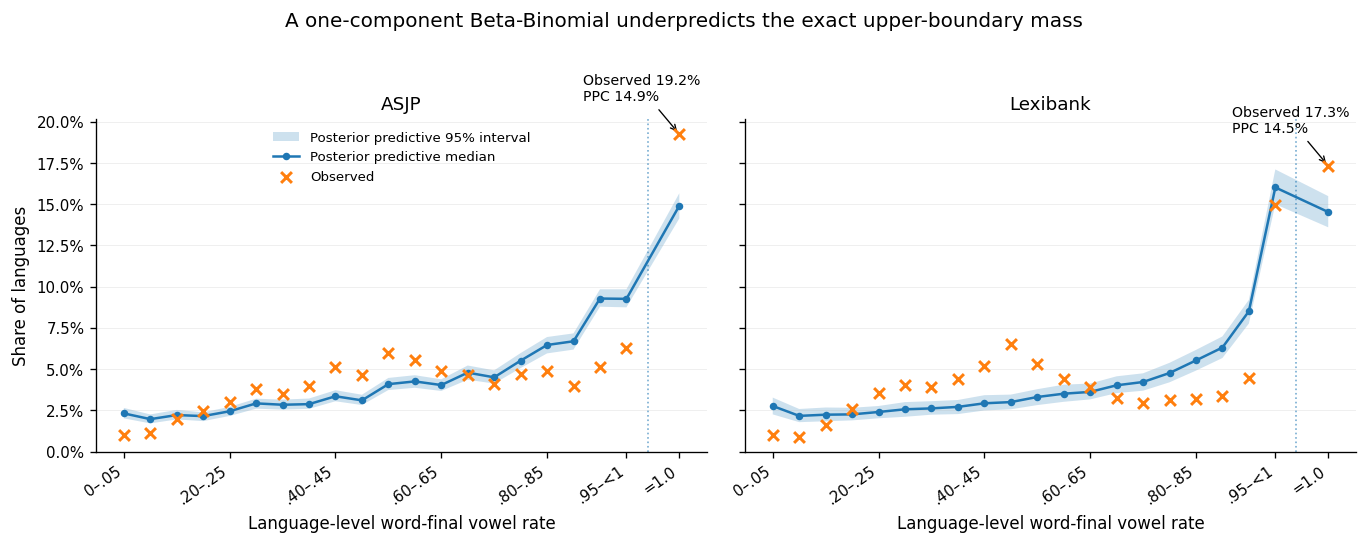

,database,bin,x_position,observed_share,ppc_median,ppc_2.5,ppc_97.5
0,ASJP,0.00–<0.05,0,0.009921,0.023149,0.020118,0.026456
1,ASJP,0.05–<0.10,1,0.011391,0.019658,0.017084,0.022506
2,ASJP,0.10–<0.15,2,0.019658,0.022139,0.019475,0.025262
3,ASJP,0.15–<0.20,3,0.024894,0.021495,0.018464,0.023794
4,ASJP,0.20–<0.25,4,0.029855,0.024435,0.021585,0.027101
5,ASJP,0.25–<0.30,5,0.037663,0.029212,0.025997,0.032060
6,ASJP,0.30–<0.35,6,0.035091,0.028385,0.025446,0.031508
7,ASJP,0.35–<0.40,7,0.039868,0.028753,0.025903,0.032151
8,ASJP,0.40–<0.45,8,0.051534,0.033529,0.030498,0.037206
9,ASJP,0.45–<0.50,9,0.046390,0.031049,0.028201,0.034450


In [53]:
# ============================================================
# FIGURE 4 — REVISED
# Posterior predictive distribution of language-level rates
#
# Exact-one boundary is separated from [0.95, 1.0).
# ============================================================

def subset_samples_for_figure(
    samples,
    max_draws=600,
):
    n_draws = next(
        iter(samples.values())
    ).shape[0]

    if n_draws <= max_draws:
        return samples

    keep = np.linspace(
        0,
        n_draws - 1,
        max_draws,
        dtype=int,
    )

    return {
        key: value[keep]
        for key, value in samples.items()
    }


def boundary_histogram_ppc(
    model_fn,
    mcmc,
    encoded,
    database,
    seed,
    max_draws=600,
):
    samples = subset_samples_for_figure(
        mcmc.get_samples(),
        max_draws=max_draws,
    )

    predictive = Predictive(
        model_fn,
        posterior_samples=samples,
        return_sites=["y"],
    )

    pred = predictive(
        jax.random.PRNGKey(seed),
        y=None,
        n=jnp.asarray(
            encoded["n"],
            dtype=jnp.int64,
        ),
        lat_z=jnp.asarray(
            encoded["lat_z"]
        ),
        family_idx=jnp.asarray(
            encoded["family_idx"],
            dtype=jnp.int32,
        ),
        n_family=encoded["n_family"],
    )

    yrep = np.asarray(
        pred["y"]
    )

    observed_y = np.asarray(
        encoded["y"]
    )

    n = np.asarray(
        encoded["n"]
    )

    edges = np.linspace(
        0,
        1,
        21,
    )

    n_bins = len(edges) - 1

    replicated = np.zeros(
        (
            yrep.shape[0],
            n_bins + 1,
        )
    )

    for draw in range(
        yrep.shape[0]
    ):
        exact_one = (
            yrep[draw] == n
        )

        rates_below_one = (
            yrep[draw, ~exact_one]
            / n[~exact_one]
        )

        counts, _ = np.histogram(
            rates_below_one,
            bins=edges,
        )

        replicated[
            draw,
            :n_bins,
        ] = (
            counts / len(n)
        )

        replicated[
            draw,
            n_bins,
        ] = exact_one.mean()

    observed_exact_one = (
        observed_y == n
    )

    observed_rates_below_one = (
        observed_y[
            ~observed_exact_one
        ]
        / n[
            ~observed_exact_one
        ]
    )

    observed_counts, _ = np.histogram(
        observed_rates_below_one,
        bins=edges,
    )

    observed = np.concatenate([
        observed_counts / len(n),
        [observed_exact_one.mean()],
    ])

    x_positions = np.concatenate([
        np.arange(n_bins),
        [n_bins + 1],
    ])

    labels = [
        (
            f"{edges[i]:.2f}"
            f"–<{edges[i + 1]:.2f}"
        )
        for i in range(n_bins)
    ] + ["=1.00"]

    return pd.DataFrame({
        "database": database,
        "bin": labels,
        "x_position": x_positions,
        "observed_share": observed,
        "ppc_median": np.median(
            replicated,
            axis=0,
        ),
        "ppc_2.5": np.quantile(
            replicated,
            0.025,
            axis=0,
        ),
        "ppc_97.5": np.quantile(
            replicated,
            0.975,
            axis=0,
        ),
    })


fig4_data = pd.concat([
    boundary_histogram_ppc(
        primary_beta_binomial_model,
        mcmc_asjp_bb,
        asjp_bb_enc,
        "ASJP",
        SEED + 601,
    ),
    boundary_histogram_ppc(
        primary_beta_binomial_model,
        mcmc_lex_bb,
        lex_bb_enc,
        "Lexibank",
        SEED + 602,
    ),
], ignore_index=True)

fig4_data.to_csv(
    RESULTS
    / "figure4_boundary_mass_ppc.csv",
    index=False,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.4),
    sharey=True,
)

for ax, database in zip(
    axes,
    ["ASJP", "Lexibank"],
):
    panel = (
        fig4_data[
            fig4_data[
                "database"
            ]
            == database
        ]
        .sort_values("x_position")
    )

    x = panel[
        "x_position"
    ].to_numpy()

    ax.fill_between(
        x,
        panel["ppc_2.5"].to_numpy(),
        panel["ppc_97.5"].to_numpy(),
        alpha=0.22,
        label=(
            "Posterior predictive "
            "95% interval"
        ),
    )

    ax.plot(
        x,
        panel["ppc_median"],
        marker="o",
        linewidth=1.5,
        markersize=3.5,
        label=(
            "Posterior predictive "
            "median"
        ),
    )

    ax.scatter(
        x,
        panel["observed_share"],
        marker="x",
        s=42,
        linewidth=1.8,
        label="Observed",
        zorder=4,
    )

    # Visual separation before exact-one.
    ax.axvline(
        19.8,
        linestyle=":",
        linewidth=1,
        alpha=0.6,
    )

    tick_positions = [
        0,
        4,
        8,
        12,
        16,
        19,
        21,
    ]

    tick_labels = [
        "0–.05",
        ".20–.25",
        ".40–.45",
        ".60–.65",
        ".80–.85",
        ".95–<1",
        "=1.0",
    ]

    ax.set_xticks(
        tick_positions
    )

    ax.set_xticklabels(
        tick_labels,
        rotation=35,
        ha="right",
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )

    exact_row = panel[
        panel["bin"] == "=1.00"
    ].iloc[0]

    ax.annotate(
        (
            f'Observed '
            f'{exact_row["observed_share"]:.1%}\n'
            f'PPC '
            f'{exact_row["ppc_median"]:.1%}'
        ),
        xy=(
            exact_row["x_position"],
            exact_row["observed_share"],
        ),
        xytext=(-58, 20),
        textcoords="offset points",
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 0.8,
        },
        fontsize=8.5,
    )

    ax.set_title(database)

    ax.set_xlabel(
        "Language-level word-final "
        "vowel rate"
    )

    ax.grid(
        axis="y",
        alpha=0.2,
        linewidth=0.6,
    )

axes[0].set_ylabel(
    "Share of languages"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
    loc="upper center",
)

fig.suptitle(
    "A one-component Beta-Binomial "
    "underpredicts the exact "
    "upper-boundary mass",
    y=1.02,
)

fig.tight_layout()

save_paper_figure(
    fig,
    "figure4_boundary_mass_ppc",
)

plt.show()

display(fig4_data)

Audit notice: the ASJP label 'Bookkeeping' was saved to audit_asjp_bookkeeping_family.csv and excluded from the interpretive family figure.


,Language_ID,Family,Latitude,Longitude,n_total,n_concepts
0,BAYNUNK_GUJAXER,Bookkeeping,12.51,-16.00,55,38
1,BAYNUNK_GUJAXER_2,Bookkeeping,12.51,-16.00,51,46
2,BAYNUNK_GUJAXER_3,Bookkeeping,12.51,-16.00,94,54
3,BAYNUNK_GUJAXER_4,Bookkeeping,12.51,-16.00,63,57
4,BAYNUNK_GUJAXER_5,Bookkeeping,12.51,-16.00,72,65
5,BAYNUNK_GUJAXER_6,Bookkeeping,12.51,-16.00,81,67
6,BUMANG,Bookkeeping,23.02,103.34,40,39
7,GENGLE,Bookkeeping,9.33,12.50,21,21
8,IHIEE,Bookkeeping,7.00,6.10,56,52
9,KATUKINA,Bookkeeping,-3.60,-66.55,29,28


Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figureS1_family_boundary_ppc.pdf
Saved: /content/beyond_arbitrariness_paper1/figures/paper1/figureS1_family_boundary_ppc.png


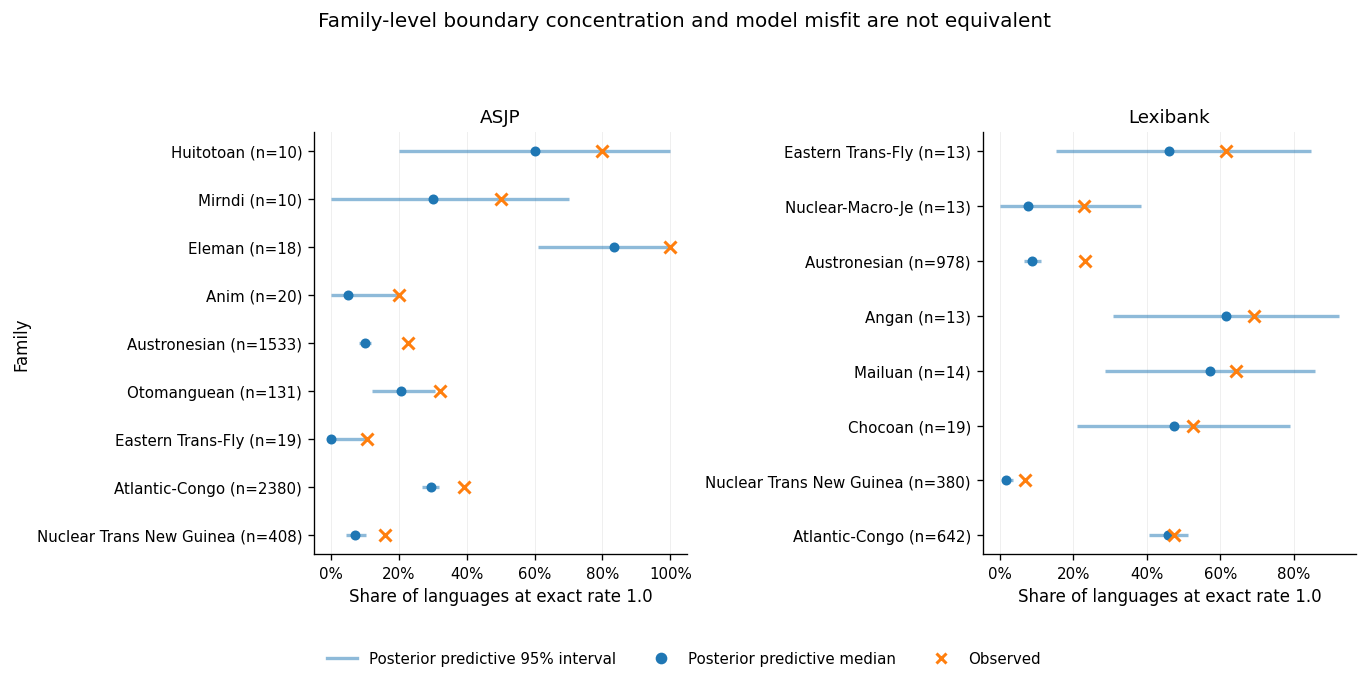

,Family,n_languages,observed_share_exact_one,ppc_median,ppc_2.5,ppc_97.5,residual_observed_minus_ppc_median,bayesian_p_ge_observed,database
0,Nuclear Trans New Guinea,408,0.159314,0.071078,0.044118,0.103002,0.088235,0.000000,ASJP
1,Atlantic-Congo,2380,0.391176,0.294958,0.269737,0.319758,0.096218,0.000000,ASJP
2,Eastern Trans-Fly,19,0.105263,0.000000,0.000000,0.105263,0.105263,0.026667,ASJP
3,Otomanguean,131,0.320611,0.206107,0.122137,0.305344,0.114504,0.015000,ASJP
4,Austronesian,1533,0.228311,0.099804,0.082175,0.118738,0.128506,0.000000,ASJP
5,Anim,20,0.200000,0.050000,0.000000,0.200000,0.150000,0.060833,ASJP
6,Eleman,18,1.000000,0.833333,0.611111,1.000000,0.166667,0.096667,ASJP
7,Mirndi,10,0.500000,0.300000,0.000000,0.702500,0.200000,0.289167,ASJP
8,Huitotoan,10,0.800000,0.600000,0.200000,1.000000,0.200000,0.293333,ASJP
9,Atlantic-Congo,642,0.473520,0.457944,0.406542,0.512461,0.015576,0.303333,Lexibank


In [54]:
# ============================================================
# FIGURE S1 — REVISED
# Family-level exact-one boundary PPC
#
# - Consistent role-based colours
# - Legend below panels
# - "Bookkeeping" audited and excluded from interpretive figure
# ============================================================

from matplotlib.lines import Line2D


def select_family_ppc_rows(
    frame,
    top_n=7,
    min_languages=10,
):
    eligible = frame[
        frame["n_languages"]
        >= min_languages
    ].copy()

    selected_names = set(
        eligible.nlargest(
            top_n,
            (
                "residual_observed_"
                "minus_ppc_median"
            ),
        )["Family"]
    )

    named_families = {
        "Atlantic-Congo",
        "Austronesian",
        "Nuclear Trans New Guinea",
    }

    selected_names.update(
        name
        for name in named_families
        if name
        in set(eligible["Family"])
    )

    return (
        eligible[
            eligible["Family"].isin(
                selected_names
            )
        ]
        .sort_values(
            (
                "residual_observed_"
                "minus_ppc_median"
            )
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# Audit the suspicious metadata label before plotting.
# ------------------------------------------------------------

if "Bookkeeping" in set(
    asjp_bb_enc["frame"]["Family"]
):
    bookkeeping_languages = (
        asjp_bb_enc["frame"][
            asjp_bb_enc["frame"]["Family"]
            == "Bookkeeping"
        ][
            [
                "Language_ID",
                "Family",
                "Latitude",
                "Longitude",
                "n_total",
                "n_concepts",
            ]
        ]
        .sort_values("Language_ID")
        .reset_index(drop=True)
    )

    bookkeeping_languages.to_csv(
        RESULTS
        / "audit_asjp_bookkeeping_family.csv",
        index=False,
    )

    print(
        "Audit notice: the ASJP label "
        "'Bookkeeping' was saved to "
        "audit_asjp_bookkeeping_family.csv "
        "and excluded from the interpretive "
        "family figure."
    )

    display(bookkeeping_languages)


# Remove Bookkeeping from figure selection only.
asjp_family_ppc_for_figure = (
    asjp_family_ppc[
        asjp_family_ppc["Family"]
        != "Bookkeeping"
    ]
    .copy()
)

figS1_asjp = select_family_ppc_rows(
    asjp_family_ppc_for_figure
)

figS1_lex = select_family_ppc_rows(
    lex_family_ppc
)

figS1_asjp["database"] = "ASJP"
figS1_lex["database"] = "Lexibank"

figS1_data = pd.concat([
    figS1_asjp,
    figS1_lex,
], ignore_index=True)

figS1_data.to_csv(
    RESULTS
    / "figureS1_family_boundary_ppc.csv",
    index=False,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 5.8),
)

ppc_color = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"][0]

observed_color = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"][1]

for ax, database, panel in [
    (
        axes[0],
        "ASJP",
        figS1_asjp,
    ),
    (
        axes[1],
        "Lexibank",
        figS1_lex,
    ),
]:
    y = np.arange(
        len(panel)
    )

    for yi, (_, row) in enumerate(
        panel.iterrows()
    ):
        ax.hlines(
            yi,
            row["ppc_2.5"],
            row["ppc_97.5"],
            color=ppc_color,
            linewidth=2,
            alpha=0.5,
        )

        ax.plot(
            row["ppc_median"],
            yi,
            marker="o",
            linestyle="none",
            color=ppc_color,
            markersize=5,
        )

        ax.plot(
            row[
                "observed_share_exact_one"
            ],
            yi,
            marker="x",
            linestyle="none",
            color=observed_color,
            markersize=7,
            markeredgewidth=1.8,
        )

    labels = [
        (
            f'{row["Family"]} '
            f'(n={int(row["n_languages"])})'
        )
        for _, row
        in panel.iterrows()
    ]

    ax.set_yticks(y)

    ax.set_yticklabels(labels)

    ax.set_xlabel(
        "Share of languages "
        "at exact rate 1.0"
    )

    ax.xaxis.set_major_formatter(
        PercentFormatter(1.0)
    )

    ax.set_title(database)

    ax.grid(
        axis="x",
        alpha=0.2,
        linewidth=0.6,
    )

axes[0].set_ylabel("Family")

legend_handles = [
    Line2D(
        [0],
        [0],
        color=ppc_color,
        linewidth=2,
        alpha=0.5,
        label=(
            "Posterior predictive "
            "95% interval"
        ),
    ),
    Line2D(
        [0],
        [0],
        color=ppc_color,
        marker="o",
        linestyle="none",
        label=(
            "Posterior predictive "
            "median"
        ),
    ),
    Line2D(
        [0],
        [0],
        color=observed_color,
        marker="x",
        linestyle="none",
        markeredgewidth=1.8,
        label="Observed",
    ),
]

fig.suptitle(
    "Family-level boundary concentration "
    "and model misfit are not equivalent",
    y=0.97,
)

fig.legend(
    handles=legend_handles,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
)

fig.tight_layout(
    rect=[
        0,
        0.09,
        1,
        0.91,
    ]
)

save_paper_figure(
    fig,
    "figureS1_family_boundary_ppc",
)

plt.show()

display(figS1_data)

In [56]:
import shutil
from google.colab import files



# 1. フォルダを zip 形式で圧縮します
shutil.make_archive('/content/beyond_arbitrariness_paper1/results', 'zip', '/content/beyond_arbitrariness_paper1/results')

# 2. 圧縮したファイルをブラウザ経由でダウンロードします
files.download('/content/beyond_arbitrariness_paper1/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>